# 📘 Cas d'usage — Certification "Concevoir et implémenter une solution d'IA"


Nom Prénom : EL OUARDI Mina <br>
Formation : Concevoir une solution IA <br> 
Date : 26/06/2026


## Introduction


**Nom du projet : TravelMind** - solution IA destinée à aider une agence de voyages haut de gamme à personnaliser les séjours et à anticiper la satisfaction client.

Ce notebook final centralise les étapes stabilisées du projet TravelMind :

1. **Partie 1 - Cadrage, besoins métier, cas d'usage et dataset** : problème métier, KPI, contraintes, pertinence de l'IA, datasheet et alternatives dataset.
2. **Partie 2 - Risques éthiques, sociétaux et registre RGPD** : risques, biais, AI Act, RGPD et acteurs à informer.
3. **Partie 3 - Préparation des données, intégrité et pertinence** : chargement, contrôles métier, nettoyage, valeurs manquantes, outliers, valeurs négatives et versioning des données.
4. **Partie 4 - Modélisation, choix, entraînement et validation** : feature engineering, segmentation, modèles pré-voyage et post-voyage, validation croisée, diagnostics et matrices de confusion.
5. **Partie 5 - Choix du modèle IA** : justification du modèle retenu, contraintes opérationnelles, éco-conception et alternatives techniques.
6. **Partie 6 - Entraînement supervisé du modèle IA** : hyperparamètres, pipeline, optimisation, résultats et limites.
7. **Partie 7 - Implémentation et intégration technique** : artefacts, API, interface web, Docker, monitoring, tests et CI/CD.
8. **Partie 8 - Évaluation de l'architecture cible** : architecture retenue, scénarios étudiés, contraintes et points de validation avant généralisation.
9. **Partie 9 - Mesure de performance et impacts de la solution IA** : Model Card, CodeCarbon, performances par sous-groupes, impacts et seuils.
10. **Partie 10 - Amélioration continue de la solution IA** : suivi, alertes, réentraînement contrôlé et amélioration du service.
11. **Partie 11 - Synthèse finale** : conclusion opérationnelle sur le modèle industrialisé et les limites.
12. **Partie 12 - Bonnes pratiques adoptées** : synthèse des pratiques projet appliquées.
13. **Partie 13 - Synthèse des ambitions métier** : niveau de couverture des ambitions initiales de l'agence.


## 0. Journal de bord du projet TravelMind

Ce journal de bord synthétise les principales décisions prises pendant le projet. Il permet de suivre l'avancement, la raison de chaque action, les preuves associées et la décision retenue pour le livrable final.

| Étape | Action réalisée | Objectif | Résultat obtenu | Preuve / suite |
| --- | --- | --- | --- | --- |
| Initialisation | Création de l'environnement Python `.venv`, du dépôt Git/GitHub et de la base Docker | Rendre le projet reproductible, versionné et portable | Structure projet en place avec dépendances, dépôt Git et conteneurisation | `requirements.txt`, `.gitignore`, `Dockerfile`, `docker-compose.yml` |
| Cadrage métier | Définition du besoin TravelMind, des cas d'usage pré-voyage et post-voyage, des KPI et des contraintes | Clarifier le problème métier et vérifier que l'IA apporte une valeur | Deux objectifs distingués : prédiction avant départ et analyse qualité après séjour | KPI métier, séparation pré/post-voyage
| Dataset | Identification du fichier `Examen_travel_planning_dataset.csv` et vérification des droits d'usage | Vérifier la pertinence, la disponibilité et la cohérence du jeu de données | Dataset synthétique, anonymisé et utilisable dans le cadre de ce projet | `data/Examen_travel_planning_dataset.csv`|
| Datasheet et gouvernance | Documentation de la motivation, composition, usages, limites, distribution et maintenance du dataset | Répondre aux exigences de documentation du jeu de données | Datasheet structurée ajoutée au notebook |
| Éthique, RGPD et AI Act | Analyse des risques, registre RGPD, rôles AI Act, usage clients finaux et obligation d'alphabétisation IA | Encadrer l'usage responsable de TravelMind | Risques, mesures, supervision humaine |
| Analyse métier du dataset brut | Contrôle de l'unicité, satisfaction, budget, prix vol, activités, imprévus, réorganisation et fuite de données | Identifier les cas incohérents ou explicables avant préparation | Incohérences critiques distinguées des observations métier explicables| tableaux de contrôles |
| Préparation des données | Nettoyage, valeurs manquantes, outliers, valeurs négatives, doublons et formats | Renforcer l'intégrité des données avant modélisation | Traitements documentés et appliqués | pipelines sklearn |
| Pipeline | Incluson de l'imputation, encodage, standardisation et traitement IQR dans les pipelines après split train/test | Éviter que le test influence les paramètres appris sur le train | Pipeline plus rigoureux et conforme aux bonnes pratiques ML | `ColumnTransformer`, `Pipeline`, `IQRMedianOutlierReplacer` |
| Feature engineering | Création de variables dérivées pré-voyage et post-voyage explicatives | Ajouter du signal métier tout en respectant le moment d'utilisation | Features pré-voyage retenues pour l'API, variables post-voyage exclues du modèle pré-voyage | Sections feature engineering et liste des features |
| Versioning des données | Mise en place des versions v1.0, v1.1, v1.2, v2.0 et v2.1 | Tracer les transformations du dataset et garantir la reproductibilité | Versions documentées et générées dans `data/versions/` | `scripts/version_data.py`, `docs/data_versioning.md` |
| Modélisation pré-voyage | Comparaison de modèles 3 classes avec baseline, validation croisée et diagnostics | Tester la capacité des variables avant départ à prédire la satisfaction | Performance modeste, cohérente avec le faible signal pré-voyage | Retenu comme modèle industrialise car il correspond au cas d'usage avant départ |
| Expériences pré-voyage | Tests Optuna, RandomizedSearch, SMOTE, SMOTENC, augmentation 20 000 et 50 000 lignes | Chercher un gain de performance sans changer l'objectif métier | Gains limités ou instables, parfois surapprentissage | pour industrialisation | Notebook de tests hyperparamètres, synthèse des essais |
| Modélisation post-voyage | Ajout des variables opérationnelles `imprevus`, `respect_budget`, `reorganisation_necessaire` pour analyse qualité | Comparer le signal disponible après séjour avec le signal pré-voyage | Scores meilleurs, confirmant que les variables post-voyage expliquent davantage la satisfaction | Conservé pour analyse qualité, non retenu pour l'API pré-voyage | Sections post-voyage |
| NLP exploratoire | Analyse de `retour_client` avec tokenisation, lemmatisation, POS, NER et sentiment | Évaluer l'apport du texte libre | NLP utile pour l'analyse qualitative, mais non retenu dans le modèle principal en raison du risque de fuite du ressenti client | Conservé comme exploration | Section NLP exploratoire |
| Évaluation et transparence | Ajout matrice de confusion, validation croisée, overfitting, underfitting, Model Card, métriques éthiques et CodeCarbon | Documenter la performance, les limites et les impacts | Lecture métier des scores, biais et empreinte carbone documentée | Model Card, CodeCarbon |
| Industrialisation | Création de `train.py`, `app/`, TravelMind API, monitoring, logs et TravelMind Dashboard | Servir le modèle pré-voyage hors notebook | API locale fonctionnelle avec `/health`, `/predict`, `/monitoring/*` et interface web | `train.py`, `app/main.py`, `app_web.py` |
| Monitoring et réentraînement | Journalisation JSONL, drift, alertes, dashboard KPI et stratégie de réentraînement | Suivre l'exploitation et déclencher des actions si le contexte change | Monitoring initial et seuils d'alerte disponibles | `app/monitoring.py`, `docs/strategie_reentrainement.md` |
| CI/CD et qualité | Ajout des tests, GitHub Actions | Automatiser les contrôles avant livraison | Tests API/ML/monitoring et contrôle qualité modèle intégrés | `.github/workflows/ci-cd.yml`, `tests/`, `configs/model_quality_gate.json` |
| Architecture cible | Architecture retenue : API locale + dashboard + Docker optionnel + CI/CD | Choisir une architecture proportionnée au prototype | Architecture retenue : API locale + dashboard + Docker optionnel + CI/CD |


## Partie 1 - Cadrage, besoins métier, cas d'usage et dataset

Cette partie fixe le cadre du projet TravelMind avant toute préparation de données ou modélisation. Elle précise le problème métier, les objectifs IA, les KPI, les contraintes et le rôle du dataset.

### 1.1 Définition du problème métier

L'agence de voyages haut de gamme souhaite mieux personnaliser ses propositions de séjour et anticiper le niveau de satisfaction client. Le problème concret est d'identifier, avant le départ, les séjours présentant un risque d'insatisfaction afin d'aider le conseiller à ajuster la proposition : budget, destination, durée, hébergement, météo prévue ou activité principale.

Le projet distingue deux objectifs :

| Objectif | Moment d'utilisation | Rôle dans le projet |
| --- | --- | --- |
| Pré-voyage | Avant le départ | Objectif principal industrialisé : prédire une classe de satisfaction à partir des informations disponibles avant le séjour. |
| Post-voyage | Pendant ou après le séjour | Objectif exploratoire : comprendre l'apport des imprévus, du respect du budget, de la réorganisation et des retours clients. |

### 1.2 Cas d'usage retenus

- **Aide à la décision pré-voyage** : signaler au conseiller les voyages potentiellement risqués avant validation finale.
- **Analyse qualité post-voyage** : comprendre les facteurs associés à la satisfaction ou à l'insatisfaction après séjour.
- **Amélioration continue** : exploiter les résultats, les logs, les retours clients et les nouvelles données pour améliorer progressivement le service.

Les variables post-voyage (`imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client`) sont exclues du modèle pré-voyage afin d'éviter une fuite de données.

### 1.3 Indicateurs de succès du projet

| Type de KPI | Indicateur | Utilité |
| --- | --- | --- |
| Métier | Taux de satisfaction client | Mesurer la part des séjours satisfaisants dans le dataset et suivre l'amélioration future du service. |
| Métier | Taux d'insatisfaction client | Identifier la proportion de séjours à risque et prioriser les actions de revue humaine. |
| Technique | `macro_f1` | Mesurer la performance moyenne sur les classes sans favoriser la classe majoritaire. |
| Technique | `balanced_accuracy` | Vérifier que le modèle reste pertinent malgré un déséquilibre de classes. |
| Technique | Matrice de confusion | Comprendre les erreurs entre insatisfait, neutre et satisfait. |
| Technique | Validation croisée | Vérifier la stabilité du modèle sur plusieurs découpages de données. |

### 1.4 Contraintes du projet

- **Données** : dataset synthétique, anonymisé, de taille modérée ; il ne reflète pas toute la complexité d'une activité réelle.
- **Signal disponible** : les variables pré-voyage expliquent faiblement la satisfaction, ce qui limite mécaniquement la performance attendue.
- **Éthique et conformité** : le modèle doit rester un outil d'aide à la décision, avec supervision humaine et sans décision automatique défavorable pour le client.
- **Industrialisation** : le prototype doit être reproductible avec Git, Docker, scripts d'entraînement, API, interface web, tests et monitoring local.
- **Déploiement** : le déploiement distant automatique n'est pas activé dans cette version ; il reste une étape future après validation métier, DSI et sécurité.

### 1.5 Pertinence de l'IA

Une solution simple de règles métier ou de dashboard suffit pour expliquer certaines situations évidentes, par exemple un budget très tendu ou un vol trop coûteux. L'IA devient pertinente pour tester si la combinaison de plusieurs variables permet d'anticiper la satisfaction client. Les résultats montrent toutefois que le modèle pré-voyage reste limité : il doit donc être utilisé comme signal d'aide à l'analyse, et non comme décision automatique.


### 1.6 Datasheet structurée du jeu de données

Cette sous-section formalise la datasheet du fichier `data/Examen_travel_planning_dataset.csv` selon les dimensions attendues pour documenter un jeu de données utilisé dans un projet IA.

#### Motivation et contexte de collecte

Le dataset est utilisé dans le cadre d'un projet de planification de voyages. L'objectif métier est d'analyser des séjours passés afin de comprendre les facteurs associés à la satisfaction client et d'évaluer la possibilité de construire un modèle de prédiction. Les données sont synthétiques et anonymisées ; elles ne proviennent donc pas d'une collecte client réelle, mais simulent des situations plausibles de voyages avec budgets, destinations, contraintes, imprévus et retours clients.

#### Composition et statistiques descriptives

Le fichier contient 1500 lignes et 15 colonnes. Chaque ligne représente un séjour. Les variables couvrent le profil client, le budget, la destination, la saison, la durée, l'hébergement, le prix du vol, la météo prévue, l'activité principale, les imprévus, la réorganisation, le respect du budget, la satisfaction client et le retour textuel. Les statistiques descriptives sont vérifiées dans le notebook : valeurs manquantes, distribution de la cible, types de variables, valeurs uniques, doublons, incohérences métier et valeurs atypiques.

#### Variables principales

| Colonne | Type métier | Utilité pour le projet |
| --- | --- | --- |
| `trip_id` | Identifiant technique | Suivi de la ligne ; exclu des entrées du modèle car il ne porte pas de signal métier. |
| `client_type` | Catégorie client | Adapter l’analyse au profil voyageur : famille, couple, solo, business ou senior. |
| `budget_total` | Numérique | Représenter la contrainte budgétaire globale du séjour. |
| `destination` | Catégorie | Comparer les destinations et analyser leur lien avec la satisfaction. |
| `saison` | Catégorie | Tenir compte de la période du voyage et de son effet potentiel sur l’expérience. |
| `duree_jours` | Numérique | Mesurer l’impact de la durée du séjour sur le budget, la logistique et la satisfaction. |
| `type_hebergement` | Catégorie | Évaluer le rôle du type de logement dans l’expérience client. |
| `prix_vol` | Numérique | Mesurer le poids du transport dans le budget total du séjour. |
| `meteo_prevue` | Catégorie | Anticiper les risques liés à la météo avant le départ. |
| `activite_principale` | Catégorie | Relier le séjour aux centres d’intérêt ou au motif principal du client. |
| `satisfaction_client` | Numérique / cible | Variable cible du projet, regroupée ensuite en 3 classes : insatisfait, neutre, satisfait. |
| `imprevus` | Catégorie post-voyage | Variable d’analyse qualité après séjour ; exclue du modèle pré-voyage pour éviter la fuite de données. |
| `reorganisation_necessaire` | Binaire post-voyage | Indique si le séjour a nécessité une réorganisation ; utilisée en analyse post-voyage, exclue du pré-voyage. |
| `respect_budget` | Binaire post-voyage | Indique si le budget prévu a été respecté ; utile pour l’analyse post-voyage, exclu du modèle pré-voyage. |
| `retour_client` | Texte libre | Exploitable pour l’analyse NLP exploratoire ; non retenu dans le modèle principal car trop proche du ressenti final. |

#### Usages recommandés

Le dataset est adapté à l'exploration de données, à l'analyse de cohérence métier, à la comparaison entre un objectif pré-voyage et un objectif post-voyage, ainsi qu'à la construction d'un prototype de modèle IA. Pour le modèle pré-voyage, seules les variables disponibles avant le séjour doivent être utilisées. Pour le modèle post-voyage, les variables d'événements observés comme `imprevus`, `reorganisation_necessaire` et `respect_budget` peuvent être utilisées si l'objectif est l'analyse ou l'évaluation après séjour.

#### Limitations

Le dataset reste synthétique, de taille modérée et ne reflète pas nécessairement toute la complexité d'une activité réelle d'agence de voyages. Certaines variables pré-voyage contiennent peu de signal pour expliquer la satisfaction client. Plusieurs incohérences doivent être contrôlées avant modélisation. Les variables post-voyage ne doivent pas être utilisées dans un modèle censé prédire la satisfaction avant le départ, afin d'éviter une fuite de données.

#### Distribution

Le dataset de référence est stocké localement dans le projet au chemin `data/Examen_travel_planning_dataset.csv`. Comme il s'agit d'un dataset synthétique et anonymisé, il peut être versionné dans GitHub avec le code, la documentation et les notebooks.

Le projet met aussi en place un versioning explicite des données dans `data/versions/` afin de tracer les transformations successives :

| Version | Emplacement | Contenu | Usage |
| --- | --- | --- | --- |
| `v1.0` | `data/versions/v1_0_raw/` | Dataset brut fourni | Référence initiale, sans transformation |
| `v1.1` | `data/versions/v1_1_cleaning/` | Nettoyage des colonnes, espaces et formats | Base propre pour les contrôles qualité |
| `v1.2` | `data/versions/v1_2_incoherences/` | Suppression des incohérences critiques | Base cohérente avant modélisation |
| `v2.0` | `data/versions/v2_0_feature_engineering/` | Ajout des variables dérivées | Base enrichie pour expérimentation |
| `v2.1` | `data/versions/v2_1_enrichment/` | Répertoire prévu pour enrichissements futurs | Sources externes ou nouvelles données à valider |

Le fichier `data/versions/manifest.json` documente les versions produites. Le script `scripts/version_data.py` permet de regénérer ces versions de manière reproductible. La documentation associée est disponible dans `docs/data_versioning.md`.

Si des données réelles étaient ajoutées ultérieurement, leur diffusion ne serait pas automatique : une validation RGPD, une anonymisation ou pseudonymisation, une politique d'accès, une durée de conservation et une validation juridique seraient nécessaires avant tout partage ou versioning public.

#### Maintenance

Toute modification du dataset doit être documentée : ajout de colonnes, correction d'incohérences, enrichissement externe, suppression de lignes ou changement de cible. Les traitements appliqués doivent rester reproductibles dans le notebook. En cas d'évolution du jeu de données, il faudra mettre à jour les statistiques descriptives, les contrôles de cohérence, la liste des variables autorisées et les résultats de modélisation.

### 1.7 Solutions alternatives en cas d'indisponibilité des données

Si le fichier `data/Examen_travel_planning_dataset.csv` devenait indisponible, incomplet ou inexploitable, les alternatives suivantes seraient à envisager avant de relancer la modélisation :

- utiliser une copie versionnée du dataset dans `data/versions/v1_0_raw/` si elle est disponible ;
- demander au commanditaire une nouvelle extraction synthétique ou anonymisée ;
- constituer un dataset minimal à partir de séjours historiques réels après validation RGPD, anonymisation et accord métier ;
- enrichir progressivement le dataset avec des sources externes validées : météo, distances, catégories de destinations ou données tarifaires ;
- limiter temporairement le projet à une analyse descriptive si les données nécessaires au modèle ne sont pas disponibles.



## Partie 2 - Risques éthiques, sociétaux et registre RGPD

Dans ce projet, le traitement porte uniquement sur le fichier `data/Examen_travel_planning_dataset.csv`. Ce fichier est un dataset synthétique et anonymisé. Il ne contient pas de nom, prénom, email, téléphone, adresse, numéro de passeport ou identifiant client réel. Le registre ci-dessous documente donc le traitement réalisé dans ce projet, et non un traitement opérationnel de données clients réelles.

#### Finalités du traitement

| Finalité | Description |
| --- | --- |
| Documentation du dataset | Décrire le jeu de données utilisé pour répondre au besoin métier de planification de voyages. |
| Analyse de cohérence métier | Vérifier la qualité du fichier : valeurs manquantes, incohérences, doublons, valeurs atypiques. |
| Modélisation pré-voyage | Tester la capacité des variables disponibles avant le séjour à expliquer la satisfaction client. |
| Modélisation post-voyage | Tester l'apport des variables observées pendant ou après le séjour : `imprevus`, `respect_budget`, `reorganisation_necessaire`. |

#### Catégories de données collectées

| Catégorie | Colonnes concernées | Statut dans ce projet |
| --- | --- | --- |
| Identifiant technique | `trip_id` | Identifiant synthétique de ligne, non rattaché à une personne réelle. |
| Profil voyageur simulé | `client_type` | Catégorie générique : famille, couple, solo, business, senior. |
| Caractéristiques du séjour | `destination`, `saison`, `duree_jours`, `type_hebergement`, `activite_principale`, `meteo_prevue` | Variables descriptives du voyage fictif. |
| Données budgétaires simulées | `budget_total`, `prix_vol` | Montants fictifs utilisés pour l'analyse et la modélisation. |
| Événements post-voyage simulés | `imprevus`, `reorganisation_necessaire`, `respect_budget` | Variables opérationnelles fictives connues après ou pendant le séjour. |
| Satisfaction et avis fictifs | `satisfaction_client`, `retour_client` | Score et commentaire synthétiques, sans auteur identifiable. |

Aucune donnée personnelle directement identifiable n'est traitée dans le périmètre actuel du notebook.

#### Durée de conservation

| Élément conservé | Durée retenue pour ce projet |
| --- | --- |
| Dataset brut synthétique | Conservé dans `data/` pendant la durée du projet. |
| Notebooks d'analyse | Conservés dans `notebooks/` pour assurer la traçabilité des choix et des résultats. |
| Documentation projet | Conservée dans `docs/` et dans le notebook pour justifier la démarche. |

Comme le dataset est synthétique, il n'y a pas de durée de conservation liée à des personnes concernées identifiables dans ce projet.


### 2.1 Analyse des risques éthiques et sociétaux

Cette section synthétise les risques éthiques, sociétaux, juridiques et environnementaux propres à TravelMind. Le détail de conformité AI Act est traité une seule fois dans la section 2.2.

#### Positionnement éthique du projet

| Point de cadrage | Position retenue |
| --- | --- |
| Nature de la solution | Outil d'aide à l'analyse et à la recommandation, pas une décision automatique |
| Domaine | Planification de voyages haut de gamme et anticipation de la satisfaction client |
| Données | Dataset synthétique et anonymisé, sans données personnelles réelles |
| Sortie du modèle | Prédiction probabiliste en 3 classes : insatisfait, neutre, satisfait |
| Usage autorisé | Aide à la personnalisation, priorisation des contrôles humains, analyse qualité |

#### Risques identifiés et mesures retenues

| Risque | Conséquence possible | Mesure appliquée dans le projet |
| --- | --- | --- |
| Surinterprétation du score | Le client ou le conseiller peut croire que la prédiction est certaine | Affichage des probabilités, du niveau de confiance, des limites du modèle et maintien d'une supervision humaine |
| Performance pré-voyage modeste | Le score peut être utilisé comme une certitude alors que le signal pré-voyage est faible | Positionnement du modèle comme aide indicative, lecture des métriques, matrice de confusion et revue humaine obligatoire |
| Fuite de données | Utiliser des informations post-voyage pour prédire avant départ fausserait les performances | Séparation stricte pré-voyage / post-voyage et exclusion de `imprevus`, `respect_budget`, `reorganisation_necessaire` et `retour_client` du modèle pré-voyage |
| Automatisation excessive | Le score pourrait déclencher une décision commerciale sans validation humaine | Usage interdit pour refus automatique, tarification individualisée injustifiée ou remplacement du conseiller |
| Données synthétiques | Les résultats peuvent ne pas refléter le comportement de clients réels | Documentation des limites, validation métier requise et réévaluation avant usage avec données réelles |
| Données personnelles futures | L'ajout de données clients réelles pourrait créer des risques RGPD | Registre de traitement, minimisation, anonymisation/pseudonymisation, politique d'accès et validation juridique avant diffusion |
| Manque d'alphabétisation IA | Les utilisateurs internes peuvent mal interpréter les sorties du modèle | Formation courte, guide utilisateur, consignes d'usage, sensibilisation aux biais et procédure de revue humaine |
| Dérive des données en exploitation | Les profils de voyages saisis peuvent s'éloigner du dataset d'entraînement | Monitoring `/monitoring/drift`, alertes, journalisation JSONL et stratégie de réentraînement |
| Impact environnemental | Entraînements lourds, NLP avancé ou optimisations massives peuvent augmenter l'empreinte carbone | Modèles tabulaires sobres, CodeCarbon, NLP non retenu dans le modèle industrialisé et expériences lourdes isolées |

#### Biais potentiels à surveiller

| Axe de biais | Pourquoi le surveiller | Contrôle prévu dans TravelMind |
| --- | --- | --- |
| Budget, prix du vol et hébergement | Ces variables peuvent agir comme proxys socio-économiques et influencer injustement la recommandation | Analyse des erreurs par tranches de budget, contrôle des variables importantes, interdiction d'usage pour exclure ou défavoriser un client |
| Destination, saison et météo prévue | Certaines destinations ou périodes peuvent dominer le dataset et réduire la qualité sur les cas rares | Contrôle de distribution, suivi de dérive via `/monitoring/drift`, comparaison des performances par destination si volume suffisant |
| Classe de satisfaction | Les classes ne sont pas parfaitement équilibrées, ce qui peut favoriser la classe majoritaire | Suivi de `macro_f1`, `balanced_accuracy`, matrice de confusion, baseline `DummyClassifier` et validation croisée |
| Données synthétiques | Le dataset peut ne pas représenter toute la diversité de clients réels d'une agence haut de gamme | Documentation des limites, validation métier avant production, test sur nouvelles données réelles anonymisées si disponibles |
| Texte libre `retour_client` | Le sentiment exprimé peut être très proche de la satisfaction finale et créer une fuite de signal | NLP conservé comme exploration qualitative, non retenu dans le modèle pré-voyage industrialisé |
| Dérive en exploitation | Les voyages saisis dans l'API peuvent évoluer par rapport au jeu d'entraînement | Logs JSONL, dashboard KPI, alertes de dérive, seuils de monitoring et stratégie de réentraînement |

#### Acteurs à informer

| Acteur | Information à transmettre | Action attendue |
| --- | --- | --- |
| Commanditaire / direction métier | Objectif du modèle, performances modestes du pré-voyage, limites du dataset synthétique et usage non automatique | Valider le positionnement comme aide à la décision, pas comme outil de décision automatique |
| Conseillers voyage | Interprétation des probabilités, niveau de confiance, limites du modèle, cas nécessitant une revue humaine | Utiliser TravelMind comme support de conseil et garder la responsabilité de la recommandation finale |
| Clients finaux | Information claire qu'une IA peut assister la personnalisation du séjour et que la proposition peut être revue par un conseiller | Garantir transparence, compréhension et possibilité d'explication humaine |
| Référent juridique / RGPD / DPO | Nature synthétique du dataset actuel, conditions d'ajout de données réelles, registre de traitement, durée de conservation et droits des personnes | Valider le cadre légal avant toute utilisation de données clients réelles ou diffusion externe |
| Équipe data / technique | Variables autorisées, variables exclues, pipeline sans fuite, monitoring, dérive, quality gate et réentraînement | Maintenir le modèle, contrôler les performances et documenter chaque évolution |
| DSI / sécurité | Architecture locale, API, logs, Docker, accès aux données et conditions d'exposition éventuelle hors poste local | Définir les règles d'hébergement, d'accès, de sauvegarde et de sécurité avant production |

#### Conclusion éthique

TravelMind peut être utilisé comme support d'analyse et de personnalisation à condition de conserver une supervision humaine, de présenter les prédictions comme probabilistes, de surveiller les biais, d'informer les acteurs concernés et de ne pas utiliser le score pour prendre une décision automatique individuelle.


### 2.2 Conformité à la loi européenne sur l'IA (AI Act)

Cette section documente les réponses au questionnaire AI Act pour TravelMind, en tenant compté d'un usage destiné aux clients finaux de l'agence de voyage. 

#### Références réglementaires utilisées

Sources officielles : https://artificialintelligenceact.eu/fr/evaluation/verificateur-de-conformite-a-l-acte-de-l-ai-de-l-ue/

#### Positionnement AI Act retenu

Le tableau ci-dessous reprend les 9 questions du questionnaire AI Act applicables au positionnement de TravelMind. Les réponses sont documentées pour le cas du projet : solution de recommandation et d'anticipation de satisfaction pour une agence de voyages, destinée à des utilisateurs finaux, sans décision automatique.

| Elément du questionnaire | Réponse | Justification pour TravelMind |
| --- | --- | --- |
| Type d'entité | Fournisseur/ déployeur | Le projet développe le modèle, l'API et le dashboard. |
| Modification par un acteur aval | Aucune de ces réponses | Aucun déployeur, distributeur ou importateur aval n'a changé la marque, la finalité ou le fonctionnement substantiel du système. |
| Catégories haut risque produits | Aucune | TravelMind n'est pas un composant de sûreté pour aviation civile, véhicules, systèmes ferroviaires, équipements marins ou véhicules agricoles. |
| Systèmes interdits | Aucune | TravelMind ne manipule pas les personnes, n'exploite pas leurs vulnérabilités, ne fait pas de biométrie, notation sociale, police prédictive, reconnaissance faciale ou reconnaissance des émotions. |
| Systèmes transparents | Aucune dans le cadre actuel | TravelMind ne génère pas de contenu synthétique audio, image, vidéo ou texte publié pour informer le public ; ne fait pas de reconnaissance des émotions, de catégorisation biométrique ou de deepfake. |
| Classement haut risque global | non haut risque dans le cadre actuel | Le cas d'usage concerne la personnalisation de voyages et l'aide à l'anticipation de satisfaction. Il ne conditionne pas l'accès à un service essentiel, à l'emploi, au crédit, à l'éducation, à la justice ou à un service public. À réévaluer si la finalité change. |
| Champ d'application | Je suis établi ou situé dans l'UE ; les résultats de mon système d'IA sont utilisés dans l'UE | Le projet est conçu pour une agence de voyage opérant dans l'UE et les recommandations TravelMind sont destinées à des clients ou conseillers situés dans l'UE. |
| Systèmes exclus | Aucune | TravelMind n'est pas développé exclusivement à des fins militaires, n'est pas utilisé par des autorités de pays tiers pour l'application de la loi, n'est pas une simple activité de R&D isolée, n'est pas un composant libre indépendant et n'est pas un usage personnel non professionnel. |

#### Résultat : Obligation d'alphabétisation IA

Voici la démarche d'alphabétisation IA prévue pour TravelMind :

| Mesure | Application pour TravelMind |
| --- | --- |
| Formation courte | Sensibilisation pour conseillers, métier, technique et monitoring |
| Guide utilisateur | Explication des entrees, sorties, classes, probabilites, niveau de confiance et limites |
| Règles d'usage | Interdiction d'utilisér TravelMind seul pour refuser une offre ou remplacer le conseiller |
| Supervision humaine | Le conseiller peut valider, corriger ou ignorer la recommandation |
| Gestion des alertes | Faible confiance, derive ou résultat incoherent = revue humaine obligatoire |
| Mise à jour périodique | Nouvelle sensibilisation après changement majeur du modèle, des données ou du cas d'usage |


## Partie 3 - Préparation des données, intégrité et pertinence

Cette partie décrit uniquement les traitements retenus pour rendre le dataset exploitable sans dupliquer le détail déjà présenté dans l'analyse métier. Les contrôles appliqués sont :

| Contrôle | Traitement retenu | Raison |
| --- | --- | --- |
| Unicité | Verification de `trip_id` et des doublons | Garantir qu'un séjour n'est pas compté plusieurs fois |
| Cible `satisfaction_client` | Suppression des valeurs manquantes ou hors intervalle 1-5 | La cible ne doit pas être inventée |
| Prix du vol > budget total | Suppression des lignes incohérentes | On ne connaît pas la valeur correcte à corriger |
| Valeurs manquantes | Imputation dans les pipelines après split train/test | Éviter la fuite de données |
| Outliers numériques | Traitement IQR + médiane apprise sur le train | Limiter l'effet des valeurs extrêmes sans inventer de cible |
| Variables post-voyage | Exclusion du modèle pré-voyage | Respecter le moment d'utilisation et éviter la fuite de données |

Les incohérences explicables métier sont conservées dans l'analyse, mais ne sont pas toutes traitées comme erreurs de données.


### 3.1 Imports et configuration


In [230]:
import os
import math
import time
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import mlflow
import mlflow.sklearn
import optuna

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from xgboost import XGBClassifier

# Imports optionnels : ils restent centralisés ici pour garder le notebook lisible.
# Les cellules concernées gèrent l'indisponibilité éventuelle de ces dépendances.
try:
    import spacy
except ImportError:
    spacy = None

try:
    from transformers import pipeline as transformers_pipeline
except ImportError:
    transformers_pipeline = None

try:
    from codecarbon import OfflineEmissionsTracker
except ImportError:
    OfflineEmissionsTracker = None

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MLFLOW_TRACKING_URI = f"sqlite:///{(PROJECT_ROOT / 'mlflow.db').as_posix()}"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("travelmind_satisfaction")

print("MLflow tracking URI:", mlflow.get_tracking_uri())

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 40)

RANDOM_STATE = 42
TARGET_COLUMN = "satisfaction_client"


MLflow tracking URI: sqlite:///c:/Users/khadi/Downloads/Examen_IA/mlflow.db


### 3.2 Chargement du dataset


In [231]:
data_path = Path("..") / "data" / "Examen_travel_planning_dataset.csv"
if not data_path.exists():
    data_path = Path("data") / "Examen_travel_planning_dataset.csv"

df_raw = pd.read_csv(data_path)

print(f"Fichier chargé : {data_path}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Fichier chargé : ..\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


### 3.3 Analyse métier détaillée

Cette section reprend l'analyse métier de cohérence du dataset brut : contrôle de la cible, budget, client business, météo, imprevus, risques de fuite de données et sélection des incohérences à traiter avant modélisation.


#### Analyse 1 - Méthode d'analyse

Les contrôles sont réalisés sur le dataset brut, sans correction préalable.

Pour chaque observation, le notebook contient :

1. l'explication métier du contrôle ;
2. le code de détection ;
3. l'affichage des lignes concernées.

Les cas détectés ne sont pas tous des erreurs. Certains sont des points de vigilance.


In [232]:
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

In [233]:
# Chargement robuste du fichier CSV depuis le dossier data
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "Examen_travel_planning_dataset.csv"
df_brut = pd.read_csv(DATA_PATH)

print(f"Dataset chargé : {DATA_PATH}")
print(f"Dimensions : {df_brut.shape[0]} lignes x {df_brut.shape[1]} colonnes")
display(df_brut.head())

Dataset chargé : c:\Users\khadi\Downloads\Examen_IA\data\Examen_travel_planning_dataset.csv
Dimensions : 1500 lignes x 15 colonnes


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


In [234]:
# Fonctions utilitaires utilisées dans tout le notebook

def normaliser_texte(serie):
    """Standardise les textes pour faciliter les comparaisons métier."""
    return serie.fillna("").astype(str).str.strip().str.lower()


def afficher_cas(df_cas, colonnes=None, n=10):
    """Affiche le nombre de cas détectés puis un échantillon lisible."""
    print(f"Nombre de cas détectés : {len(df_cas)}")
    if len(df_cas) == 0:
        print("Aucun cas à afficher.")
        return

    if colonnes is not None:
        display(df_cas[colonnes].head(n))
    else:
        display(df_cas.head(n))


colonnes_principales = [
    "trip_id", "client_type", "budget_total", "destination", "saison",
    "duree_jours", "type_hebergement", "prix_vol", "meteo_prevue",
    "activite_principale", "satisfaction_client", "imprevus",
    "reorganisation_necessaire", "respect_budget"
]

#### Analyse 2 - Vue d'ensemble du dataset brut

Avant de chercher les incohérences métier, on vérifie la structuré générale : volume, colonnes, types et valeurs manquantes.


In [235]:
print("Dimensions du dataset :", df_brut.shape)
print("\nTypes des colonnes :")
display(df_brut.dtypes.to_frame("type"))

missing_values = (
    df_brut.isna().sum()
    .to_frame("nb_valeurs_manquantes")
)
missing_values["pourcentage"] = (missing_values["nb_valeurs_manquantes"] / len(df_brut) * 100).round(2)
missing_values = missing_values.sort_values("nb_valeurs_manquantes", ascending=False)

display(missing_values[missing_values["nb_valeurs_manquantes"] > 0])

Dimensions du dataset : (1500, 15)

Types des colonnes :


,type
trip_id,int64
client_type,object
budget_total,float64
destination,object
saison,object
duree_jours,int64
type_hebergement,object
prix_vol,float64
meteo_prevue,object
activite_principale,object


,nb_valeurs_manquantes,pourcentage
prix_vol,53,3.53
imprevus,53,3.53
activite_principale,48,3.20
budget_total,40,2.67
meteo_prevue,39,2.60
type_hebergement,36,2.40
satisfaction_client,25,1.67
retour_client,25,1.67


#### Analyse 2.1 - Identification des valeurs uniques par colonne

Cette étape complète la vue d'ensemble du dataset brut. Elle permet de contrôler la cardinalité de chaque variable, c'est-à-dire le nombre de valeurs différentes présentes dans chaque colonne.

L'objectif est de vérifier la cohérence des modalités, repérer les colonnes quasi constantes, identifier les variables catégorielles à encoder et détecter les colonnes avec beaucoup de valeurs distinctes, comme les identifiants ou les textes libres.


In [236]:
resume_valeurs_uniques = pd.DataFrame({
    "colonne": df_brut.columns,
    "type": df_brut.dtypes.astype(str).values,
    "nb_valeurs_uniques": [
        df_brut[colonne].nunique(dropna=True)
        for colonne in df_brut.columns
    ],
    "nb_valeurs_manquantes": [
        df_brut[colonne].isna().sum()
        for colonne in df_brut.columns
    ],
    "exemples_valeurs": [
        list(df_brut[colonne].dropna().unique()[:10])
        for colonne in df_brut.columns
    ],
})

resume_valeurs_uniques["taux_unicite_%"] = (
    resume_valeurs_uniques["nb_valeurs_uniques"] / len(df_brut) * 100
).round(2)

resume_valeurs_uniques["interpretation"] = np.select(
    [
        resume_valeurs_uniques["nb_valeurs_uniques"] == len(df_brut),
        resume_valeurs_uniques["nb_valeurs_uniques"] <= 2,
        resume_valeurs_uniques["nb_valeurs_uniques"] <= 20,
    ],
    [
        "identifiant ou texte tres specifique",
        "variable binaire ou quasi binaire",
        "variable categorielle a faible cardinalite",
    ],
    default="variable numerique continue ou forte cardinalite",
)

resume_valeurs_uniques = resume_valeurs_uniques.sort_values(
    "nb_valeurs_uniques",
    ascending=False,
).reset_index(drop=True)

display(resume_valeurs_uniques)

,colonne,type,nb_valeurs_uniques,nb_valeurs_manquantes,exemples_valeurs,taux_unicite_%,interpretation
0,trip_id,int64,1500,0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",100.00,identifiant ou texte tres specifique
1,prix_vol,float64,1429,53,"[1320.77, 1524.09, 881.94, 844.39, 1081.24, 17...",95.27,variable numerique continue ou forte cardinalite
2,budget_total,float64,1419,40,"[5548.9, 3288.27, 13347.18, 7049.42, 7612.92, ...",94.60,variable numerique continue ou forte cardinalite
3,duree_jours,int64,23,0,"[3, 12, 16, 17, 7, 5, 4, 11, 21, 10]",1.53,variable numerique continue ou forte cardinalite
4,retour_client,object,15,25,"[Séjour mitigé., Excellent séjour., De nombreu...",1.00,variable categorielle a faible cardinalite
5,destination,object,8,0,"[Dubaï, Rome, Bali, Sydney, Paris, New York, L...",0.53,variable categorielle a faible cardinalite
6,satisfaction_client,float64,8,25,"[3.0, 4.0, 5.0, 2.0, 1.0, 6.0, 0.0, 7.0]",0.53,variable categorielle a faible cardinalite
7,client_type,object,5,0,"[solo, business, senior, couple, famille]",0.33,variable categorielle a faible cardinalite
8,activite_principale,object,5,48,"[plage, randonnée, gastronomie, business, cult...",0.33,variable categorielle a faible cardinalite
9,imprevus,object,5,53,"[annulation, aucun, météo, retard_vol, bagages]",0.33,variable categorielle a faible cardinalite


#### Analyse 3 - Unicité des séjours

#### Observation métier

Chaque ligne représente un séjour passé. La colonne `trip_id` doit donc identifiér un séjour unique.

Un doublon sur `trip_id` pourrait fausser l'analyse car un même séjour serait compté plusieurs fois.


In [237]:
doublons_trip_id = df_brut[df_brut["trip_id"].duplicated(keep=False)].copy()
doublons_lignes = df_brut[df_brut.duplicated(keep=False)].copy()

print("Doublons sur trip_id :")
afficher_cas(doublons_trip_id, colonnes_principales)

print("\nDoublons exacts sur toutes les colonnes :")
afficher_cas(doublons_lignes, colonnes_principales)

Doublons sur trip_id :
Nombre de cas détectés : 0
Aucun cas à afficher.

Doublons exacts sur toutes les colonnes :
Nombre de cas détectés : 0
Aucun cas à afficher.


#### Analyse 4 - Cohérence de la satisfaction client

#### Observation métier 
Le cahier des charges indique que `satisfaction_client` est un score de 1 à 5.
Les valeurs inférieures à 1, supérieures à 5 ou manquantes sont donc incohérentes avec la définition officielle de la variable.
Ces cas doivent être exclus avant d'utiliser `satisfaction_client` comme cible IA.


In [238]:
satisfaction_invalide = df_brut[
    df_brut["satisfaction_client"].isna()
    | ~df_brut["satisfaction_client"].between(1, 5)
].copy()

afficher_cas(
    satisfaction_invalide,
    ["trip_id", "client_type", "destination", "satisfaction_client", "imprevus", "retour_client"]
)

Nombre de cas détectés : 30


,trip_id,client_type,destination,satisfaction_client,imprevus,retour_client
765,766,couple,Bali,NaN,annulation,Une expérience inoubliable.
771,772,solo,Tokyo,NaN,bagages,À éviter.
778,779,couple,Rome,NaN,annulation,Déçu par l'organisation.
800,801,couple,Paris,6.0,aucun,Très bon rapport qualité-prix.
801,802,famille,Dubaï,NaN,aucun,Une expérience inoubliable.
811,812,solo,Rome,6.0,aucun,"Très satisfait, je recommande."
812,813,solo,Bali,0.0,retard_vol,À éviter.
826,827,couple,Sydney,NaN,météo,Déçu par l'organisation.
835,836,famille,Dubaï,NaN,météo,Excellent séjour.
858,859,famille,Paris,NaN,retard_vol,Très mauvaise expérience.


#### Analyse 5 - Prix du vol supérieur au budget total

#### Observation métier
Le `budget_total` représente le budget global du séjour.
Si `prix_vol > budget_total`, le coût du vol dépasse déjà le budget disponible. C'est une incohérence forte ou un séjour impossible à financer sans dépassement.
Le cas est encore plus problématique si `respect_budget = 1`, car cela indique que le budget aurait été respecté malgré un vol supérieur au budget total.


In [239]:
vol_superieur_budget = df_brut[
    df_brut["prix_vol"].notna()
    & df_brut["budget_total"].notna()
    & (df_brut["prix_vol"] > df_brut["budget_total"])
].copy()

vol_superieur_budget["ecart_vol_budget"] = (
    vol_superieur_budget["prix_vol"] - vol_superieur_budget["budget_total"]
).round(2)

print("Tous les cas où le prix du vol dépasse le budget total :")
afficher_cas(
    vol_superieur_budget.sort_values("ecart_vol_budget", ascending=False),
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

print("\nCas contradictoires : prix_vol > budget_total ET respect_budget = 1")
vol_superieur_budget_respecte = vol_superieur_budget[vol_superieur_budget["respect_budget"] == 1]
afficher_cas(
    vol_superieur_budget_respecte,
    ["trip_id", "client_type", "destination", "budget_total", "prix_vol", "ecart_vol_budget", "respect_budget"]
)

Tous les cas où le prix du vol dépasse le budget total :
Nombre de cas détectés : 52


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
825,826,couple,Rome,500.00,4500.00,4000.00,0
1388,1389,business,Rome,1052.28,4500.00,3447.72,0
1434,1435,business,Paris,500.00,1554.63,1054.63,0
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1
902,903,famille,Rome,500.00,1535.25,1035.25,0
1413,1414,famille,Tokyo,637.34,1593.89,956.55,0
1144,1145,famille,Dubaï,500.00,1443.55,943.55,0
948,949,couple,New York,500.00,1432.13,932.13,0
1402,1403,business,New York,500.00,1426.89,926.89,0
1206,1207,senior,Lisbonne,500.00,1352.70,852.70,0



Cas contradictoires : prix_vol > budget_total ET respect_budget = 1
Nombre de cas détectés : 5


,trip_id,client_type,destination,budget_total,prix_vol,ecart_vol_budget,respect_budget
7,8,couple,Rome,1173.19,1694.67,521.48,1
216,217,business,Rome,1147.25,1438.08,290.83,1
230,231,business,Dubaï,1388.56,1444.72,56.16,1
887,888,solo,Dubaï,380.00,1023.17,643.17,1
1384,1385,famille,Lisbonne,4152.93,5200.00,1047.07,1


#### Analyse 6 - Cohérence entre client business et activité principale

#### Observation métier

Un client `business` peut avoir une activité principale `business`, mais ce n'est pas obligatoire : il peut aussi prolonger son séjour avec de la culture, de la gastronomie ou une activité de loisir.
Ce contrôle n'est donc pas une erreur automatique. C'est un point de vigilance pour vérifier si le dataset décrit bien le comportement attendu des voyageurs professionnels.


In [240]:
client_type_norm = normaliser_texte(df_brut["client_type"])
activite_norm = normaliser_texte(df_brut["activite_principale"])

business_activite_non_business = df_brut[
    (client_type_norm == "business")
    & (activite_norm != "business")
    & (activite_norm != "")
].copy()

non_business_activite_business = df_brut[
    (client_type_norm != "business")
    & (client_type_norm != "")
    & (activite_norm == "business")
].copy()

print("Clients business avec une activité principale non-business :")
afficher_cas(
    business_activite_non_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

print("\nClients non-business avec une activité principale business :")
afficher_cas(
    non_business_activite_business,
    ["trip_id", "client_type", "destination", "saison", "activite_principale", "budget_total", "satisfaction_client"]
)

Clients business avec une activité principale non-business :
Nombre de cas détectés : 200


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
1,2,business,Rome,printemps,randonnée,3288.27,4.0
14,15,business,New York,été,randonnée,12985.57,4.0
19,20,business,Tokyo,printemps,plage,10416.72,3.0
27,28,business,Lisbonne,été,culture,10572.54,5.0
29,30,business,Dubaï,été,culture,2403.24,4.0
34,35,business,Bali,hiver,gastronomie,7427.80,1.0
37,38,business,New York,printemps,plage,13023.12,5.0
40,41,business,Tokyo,été,culture,5227.96,2.0
41,42,business,Tokyo,été,randonnée,5142.10,5.0
44,45,business,Tokyo,été,culture,4100.91,3.0



Clients non-business avec une activité principale business :
Nombre de cas détectés : 122


,trip_id,client_type,destination,saison,activite_principale,budget_total,satisfaction_client
10,11,senior,Bali,automne,business,12845.33,5.0
15,16,solo,Rome,automne,business,6125.88,1.0
16,17,senior,New York,hiver,business,8193.32,2.0
20,21,famille,Bali,automne,business,8186.44,2.0
23,24,solo,Dubaï,automne,business,13391.63,5.0
25,26,couple,Lisbonne,hiver,business,954.98,1.0
42,43,solo,New York,printemps,business,13696.57,2.0
47,48,couple,Lisbonne,hiver,business,9297.44,5.0
71,72,solo,Sydney,hiver,business,2187.78,3.0
129,130,solo,Tokyo,hiver,business,4161.07,3.0


#### Analyse 7 - Activités extérieures et météo risquée

#### Observation métier

L'activité `randonnée` est sensible à la météo.
Si la météo prévue est `pluie` ou `variable`, le séjour peut nécessiter une alternative ou un plan de réorganisation.
Ce n'est pas forcément une erreur, mais c'est une information importante pour l'anticipation des imprévus.


In [241]:
meteo_norm = normaliser_texte(df_brut["meteo_prevue"])
activites_exterieures = ["randonnée", "randonnee"]
meteos_risquees = ["pluie", "variable"]

activites_meteo_risque = df_brut[
    activite_norm.isin(activites_exterieures)
    & meteo_norm.isin(meteos_risquees)
].copy()

afficher_cas(
    activites_meteo_risque,
    ["trip_id", "destination", "saison", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Nombre de cas détectés : 75


,trip_id,destination,saison,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
1,2,Rome,printemps,variable,randonnée,aucun,0,4.0
7,8,Rome,été,pluie,randonnée,annulation,1,2.0
9,10,New York,automne,variable,randonnée,météo,1,1.0
14,15,New York,été,pluie,randonnée,retard_vol,1,4.0
32,33,Dubaï,printemps,variable,randonnée,bagages,1,1.0
38,39,Lisbonne,été,pluie,randonnée,retard_vol,1,1.0
51,52,Paris,printemps,variable,randonnée,bagages,1,2.0
54,55,Dubaï,automne,variable,randonnée,retard_vol,1,2.0
157,158,Paris,printemps,variable,randonnée,aucun,0,3.0
169,170,Lisbonne,hiver,variable,randonnée,aucun,0,1.0


#### Analyse 8 - Cohérence entre imprévus et réorganisation

#### Observation métier
La variable `reorganisation_necessaire` doit normalement être liée aux imprévus.
Deux situations sont à contrôler 
1. `imprevus = aucun` mais `reorganisation_necessaire = 1` : cas suspect, car il y a une réorganisation sans imprévu déclaré ;
2. `imprevus != aucun` mais `reorganisation_necessaire = 0` : cas possible si l'imprévu est mineur nécessitant pas une réorganisation.


In [242]:
imprevus_norm = normaliser_texte(df_brut["imprevus"])

aucun_imprevu_mais_reorganisation = df_brut[
    (imprevus_norm == "aucun")
    & (df_brut["reorganisation_necessaire"] == 1)
].copy()

imprevu_sans_reorganisation = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & (df_brut["reorganisation_necessaire"] == 0)
].copy()

print("Aucun imprévu déclaré mais réorganisation nécessaire :")
afficher_cas(
    aucun_imprevu_mais_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

print("\nImprévu déclaré mais aucune réorganisation :")
afficher_cas(
    imprevu_sans_reorganisation,
    ["trip_id", "destination", "meteo_prevue", "activite_principale", "imprevus", "reorganisation_necessaire", "satisfaction_client"]
)

Aucun imprévu déclaré mais réorganisation nécessaire :
Nombre de cas détectés : 19


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
78,79,Bali,ensoleillé,gastronomie,aucun,1,3.0
135,136,Bali,ensoleillé,plage,aucun,1,3.0
136,137,New York,nuageux,business,aucun,1,4.0
262,263,Lisbonne,pluie,gastronomie,aucun,1,3.0
363,364,Bali,ensoleillé,gastronomie,aucun,1,5.0
395,396,New York,ensoleillé,randonnée,aucun,1,2.0
417,418,Rome,pluie,business,aucun,1,2.0
473,474,Dubaï,pluie,business,aucun,1,2.0
490,491,Lisbonne,nuageux,culture,aucun,1,5.0
496,497,Paris,pluie,plage,aucun,1,2.0



Imprévu déclaré mais aucune réorganisation :
Nombre de cas détectés : 335


,trip_id,destination,meteo_prevue,activite_principale,imprevus,reorganisation_necessaire,satisfaction_client
63,64,Lisbonne,ensoleillé,plage,météo,0,3.0
66,67,Rome,ensoleillé,business,météo,0,4.0
69,70,Tokyo,ensoleillé,randonnée,retard_vol,0,2.0
71,72,Sydney,variable,business,météo,0,3.0
72,73,Lisbonne,ensoleillé,gastronomie,retard_vol,0,1.0
79,80,Tokyo,nuageux,randonnée,bagages,0,2.0
81,82,New York,variable,gastronomie,météo,0,3.0
86,87,Dubaï,pluie,culture,retard_vol,0,1.0
90,91,Paris,ensoleillé,culture,annulation,0,3.0
91,92,Bali,variable,culture,retard_vol,0,4.0


#### Analyse 9 - Imprévus et satisfaction faible

#### Observation métier

Un imprévu peut réduire la satisfaction client.
Les cas où `imprevus != aucun` et `satisfaction_client <= 2` sont cohérents métier, mais importants pour comprendre les facteurs d'insatisfaction.


In [243]:
imprevus_satisfaction_faible = df_brut[
    (imprevus_norm != "")
    & (imprevus_norm != "aucun")
    & df_brut["satisfaction_client"].notna()
    & (df_brut["satisfaction_client"] <= 2)
].copy()

afficher_cas(
    imprevus_satisfaction_faible,
    ["trip_id", "client_type", "destination", "imprevus", "reorganisation_necessaire", "respect_budget", "satisfaction_client", "retour_client"]
)

Nombre de cas détectés : 573


,trip_id,client_type,destination,imprevus,reorganisation_necessaire,respect_budget,satisfaction_client,retour_client
4,5,solo,Paris,retard_vol,1,1,2.0,Séjour mitigé.
7,8,couple,Rome,annulation,1,1,2.0,Séjour mitigé.
8,9,couple,Paris,annulation,1,0,2.0,Séjour mitigé.
9,10,solo,New York,météo,1,0,1.0,Séjour mitigé.
11,12,senior,Paris,retard_vol,1,0,2.0,Séjour mitigé.
12,13,famille,New York,météo,1,1,1.0,Séjour mitigé.
13,14,solo,Sydney,annulation,1,1,2.0,Séjour mitigé.
22,23,famille,Lisbonne,bagages,1,0,1.0,Séjour mitigé.
25,26,couple,Lisbonne,retard_vol,1,1,1.0,Séjour mitigé.
28,29,solo,Bali,retard_vol,1,0,2.0,Séjour mitigé.


#### Analyse 10 - Risque de fuite de données pour la modélisation

#### Observation métier
Certaines colonnes décrivent le résultat du séjour a posteriori :
- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- `retour_client`.
Si le modèle doit prédire la satisfaction avant le départ, ces variables ne doivent pas être utilisées comme entrées, car elles ne sont pas connues au moment de la recommandation.
Elles peuvent cependant servir à une analyse après séjour ou à un modèle secondaire d'amélioration continue.


In [244]:
colonnes_post_sejour = ["imprevus", "reorganisation_necessaire", "respect_budget", "retour_client", "satisfaction_client"]
display(df_brut[["trip_id", *colonnes_post_sejour]].head(10))

,trip_id,imprevus,reorganisation_necessaire,respect_budget,retour_client,satisfaction_client
0,1,annulation,1,0,Séjour mitigé.,3.0
1,2,aucun,0,1,Excellent séjour.,4.0
2,3,météo,1,1,Excellent séjour.,5.0
3,4,météo,1,1,Séjour mitigé.,3.0
4,5,retard_vol,1,1,Séjour mitigé.,2.0
5,6,météo,1,1,Excellent séjour.,5.0
6,7,météo,1,1,Excellent séjour.,5.0
7,8,annulation,1,1,Séjour mitigé.,2.0
8,9,annulation,1,0,Séjour mitigé.,2.0
9,10,météo,1,0,Séjour mitigé.,1.0


#### Analyse 11 - Sélection des incohérences à traiter avant modélisation

Toutes les observations précédentes ne doivent pas être corrigées. Certaines sont des signaux métier utiles, d'autres sont des incohérences qui peuvent dégrader directement le modèle.

Pour le modèle principal envisagé, la cible est `satisfaction_client`. On distingue donc :

- les problèmes à traiter obligatoirement avant l'entraînement ;
- les variables à exclure pour éviter la fuite de données ;
- les points de vigilance à conserver car ils peuvent avoir une explication métier plausible.


In [245]:
selection_traitement_modele = pd.DataFrame([
    {
        "controle": "Satisfaction hors échelle ou manquante",
        "impact_modele": "Impact critique sur la cible y",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Supprimer les lignes sans cible ou hors échelle 1-5",
    },
    {
        "controle": "Prix du vol supérieur au budget total",
        "impact_modele": "Crée des relations budgétaires impossibles",
        "decision": "Traiter obligatoirement",
        "traitement_recommande": "Exclure les lignes concernées, car corriger prix_vol ou budget_total inventerait une information",
    },
    {
        "controle": "Prix du vol > budget total et respect_budget = 1",
        "impact_modele": "Contradiction métier forte entre budget et résultat",
        "decision": "Traité automatiquement",
        "traitement_recommande": "Ces lignes sont incluses dans la règle générale prix_vol > budget_total et sont donc supprimées",
    },
    {
        "controle": "Aucun imprévu mais réorganisation nécessaire",
        "impact_modele": "Cas suspect fort : une réorganisation est déclarée sans incident associé",
        "decision": "Traiter en nettoyage strict",
        "traitement_recommande": "Exclure ces lignes dans cette version car la réorganisation n'a pas de cause déclarée dans le dataset",
    },
    {
        "controle": "Client business avec activité non-business",
        "impact_modele": "Peut refléter un séjour mixte business/loisir",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas corriger automatiquement ; conserver comme comportement métier plausible",
    },
    {
        "controle": "Client non-business avec activité business",
        "impact_modele": "Peut refléter une activité professionnelle ponctuelle sans que le client soit typé business",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas corriger automatiquement ; conserver comme modalité métier plausible",
    },
    {
        "controle": "Imprévu déclaré sans réorganisation",
        "impact_modele": "Peut refléter un incident mineur ou résolu sans modification du séjour",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas supprimer ; interpréter comme un signal opérationnel plutôt qu'une erreur",
    },
    {
        "controle": "Imprévu avec satisfaction faible",
        "impact_modele": "Signal explicatif cohérent de l'insatisfaction",
        "decision": "Conserver et documenter",
        "traitement_recommande": "Ne pas supprimer ; utiliser dans l'analyse post-voyage, mais exclure du modèle pré-voyage pour éviter la fuite de données",
    },
    {
        "controle": "Variables post-séjour : imprevus, reorganisation_necessaire, respect_budget, retour_client",
        "impact_modele": "Risque majeur de fuite de données si la prédiction est faite avant le départ",
        "decision": "Exclure des features du modèle pré-voyage ; autoriser selon l'objectif post-voyage",
        "traitement_recommande": "Ne pas les mettre dans X pré-voyage ; les utiliser seulement dans le modèle post-voyage explicatif validé",
    },
])

display(selection_traitement_modele)

,controle,impact_modele,decision,traitement_recommande
0,Satisfaction hors échelle ou manquante,Impact critique sur la cible y,Traiter obligatoirement,Supprimer les lignes sans cible ou hors échell...
1,Prix du vol supérieur au budget total,Crée des relations budgétaires impossibles,Traiter obligatoirement,"Exclure les lignes concernées, car corriger pr..."
2,Prix du vol > budget total et respect_budget = 1,Contradiction métier forte entre budget et rés...,Traité automatiquement,Ces lignes sont incluses dans la règle général...
3,Aucun imprévu mais réorganisation nécessaire,Cas suspect fort : une réorganisation est décl...,Traiter en nettoyage strict,Exclure ces lignes dans cette version car la r...
4,Client business avec activité non-business,Peut refléter un séjour mixte business/loisir,Conserver et documenter,Ne pas corriger automatiquement ; conserver co...
5,Client non-business avec activité business,Peut refléter une activité professionnelle pon...,Conserver et documenter,Ne pas corriger automatiquement ; conserver co...
6,Imprévu déclaré sans réorganisation,Peut refléter un incident mineur ou résolu san...,Conserver et documenter,Ne pas supprimer ; interpréter comme un signal...
7,Imprévu avec satisfaction faible,Signal explicatif cohérent de l'insatisfaction,Conserver et documenter,Ne pas supprimer ; utiliser dans l'analyse pos...
8,"Variables post-séjour : imprevus, reorganisati...",Risque majeur de fuite de données si la prédic...,Exclure des features du modèle pré-voyage ; au...,Ne pas les mettre dans X pré-voyage ; les util...


#### Observations non traitées comme erreurs

Les contrôles suivants ne sont pas corrigés automatiquement car ils peuvent représenter des comportements métier réels ou des signaux utiles :

- `client business` avec activité non-business : possible séjour mixte business/loisir ou temps libre pendant un déplacement professionnel ;
- `client non-business` avec activité business : possible activité professionnelle ponctuelle, séminaire, rendez-vous ou voyage personnel avec contrainte professionnelle ;
- activité extérieure avec météo risquée : signal utile pour créer `meteo_risque`, pas une erreur ;
- `imprévu déclaré sans réorganisation` : possible imprévu mineur, incident résolu rapidement ou pris en charge sans modification du planning ;
- `imprévu avec satisfaction faible` : signal explicatif cohérent, utile pour comprendre l'insatisfaction.

Ces cas sont donc conservés dans le dataset. Ils ne sont pas considérés comme des erreurs à supprimer. En revanche, les variables post-voyage restent exclues du modèle pré-voyage pour éviter la fuite de données.

Dans cette version, le nettoyage strict conserve une seule règle opérationnelle liée aux imprévus : supprimer uniquement les lignes `imprevus = aucun` avec `reorganisation_necessaire = 1`, car la réorganisation n'a aucune cause déclarée dans le dataset.


### KPI métier suivis dans le projet

| KPI métier | Définition | Utilité métier |
| --- | --- | --- |
| Taux de satisfaction client | Part des séjours avec `satisfaction_client` égale à 4 ou 5 | Mesurer la part de séjours perçus positivement par les clients |
| Taux d'insatisfaction client | Part des séjours avec `satisfaction_client` égale à 1 ou 2 | Identifier le volume de séjours nécessitant une analyse qualité prioritaire |

Ces deux KPI sont conservés comme indicateurs métier principaux : ils sont simples, lisibles et directement liés à l'objectif de satisfaction client.


### KPI techniques suivis dans le projet

| KPI technique | Définition | Utilité dans le projet |
| --- | --- | --- |
| `accuracy` | Part globale de prédictions correctes | Donner une première lecture de la performance du modèle |
| `balanced_accuracy` | Accuracy moyenne corrigée par classe | Vérifier que le modèle ne favorise pas uniquement la classe majoritaire |
| `macro_f1` | Moyenne des F1-scores calculés séparément pour chaque classe | Indicateur principal, car il tient compte des classes minoritaires |
| Matrice de confusion | Tableau croisant classes réelles et classes prédites | Identifier les classes les plus confondues par le modèle |
| Validation croisée | Score moyen obtenu sur plusieurs découpages du dataset | Vérifier la stabilité du modèle et limiter la dépendance à un seul train/test split |
| Écart train/test | Différence entre les scores d'entraînement et de test | Détecter un risque d'overfitting ou d'underfitting |
| Taux de faible confiance | Part des prédictions API dont la probabilité maximale est faible | Déclencher une revue humaine lorsque le modèle est incertain |
| Dérive des données | Écart entre les données reçues en API et les données d'entraînement | Surveiller si les usages réels s'éloignent du dataset initial |
| Temps d'inférence | Temps nécessaire pour produire une prédiction | Vérifier que l'API reste exploitable dans un usage interactif |


### 3.4 Contrôles de cohérence métier initiaux


In [246]:
imprevus_initiaux_norm = df_raw["imprevus"].astype("string").str.strip().str.lower()

controle_initial = pd.DataFrame([
    {
        "controle": "doublons trip_id",
        "nb_lignes": int(df_raw["trip_id"].duplicated().sum()),
        "impact": "risque de double comptage",
    },
    {
        "controle": "satisfaction manquante ou hors échelle 1-5",
        "nb_lignes": int((df_raw[TARGET_COLUMN].isna() | ~df_raw[TARGET_COLUMN].between(1, 5)).sum()),
        "impact": "cible invalide pour l'apprentissage",
    },
    {
        "controle": "prix_vol > budget_total",
        "nb_lignes": int((df_raw["prix_vol"] > df_raw["budget_total"]).sum()),
        "impact": "incohérence budgétaire métier",
    },
    {
        "controle": "prix_vol > budget_total et respect_budget = 1",
        "nb_lignes": int(((df_raw["prix_vol"] > df_raw["budget_total"]) & (df_raw["respect_budget"] == 1)).sum()),
        "impact": "contradiction métier forte incluse dans la règle budget",
    },
    {
        "controle": "aucun imprévu mais réorganisation nécessaire",
        "nb_lignes": int(((imprevus_initiaux_norm == "aucun") & (df_raw["reorganisation_necessaire"] == 1)).sum()),
        "impact": "cas suspect fort retenu dans le nettoyage strict",
    },
    {
        "controle": "imprévu déclaré sans réorganisation",
        "nb_lignes": int(((imprevus_initiaux_norm != "") & (imprevus_initiaux_norm != "aucun") & (df_raw["reorganisation_necessaire"] == 0)).sum()),
        "impact": "cas métier possible documenté, non supprimé",
    },
])
display(controle_initial)

,controle,nb_lignes,impact
0,doublons trip_id,0,risque de double comptage
1,satisfaction manquante ou hors échelle 1-5,30,cible invalide pour l'apprentissage
2,prix_vol > budget_total,52,incohérence budgétaire métier
3,prix_vol > budget_total et respect_budget = 1,5,contradiction métier forte incluse dans la règ...
4,aucun imprévu mais réorganisation nécessaire,19,cas suspect fort retenu dans le nettoyage strict
5,imprévu déclaré sans réorganisation,335,"cas métier possible documenté, non supprimé"



### 3.4.1 Contrôle des valeurs négatives

Les colonnes numériques métier suivantes ne doivent pas contenir de valeurs négatives : `budget_total`, `duree_jours` et `prix_vol`.

Une valeur négative serait incohérente pour le projet : un budget, une durée de séjour ou un prix de vol ne peut pas être inférieur à zéro. Ce contrôle est effectué avant le nettoyage afin d'identifiér les anomalies fortes du dataset brut.


In [247]:
colonnes_controle_negatif = ["budget_total", "duree_jours", "prix_vol"]

controle_valeurs_negatives = []

cas_valeurs_negatives = []
for column in colonnes_controle_negatif:
    serie_numerique = pd.to_numeric(df_raw[column], errors="coerce")
    mask_negatif = serie_numerique < 0
    nb_negatifs = int(mask_negatif.sum())

    controle_valeurs_negatives.append({
        "colonne": column,
        "nb_valeurs_negatives": nb_negatifs,
        "minimum_observe": serie_numerique.min(),
        "decision": "à supprimer ou corriger" if nb_negatifs > 0 else "aucune action nécessaire",
    })

    if nb_negatifs > 0:
        cas = df_raw.loc[mask_negatif, ["trip_id", column]].copy()
        cas["colonne_negative"] = column
        cas_valeurs_negatives.append(cas)

controle_valeurs_negatives = pd.DataFrame(controle_valeurs_negatives)
display(controle_valeurs_negatives)

if cas_valeurs_negatives:
    cas_valeurs_negatives = pd.concat(cas_valeurs_negatives, ignore_index=True)
    display(cas_valeurs_negatives)
else:
    print("Aucune valeur négative détectée dans les colonnes numériques contrôlées.")

,colonne,nb_valeurs_negatives,minimum_observe,decision
0,budget_total,0,380.0,aucune action nécessaire
1,duree_jours,0,2.0,aucune action nécessaire
2,prix_vol,0,35.0,aucune action nécessaire


Aucune valeur négative détectée dans les colonnes numériques contrôlées.


### 3.5 Nettoyage des données


#### Intégrité, formats et corrections appliquées au nettoyage

Cette étape distingue le nettoyage métier réalisé avant modélisation et les prétraitements statistiques réalisés ensuite dans les pipelines `scikit-learn`.

- Les noms initiaux des colonnes sont conservés car ils sont explicites et cohérents avec le métier : `budget_total`, `duree_jours`, `prix_vol`, `satisfaction_client`, `respect_budget`, etc.
- Les colonnes numériques comme `budget_total`, `duree_jours`, `prix_vol` et `satisfaction_client` sont converties avec `pd.to_numeric` lorsque nécessaire afin de garantir des calculs fiables.
- Les colonnes catégorielles et textuelles sont standardisées : passage en minuscules, suppression des espaces inutiles et homogénéisation des libellés. Cela évite que `Hotel`, `hôtel` ou ` hôtel ` soient interprétés comme des catégories différentes.
- L'unicité des séjours est contrôlée via `trip_id` et les doublons de lignes afin d'éviter le double comptage d'un même séjour.
- Les lignes avec `satisfaction_client` manquante ou hors échelle 1-5 sont supprimées, car la cible ne doit pas être absente ou incohérente pour l'apprentissage supervisé.
- Les lignes avec `prix_vol > budget_total` sont supprimées, car le vol dépasse déjà le budget total disponible pour le séjour.
- Les lignes `imprevus = aucun` avec `reorganisation_necessaire = 1` sont supprimées, car elles indiquent une réorganisation sans incident déclaré.
- Les observations métier plausibles sont conservées : client business avec activité non-business, client non-business avec activité business, imprévu sans réorganisation et satisfaction faible avec imprévu. Ces cas peuvent refléter des situations réelles et porter du signal métier.
- Les valeurs manquantes ne sont pas imputées directement avant la séparation train/test. L'imputation est réalisée dans le pipeline afin que les paramètres soient appris uniquement sur le jeu d'entraînement.
- Les outliers numériques sont traités dans le pipeline avec la méthode IQR et un remplacement par la médiane apprise sur le train. Cela limite l'effet des valeurs extrêmes sans fuite de données.

Ainsi, les incohérences métier critiques sont corrigées avant la modélisation, tandis que les paramètres statistiques d'imputation, de standardisation, d'encodage et de traitement des outliers sont appris uniquement sur le jeu d'entraînement puis appliqués au jeu de test.


In [248]:
def nettoyer_dataset(df_source: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df_source.copy()
    nb_initial = len(df)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        cleaned_column = (
            df[column]
            .astype("string")
            .str.strip()
            .str.lower()
            .replace({"": np.nan, "nan": np.nan})
        )
        df[column] = cleaned_column.mask(cleaned_column.isna(), np.nan).astype(object)

    numeric_source_columns = [
        "budget_total",
        "duree_jours",
        "prix_vol",
        TARGET_COLUMN,
        "reorganisation_necessaire",
        "respect_budget",
    ]

    for column in numeric_source_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    # 1. Cible invalide : suppression obligatoire car satisfaction_client est y.
    df = df[df[TARGET_COLUMN].between(1, 5)].copy()
    nb_after_target = len(df)
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)

    # 2. Incohérence budgétaire : si les deux valeurs sont connues,
    # le vol ne peut pas dépasser le budget total.
    budget_valid_mask = (
        df["prix_vol"].isna()
        | df["budget_total"].isna()
        | (df["prix_vol"] <= df["budget_total"])
    )
    df = df[budget_valid_mask].copy()
    nb_after_budget = len(df)

    # 3. Incohérence stricte issue de l'analyse métier.
    # Les cas métier plausibles sont conservés et documentés, pas supprimés.
    imprevus_norm = df["imprevus"].fillna("").astype("string").str.strip().str.lower()

    aucun_imprevu_mais_reorganisation_mask = (
        (imprevus_norm == "aucun")
        & (df["reorganisation_necessaire"] == 1)
    )
    imprevu_sans_reorganisation_mask = (
        (imprevus_norm != "")
        & (imprevus_norm != "aucun")
        & (df["reorganisation_necessaire"] == 0)
    )

    incoherence_metier_report = pd.DataFrame([
        {
            "controle": "aucun imprevu mais reorganisation necessaire",
            "nb_lignes_detectees": int(aucun_imprevu_mais_reorganisation_mask.sum()),
            "nb_lignes_supprimees": int(aucun_imprevu_mais_reorganisation_mask.sum()),
            "decision": "supprimer",
            "raison": "reorganisation necessaire sans cause declaree dans imprevus",
        },
        {
            "controle": "imprevu declare sans reorganisation",
            "nb_lignes_detectees": int(imprevu_sans_reorganisation_mask.sum()),
            "nb_lignes_supprimees": 0,
            "decision": "conserver et documenter",
            "raison": "imprevu mineur, resolu sans modification du planning ou gere par le prestataire",
        },
    ])

    incoherence_metier_mask = aucun_imprevu_mais_reorganisation_mask
    df = df[~incoherence_metier_mask].copy()
    nb_after_incoherences_metier = len(df)

    # Règles métier sans apprentissage statistique.
    # L'imputation statistique reste gérée plus tard par le pipeline sklearn.
    df["imprevus"] = df["imprevus"].fillna("aucun").replace({"nan": "aucun"})
    df["retour_client"] = df["retour_client"].fillna("").replace({"nan": ""})

    cleaning_report = pd.DataFrame([
        {
            "etape": "dataset brut",
            "nb_lignes": nb_initial,
            "lignes_supprimees": 0,
        },
        {
            "etape": "cible satisfaction_client valide",
            "nb_lignes": nb_after_target,
            "lignes_supprimees": nb_initial - nb_after_target,
        },
        {
            "etape": "coherence initiale prix_vol <= budget_total",
            "nb_lignes": nb_after_budget,
            "lignes_supprimees": nb_after_target - nb_after_budget,
        },
        {
            "etape": "reorganisation sans imprevu declare",
            "nb_lignes": nb_after_incoherences_metier,
            "lignes_supprimees": nb_after_budget - nb_after_incoherences_metier,
        },
    ])

    pipeline_treatment_report = pd.DataFrame([
        {
            "traitement": "imputation numerique",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "mediane calculee uniquement sur le train",
        },
        {
            "traitement": "outliers IQR numeriques continus",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "Q1, Q3, bornes IQR et mediane calcules uniquement sur le train",
        },
        {
            "traitement": "standardisation numerique",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "moyenne et ecart-type calcules uniquement sur le train",
        },
        {
            "traitement": "imputation categorielle et encodage OneHot",
            "moment": "pipeline apres train/test split",
            "parametres_appris": "mode et categories apprises uniquement sur le train",
        },
        {
            "traitement": "SMOTE si experience activee",
            "moment": "ImbPipeline sur train uniquement",
            "parametres_appris": "reequilibrage applique uniquement aux donnees d'entrainement ou aux folds train",
        },
    ])

    return df, cleaning_report, incoherence_metier_report, pipeline_treatment_report


df_model, cleaning_report, incoherence_metier_report, pipeline_treatment_report = nettoyer_dataset(df_raw)

display(cleaning_report)
display(incoherence_metier_report)
display(pipeline_treatment_report)
print(f"Volume final apres nettoyage metier : {len(df_model)} lignes")
print(f"Valeurs manquantes conservees avant pipeline : {int(df_model.isna().sum().sum())}")

,etape,nb_lignes,lignes_supprimees
0,dataset brut,1500,0
1,cible satisfaction_client valide,1470,30
2,coherence initiale prix_vol <= budget_total,1418,52
3,reorganisation sans imprevu declare,1399,19


,controle,nb_lignes_detectees,nb_lignes_supprimees,decision,raison
0,aucun imprevu mais reorganisation necessaire,19,19,supprimer,reorganisation necessaire sans cause declaree ...
1,imprevu declare sans reorganisation,311,0,conserver et documenter,"imprevu mineur, resolu sans modification du pl..."


,traitement,moment,parametres_appris
0,imputation numerique,pipeline apres train/test split,mediane calculee uniquement sur le train
1,outliers IQR numeriques continus,pipeline apres train/test split,"Q1, Q3, bornes IQR et mediane calcules uniquem..."
2,standardisation numerique,pipeline apres train/test split,moyenne et ecart-type calcules uniquement sur ...
3,imputation categorielle et encodage OneHot,pipeline apres train/test split,mode et categories apprises uniquement sur le ...
4,SMOTE si experience activee,ImbPipeline sur train uniquement,reequilibrage applique uniquement aux donnees ...


Volume final apres nettoyage metier : 1399 lignes
Valeurs manquantes conservees avant pipeline : 193


### 3.5.1 Équilibre des classes après nettoyage

Cette vérification est réalisée juste après le nettoyage métier, avant le feature engineering et avant toute séparation train/test. Elle permet de contrôler la distribution réelle de la cible dans le dataset nettoyé.

Deux distributions sont observées :

- `satisfaction_client` en 5 classes, correspondant aux notes originales de 1 à 5 ;
- `satisfaction_client` regroupée en 3 classes : `insatisfait_1_2`, `neutre_3`, `satisfait_4_5`.

Ce contrôle sert à vérifier si les classes sont suffisamment représentées et à justifier l'utilisation de métriques adaptées comme `macro_f1`, `balanced_accuracy`, la validation croisée et le split stratifié.


Équilibre des classes après nettoyage


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_5_classes_apres_nettoyage,1,1_tres_insatisfait,251,17.94
1,satisfaction_client_5_classes_apres_nettoyage,2,2_insatisfait,404,28.88
2,satisfaction_client_5_classes_apres_nettoyage,3,3_neutre,337,24.09
3,satisfaction_client_5_classes_apres_nettoyage,4,4_satisfait,247,17.66
4,satisfaction_client_5_classes_apres_nettoyage,5,5_tres_satisfait,160,11.44


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_3_classes_apres_nettoyage,0,insatisfait_1_2,655,46.82
1,satisfaction_client_3_classes_apres_nettoyage,1,neutre_3,337,24.09
2,satisfaction_client_3_classes_apres_nettoyage,2,satisfait_4_5,407,29.09


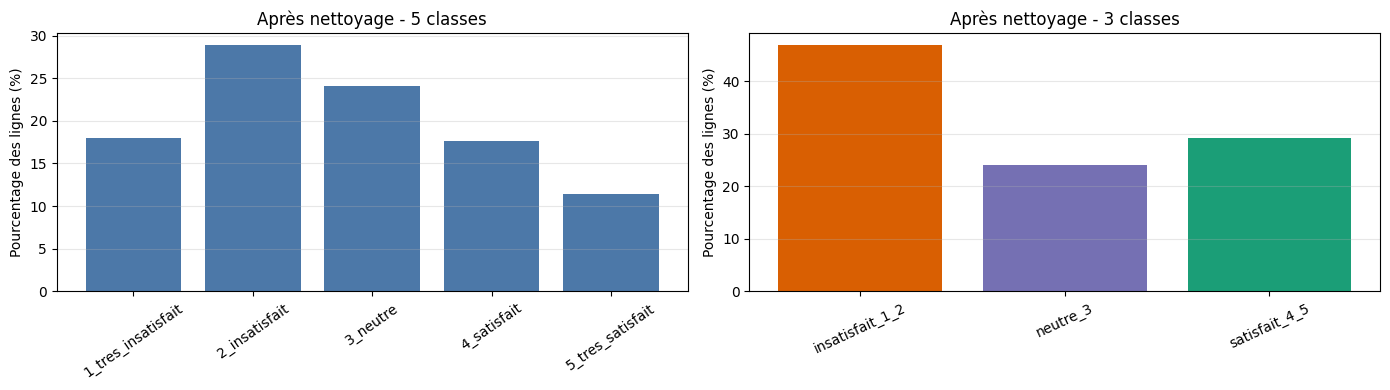

Conclusion sur l'équilibre des classes après nettoyage


,point,conclusion
0,Classe majoritaire,La classe la plus représentée après regroupeme...
1,Classe minoritaire,La classe la moins représentée est neutre_3 (2...
2,Niveau d'équilibre,L'écart entre classe majoritaire et minoritair...
3,Impact sur la modélisation,Le modèle doit être évalué avec macro_f1 et ba...
4,Décision méthodologique,La suite du notebook utilise une séparation tr...


In [249]:
def satisfaction_3_classes_apres_nettoyage(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2

libelles_5_classes_apres_nettoyage = {
    1: "1_tres_insatisfait",
    2: "2_insatisfait",
    3: "3_neutre",
    4: "4_satisfait",
    5: "5_tres_satisfait",
}

libelles_3_classes_apres_nettoyage = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def calculer_distribution_apres_nettoyage(y: pd.Series, libelles: dict[int, str], cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]


distribution_nettoyage_5_classes = calculer_distribution_apres_nettoyage(
    df_model[TARGET_COLUMN].astype(int),
    libelles_5_classes_apres_nettoyage,
    "satisfaction_client_5_classes_apres_nettoyage",
)

distribution_nettoyage_3_classes = calculer_distribution_apres_nettoyage(
    df_model[TARGET_COLUMN].astype(int).apply(satisfaction_3_classes_apres_nettoyage),
    libelles_3_classes_apres_nettoyage,
    "satisfaction_client_3_classes_apres_nettoyage",
)

print("Équilibre des classes après nettoyage")
display(distribution_nettoyage_5_classes)
display(distribution_nettoyage_3_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(
    distribution_nettoyage_5_classes["libelle"],
    distribution_nettoyage_5_classes["pourcentage"],
    color="#4c78a8",
)
axes[0].set_title("Après nettoyage - 5 classes")
axes[0].set_ylabel("Pourcentage des lignes (%)")
axes[0].tick_params(axis="x", rotation=35)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(
    distribution_nettoyage_3_classes["libelle"],
    distribution_nettoyage_3_classes["pourcentage"],
    color=["#d95f02", "#7570b3", "#1b9e77"],
)
axes[1].set_title("Après nettoyage - 3 classes")
axes[1].set_ylabel("Pourcentage des lignes (%)")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

classe_majoritaire_3 = distribution_nettoyage_3_classes.sort_values(
    "pourcentage", ascending=False
).iloc[0]
classe_minoritaire_3 = distribution_nettoyage_3_classes.sort_values(
    "pourcentage", ascending=True
).iloc[0]
ecart_classes_3 = round(
    classe_majoritaire_3["pourcentage"] - classe_minoritaire_3["pourcentage"], 2
)

if ecart_classes_3 >= 20:
    niveau_desequilibre = "déséquilibre important"
elif ecart_classes_3 >= 10:
    niveau_desequilibre = "déséquilibre modéré"
else:
    niveau_desequilibre = "équilibre acceptable"

conclusion_equilibre_apres_nettoyage = pd.DataFrame([
    {
        "point": "Classe majoritaire",
        "conclusion": (
            f"La classe la plus représentée après regroupement est "
            f"{classe_majoritaire_3['libelle']} "
            f"({classe_majoritaire_3['pourcentage']:.2f} %)."
        ),
    },
    {
        "point": "Classe minoritaire",
        "conclusion": (
            f"La classe la moins représentée est "
            f"{classe_minoritaire_3['libelle']} "
            f"({classe_minoritaire_3['pourcentage']:.2f} %)."
        ),
    },
    {
        "point": "Niveau d'équilibre",
        "conclusion": (
            f"L'écart entre classe majoritaire et minoritaire est de "
            f"{ecart_classes_3:.2f} points : {niveau_desequilibre}."
        ),
    },
    {
        "point": "Impact sur la modélisation",
        "conclusion": (
            "Le modèle doit être évalué avec macro_f1 et balanced_accuracy, "
            "car l'accuracy seule peut masquer une mauvaise performance sur les classes moins représentées."
        ),
    },
    {
        "point": "Décision méthodologique",
        "conclusion": (
            "La suite du notebook utilise une séparation train/test stratifiée "
            "et des diagnostics par classe pour conserver une évaluation fiable."
        ),
    },
])

print("Conclusion sur l'équilibre des classes après nettoyage")
display(conclusion_equilibre_apres_nettoyage)


#### Interprétation des résultats après nettoyage

Après nettoyage métier, le dataset contient `1399` séjours exploitables. Le regroupement en 3 classes montre une classe majoritaire `insatisfait_1_2` d'environ `46.82 %`, contre `24.09 %` pour `neutre_3` et `29.09 %` pour `satisfait_4_5`.

La cible est donc déséquilibrée. Pour éviter une lecture trop favorable de l'`accuracy`, l'évaluation du modèle repose principalement sur `macro_f1`, `balanced_accuracy`, le split stratifié et la matrice de confusion.


### 3.6 Feature engineering


#### Pertinence métier des variables préparées

Les variables créées dans le feature engineering servent à transformer les colonnes brutes en indicateurs plus directement exploitables par le modèle et plus lisibles pour le métier.

- Les variables pré-voyage dérivées sont utilisables avant le départ et peuvent donc entrer dans le modèle industrialisé : `budget_par_jour`, `part_vol_budget`, `sejour_long`, `meteo_risque`, `client_business` et `hebergement_luxe`.
- `budget_par_jour` mesure le niveau de confort budgétaire quotidien du séjour.
- `part_vol_budget` mesure le poids du transport dans le budget total et permet d'identifier un budget potentiellement tendu.
- `sejour_long` distingue les séjours longs, qui peuvent impliquer plus de complexité logistique.
- `meteo_risque` identifie les séjours exposés à une météo défavorable ou variable.
- `client_business` isole les voyages professionnels, dont les attentes peuvent différer des voyages loisirs.
- `hebergement_luxe` repère les hébergements de type `resort` ou `villa`, associés à un niveau d'attente plus élevé.
- Les variables post-voyage explicatives sont créées uniquement pour l'analyse post-voyage : `imprevu_present`, `imprevu_transport` et `imprevu_meteo`.
- Les variables post-voyage brutes `imprevus`, `reorganisation_necessaire` et `respect_budget` sont conservées pour le modèle post-voyage, mais exclues du modèle pré-voyage pour éviter la fuite de données.
- Le dataset final `df_model` reste contrôlé avant la séparation train/test : dimensions, exemples de variables créées, valeurs manquantes et équilibre des classes.


In [250]:
def ajouter_features_base(df_source: pd.DataFrame) -> pd.DataFrame:
    df = df_source.copy()

    safe_duree = df["duree_jours"].replace(0, np.nan)
    safe_budget = df["budget_total"].replace(0, np.nan)

    def indicateur(condition: pd.Series, missing_mask: pd.Series) -> pd.Series:
        return pd.Series(
            np.where(missing_mask, np.nan, condition.astype(int)),
            index=df.index,
        )

    df["budget_par_jour"] = df["budget_total"] / safe_duree
    df["part_vol_budget"] = df["prix_vol"] / safe_budget
    df["sejour_long"] = indicateur(df["duree_jours"] >= 14, df["duree_jours"].isna())
    df["meteo_risque"] = indicateur(
        df["meteo_prevue"].isin(["pluie", "variable"]),
        df["meteo_prevue"].isna(),
    )
    df["client_business"] = indicateur(
        df["client_type"] == "business",
        df["client_type"].isna(),
    )
    df["hebergement_luxe"] = indicateur(
        df["type_hebergement"].isin(["resort", "villa"]),
        df["type_hebergement"].isna(),
    )


    # Variables post-voyage explicatives : utilisées uniquement dans le modele post-voyage.
    df["imprevu_present"] = indicateur(df["imprevus"] != "aucun", df["imprevus"].isna())
    df["imprevu_transport"] = indicateur(
        df["imprevus"].isin(["retard_vol", "annulation", "bagages"]),
        df["imprevus"].isna(),
    )
    df["imprevu_meteo"] = indicateur(
        df["imprevus"].isin(["météo", "meteo", "météo"]),
        df["imprevus"].isna(),
    )

    for column in ["budget_par_jour", "part_vol_budget"]:
        df[column] = df[column].replace([np.inf, -np.inf], np.nan)

    for column in df.select_dtypes(include=["object", "string"]).columns:
        df[column] = df[column].mask(df[column].isna(), np.nan).astype(object)

    return df


df_model = ajouter_features_base(df_model)

features_base = [
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]

features_post_voyage_explicatives = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
]

print("Dimensions apres feature engineering :", df_model.shape)
display(df_model[features_base + [TARGET_COLUMN]].head())
print(f"Valeurs manquantes avant pipeline : {int(df_model.isna().sum().sum())}")

Dimensions apres feature engineering : (1399, 24)


,budget_par_jour,part_vol_budget,sejour_long,meteo_risque,client_business,hebergement_luxe,satisfaction_client
0,1849.633333,0.238024,0.0,0.0,0.0,0.0,3
1,274.022500,0.463493,0.0,1.0,1.0,0.0,4
2,834.198750,0.066077,1.0,0.0,0.0,1.0,5
3,414.671765,0.119781,1.0,0.0,0.0,0.0,3
4,1087.560000,0.142027,0.0,1.0,0.0,0.0,2


Valeurs manquantes avant pipeline : 381



#### 3.6.1 Liste de features

#### Variables pré-voyage brutes

- `client_type`
- `budget_total`
- `destination`
- `saison`
- `duree_jours`
- `type_hebergement`
- `prix_vol`
- `meteo_prevue`
- `activite_principale`

#### Variables pré-voyage dérivées conservées

- `budget_par_jour`
- `part_vol_budget`
- `sejour_long`
- `meteo_risque`
- `client_business`
- `hebergement_luxe`

#### Variables post-voyage conservées uniquement pour le modèle post-voyage

- `imprevus`
- `reorganisation_necessaire`
- `respect_budget`
- `imprevu_present`
- `imprevu_transport`
- `imprevu_meteo`


#### 3.6.2 Vérification de la cible après feature engineering

Le feature engineering ajoute des variables explicatives dans `df_model`, mais ne modifie pas la cible `satisfaction_client`. Cette vérification sert uniquement à confirmer que la distribution des classes reste identique à celle observée après nettoyage.


In [251]:
# Fonction commune utilisée ensuite par les modèles pré-voyage et post-voyage.
# Elle transforme la note de satisfaction 1-5 en cible 3 classes.
def regrouper_satisfaction_3_classes(value: int) -> int:
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2

libelles_satisfaction_3 = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}

libelles_satisfaction_5 = {
    1: "note_1_tres_insatisfait",
    2: "note_2_insatisfait",
    3: "note_3_neutre",
    4: "note_4_satisfait",
    5: "note_5_tres_satisfait",
}

def distribution_classes(y: pd.Series, libelles: dict[int, str], nom_cible: str) -> pd.DataFrame:
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["libelle"] = distribution["classe"].map(libelles)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    distribution["cible"] = nom_cible
    return distribution[["cible", "classe", "libelle", "nombre", "pourcentage"]]

distribution_satisfaction_3 = distribution_classes(
    df_model[TARGET_COLUMN].astype(int).apply(regrouper_satisfaction_3_classes),
    libelles_satisfaction_3,
    "satisfaction_client_3_classes_dataset_final",
)

controle_equilibre_final = distribution_satisfaction_3.copy()

print("Vérification courte de la cible sur le dataset final df_model")
display(controle_equilibre_final)



Vérification courte de la cible sur le dataset final df_model


,cible,classe,libelle,nombre,pourcentage
0,satisfaction_client_3_classes_dataset_final,0,insatisfait_1_2,655,46.82
1,satisfaction_client_3_classes_dataset_final,1,neutre_3,337,24.09
2,satisfaction_client_3_classes_dataset_final,2,satisfait_4_5,407,29.09


#### Interprétation synthétique

La distribution de la cible reste identique à celle observée après le nettoyage : le feature engineering n'a pas créé, supprimé ou modifié de classe de satisfaction.

Le dataset final conserve donc le même déséquilibre de classes, avec une classe `insatisfait_1_2` majoritaire. Cette vérification confirme que la suite du notebook doit conserver le split stratifié, `macro_f1`, `balanced_accuracy` et la matrice de confusion pour évaluer correctement les modèles.


### Valeurs calculées des KPI métier

Les KPI métier ci-dessous sont calculés sur le dataset final nettoyé `df_model`. Ils résument brièvement le niveau de satisfaction et d'insatisfaction observé dans les séjours historiques.


In [ ]:
# KPI métier principaux calculés sur le dataset final nettoyé.
# Ces indicateurs ne sont pas déduits du modèle : ils décrivent la réalité observée dans les données.

kpi_metier_valeurs = pd.DataFrame([
    {
        "KPI métier": "Taux de satisfaction client",
        "Valeur": round(df_model[TARGET_COLUMN].isin([4, 5]).mean() * 100, 2),
        "Unité": "%",
        "Lecture métier": "Part des séjours avec une note 4 ou 5.",
    },
    {
        "KPI métier": "Taux d'insatisfaction client",
        "Valeur": round(df_model[TARGET_COLUMN].isin([1, 2]).mean() * 100, 2),
        "Unité": "%",
        "Lecture métier": "Part des séjours avec une note 1 ou 2.",
    },
])

display(kpi_metier_valeurs)



#### Lecture courte des KPI métier

Sur le dataset final nettoyé, le taux de satisfaction client est de `29.09 %` et le taux d'insatisfaction client est de `46.82 %`. La part de séjours insatisfaisants est donc supérieure à la part de séjours satisfaisants, ce qui justifie un outil d'aide à l'anticipation du risque avant départ.


### 3.7 Stockage, cycle de vie et gouvernance du dataset

Cette section synthétise comment les données TravelMind sont stockées, versionnées et encadrées. L'objectif est d'assurer la traçabilité du dataset sans répéter les traitements déjà détaillés dans les sections précédentes.

#### Stockage retenu

| Objet | Emplacement | Rôle |
| --- | --- | --- |
| Dataset brut | `data/Examen_travel_planning_dataset.csv` | Source initiale du projet |
| Versions de données | `data/versions/` | Historiser les étapes majeures de transformation |
| Dataset de travail | `df_model` dans le notebook | Dataset reconstruit après nettoyage et feature engineering |
| Pipelines ML | Objets `Pipeline` / `ColumnTransformer` | Appliquer imputation, outliers, encodage et standardisation sans fuite train/test |
| Artefacts modèle | `models/` | Modèle pré-voyage exporté par `train.py`, non versionné dans Git |
| Logs et monitoring | `logs/predictions/` | Suivre les prédictions API, la confiance et les dérives, non versionné dans Git |

Le CSV local est adapté au prototype. En production avec données clients réelles, il faudrait passer à un stockage contrôlé : base de données ou object storage, gestion des accès, sauvegardes, registre des versions et validation RGPD.

#### Cycle de vie et versioning des données

| Phase | Version / objet | Emplacement | Finalité |
| --- | --- | --- | --- |
| Données brutes | `v1.0` | `data/versions/v1_0_raw/travel_planning_dataset_v1_0.csv` | Conserver la source fournie sans transformation |
| Nettoyage des formats | `v1.1` | `data/versions/v1_1_cleaning/travel_planning_dataset_v1_1.csv` | Harmoniser textes, espaces, casse et formats numériques |
| Nettoyage des incohérences critiques | `v1.2` | `data/versions/v1_2_incoherences/travel_planning_dataset_v1_2.csv` | Retirer les lignes incompatibles avec l'apprentissage supervisé |
| Feature engineering | `v2.0` / `df_model` | `data/versions/v2_0_feature_engineering/travel_planning_dataset_v2_0.csv` | Ajouter les variables retenues pour les cas pré-voyage et post-voyage |
| Modélisation | `X_pre`, `X_post`, `y_pre`, `y_post` | Notebook final | Séparer les variables selon le moment d'utilisation pour éviter la fuite de données |
| Industrialisation | `train.py`, API, dashboard | `models/`, `app/`, `logs/` | Exporter et servir le modèle pré-voyage avec monitoring |

Le script `scripts/version_data.py` regénère les versions. Le manifeste `data/versions/manifest.json` trace les lignes, colonnes, transformations et empreintes SHA-256. Le détail est documenté dans `docs/data_versioning.md`.

#### Règles de gouvernance

- Les données préparées doivent rester reproductibles depuis le CSV brut.
- Les variables post-voyage sont exclues du modèle pré-voyage pour éviter la fuite de données.
- Les artefacts lourds, logs, runs MLflow et modèles exportés restent hors Git.
- Toute future donnée réelle devra faire l'objet d'une validation RGPD, d'une politique d'accès, d'une durée de conservation et d'une revue juridique.

#### Conclusion

La gouvernance actuelle est suffisante pour ce projet : données locales, cycle de vie versionné, transformations reproductibles et modèle pré-voyage exportable. Avant tout passage en production, ce cycle de vie devra être soumis explicitement au commanditaire, au DPO/RGPD et à la DSI afin de valider le stockage, les accès, la durée de conservation, les règles de sécurité et les conditions de réutilisation des données.


### 3.8 Segmentation client par clustering pré-voyage

Le clustering est une analyse exploratoire non supervisée. Il sert à regrouper des séjours similaires à partir des informations connues avant le départ, sans utiliser la cible `satisfaction_client`.

#### Lien avec l'ambition métier

Cette partie répond principalement à l'axe de recommandations personnalisées : mieux comprendre les profils de voyageurs pour adapter les destinations, hébergements et activités proposés.


Nombre de clusters retenu : 2
Scores de silhouette testés :


,k,silhouette
0,2,0.1496
1,3,0.1419
2,4,0.1286
3,5,0.1214
4,6,0.1169


Profil synthétique des segments clients :


,segment_client,libelle_segment_metier,nb_sejours,part_lignes_pct,client_type_majoritaire,destination_majoritaire,saison_majoritaire,hebergement_majoritaire,activite_majoritaire,budget_moyen,duree_moyenne,prix_vol_moyen,part_vol_budget_moyenne
0,0,profil_sejour_long,390,27.88,senior,new york,automne,appartement,plage,9696.113,16.756,1114.392,0.149
1,1,profil_business,1009,72.12,business,new york,été,villa,culture,6547.667,8.080,1114.926,0.239


Exemples de séjours par segment :


,segment_client,trip_id,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,activite_principale
0,0,878,famille,bali,printemps,14,hôtel,500.00,50.0,plage
1,0,895,solo,bali,automne,15,hôtel,500.00,NaN,business
2,0,835,famille,new york,été,14,appartement,1265.55,1009.5,culture
3,1,884,couple,bali,été,13,villa,500.00,35.0,plage
4,1,1454,senior,tokyo,automne,4,hôtel,500.00,NaN,culture
5,1,39,senior,lisbonne,été,6,appartement,853.14,577.9,randonnée


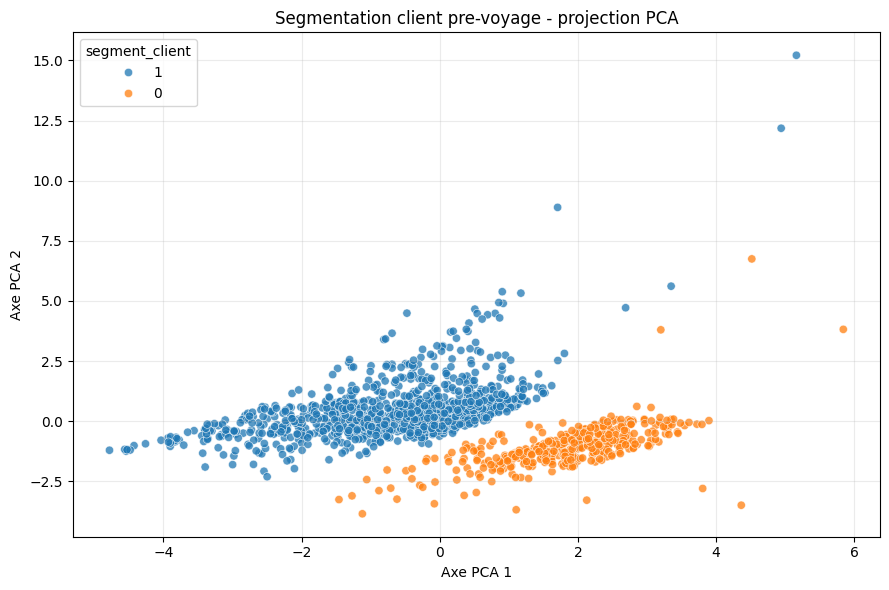

In [252]:
# Variables pre-voyage uniquement : connues avant la réalisation du séjour.
features_clustering_pre_voyage = [
    "client_type",
    "budget_total",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
    "budget_par_jour",
    "part_vol_budget",
    "sejour_long",
    "meteo_risque",
    "client_business",
    "hebergement_luxe",
]
features_clustering_pre_voyage = [
    col for col in features_clustering_pre_voyage if col in df_model.columns
]

X_clustering = df_model[features_clustering_pre_voyage].copy()

colonnes_numeriques_clustering = X_clustering.select_dtypes(include=[np.number]).columns.tolist()
colonnes_categorielles_clustering = [
    col for col in X_clustering.columns if col not in colonnes_numeriques_clustering
]

preprocesseur_clustering = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            colonnes_numeriques_clustering,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            colonnes_categorielles_clustering,
        ),
    ],
    remainder="drop",
    sparse_threshold=0,
)

X_clustering_prepare = preprocesseur_clustering.fit_transform(X_clustering)
X_clustering_prepare = np.asarray(X_clustering_prepare, dtype=float)

# Choix exploratoire du nombre de clusters avec le score de silhouette.
scores_silhouette = []
for k in range(2, 7):
    modele_kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = modele_kmeans.fit_predict(X_clustering_prepare)
    scores_silhouette.append({
        "k": k,
        "silhouette": silhouette_score(X_clustering_prepare, labels),
    })

silhouette_clustering = pd.DataFrame(scores_silhouette)
k_retenu = int(
    silhouette_clustering.sort_values("silhouette", ascending=False).iloc[0]["k"]
)

modele_segmentation_client = KMeans(
    n_clusters=k_retenu,
    random_state=RANDOM_STATE,
    n_init=10,
)
segments_client = modele_segmentation_client.fit_predict(X_clustering_prepare)

df_segments = df_model.copy()
df_segments["segment_client"] = segments_client.astype(int)

count_column = "trip_id" if "trip_id" in df_segments.columns else "budget_total"
aggregations_segments = {
    "nb_sejours": (count_column, "count"),
    "budget_moyen": ("budget_total", "mean"),
    "duree_moyenne": ("duree_jours", "mean"),
    "prix_vol_moyen": ("prix_vol", "mean"),
    "part_vol_budget_moyenne": ("part_vol_budget", "mean"),
}

# Variables post-voyage utilisées uniquement pour lire les segments aprés création.
if TARGET_COLUMN in df_segments.columns:
    aggregations_segments["satisfaction_moyenne"] = (TARGET_COLUMN, "mean")
if "respect_budget" in df_segments.columns:
    aggregations_segments["taux_budget_respecte"] = ("respect_budget", "mean")
if "reorganisation_necessaire" in df_segments.columns:
    aggregations_segments["taux_reorganisation"] = ("reorganisation_necessaire", "mean")

profil_segments = (
    df_segments
    .groupby("segment_client")
    .agg(**aggregations_segments)
    .reset_index()
)
profil_segments["part_lignes_pct"] = (
    profil_segments["nb_sejours"] / len(df_segments) * 100
).round(2)

def mode_safe(series: pd.Series):
    values = series.dropna()
    if values.empty:
        return "non_disponible"
    return values.mode().iloc[0]

variables_categorielles_description = [
    "client_type",
    "destination",
    "saison",
    "type_hebergement",
    "activite_principale",
]
variables_categorielles_description = [
    col for col in variables_categorielles_description if col in df_segments.columns
]

profil_categoriel_segments = (
    df_segments
    .groupby("segment_client")[variables_categorielles_description]
    .agg(mode_safe)
    .reset_index()
)
profil_categoriel_segments = profil_categoriel_segments.rename(columns={
    "client_type": "client_type_majoritaire",
    "destination": "destination_majoritaire",
    "saison": "saison_majoritaire",
    "type_hebergement": "hebergement_majoritaire",
    "activite_principale": "activite_majoritaire",
})

profil_segments = profil_segments.merge(
    profil_categoriel_segments,
    on="segment_client",
    how="left",
)

def proposer_libelle_segment(row: pd.Series) -> str:
    if row.get("client_type_majoritaire") == "business":
        return "profil_business"
    if row.get("hebergement_majoritaire") in ["resort", "villa"]:
        return "profil_premium_loisir"
    if row.get("duree_moyenne", 0) >= df_segments["duree_jours"].median():
        return "profil_sejour_long"
    return "profil_standard"

profil_segments["libelle_segment_metier"] = profil_segments.apply(
    proposer_libelle_segment,
    axis=1,
)

print(f"Nombre de clusters retenu : {k_retenu}")
print("Scores de silhouette testés :")
display(silhouette_clustering.round(4))

colonnes_resume_segments = [
    "segment_client",
    "libelle_segment_metier",
    "nb_sejours",
    "part_lignes_pct",
    "client_type_majoritaire",
    "destination_majoritaire",
    "saison_majoritaire",
    "hebergement_majoritaire",
    "activite_majoritaire",
    "budget_moyen",
    "duree_moyenne",
    "prix_vol_moyen",
    "part_vol_budget_moyenne",
]
colonnes_resume_segments = [
    col for col in colonnes_resume_segments if col in profil_segments.columns
]

resume_segments_client = (
    profil_segments[colonnes_resume_segments]
    .sort_values("segment_client")
    .reset_index(drop=True)
)

print("Profil synthétique des segments clients :")
display(resume_segments_client.round(3))

colonnes_exemples_segments = [
    "segment_client",
    "trip_id",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "activite_principale",
]
colonnes_exemples_segments = [
    col for col in colonnes_exemples_segments if col in df_segments.columns
]

exemples_segments_client = (
    df_segments
    .sort_values(["segment_client", "budget_total"])
    .groupby("segment_client", group_keys=False)
    .head(3)[colonnes_exemples_segments]
    .reset_index(drop=True)
)

print("Exemples de séjours par segment :")
display(exemples_segments_client)

# Projection 2D pour visualiser les segments.
pca_segments = PCA(n_components=2, random_state=RANDOM_STATE)
projection_segments = pca_segments.fit_transform(X_clustering_prepare)
projection_segments = pd.DataFrame({
    "axe_1": projection_segments[:, 0],
    "axe_2": projection_segments[:, 1],
    "segment_client": df_segments["segment_client"].astype(str),
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=projection_segments,
    x="axe_1",
    y="axe_2",
    hue="segment_client",
    palette="tab10",
    alpha=0.75,
)
plt.title("Segmentation client pre-voyage - projection PCA")
plt.xlabel("Axe PCA 1")
plt.ylabel("Axe PCA 2")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Interprétation technique de la segmentation

La segmentation utilise `KMeans`. Avant l'entraînement, les variables sont préparées selon leur type afin que l'algorithme puisse calculer correctement les distances entre séjours.

- Les variables numériques sont imputées par la médiane, car elle est plus robuste que la moyenne en présence de valeurs extrêmes. Elles sont ensuite standardisées avec `StandardScaler` pour éviter qu'une variable comme `budget_total` domine les distances uniquement parce que ses valeurs sont plus grandes.
- Les variables catégorielles sont imputées par la valeur la plus fréquente, car cela conserve une modalité plausible sans inventer une nouvelle catégorie. Elles sont ensuite encodées avec `OneHotEncoder`.
- `OneHotEncoder` est choisi car les catégories comme `destination`, `saison` ou `type_hebergement` ne sont pas ordinales. Un encodage par nombres simples ferait croire à l'algorithme qu'il existe un ordre ou une distance mathématique entre les modalités, ce qui serait faux.

Le nombre de segments est choisi de manière exploratoire : le notebook teste plusieurs valeurs de `k`, de 2 à 6, puis retient celle qui maximise le score de silhouette. Le nombre final est donc affiché par la variable `k_retenu`.

Chaque segment est ensuite décrit avec des indicateurs moyens (`budget_moyen`, `duree_moyenne`, `prix_vol_moyen`, `part_vol_budget_moyenne`) et des modalités majoritaires (`client_type`, `destination`, `saison`, `type_hebergement`, `activite_principale`). Ces informations permettent de proposer un libellé métier simple.

Les variables post-voyage ne sont pas utilisées pour créer les clusters ; elles servent uniquement à lire les segments après coup. La projection PCA est seulement un support visuel et ne remplace pas l'analyse des tableaux de profils.


#### Interprétation métier de la segmentation

Les segments doivent être lus comme des profils clients exploitables par l'agence, pas comme des décisions automatiques. Ils peuvent servir à personnaliser les recommandations, prioriser l'accompagnement avant départ et produire un reporting métier plus lisible.

Les libellés comme `profil_business`, `profil_premium_loisir`, `profil_sejour_long` ou `profil_standard` sont des interprétations simples des caractéristiques dominantes de chaque segment. Ils doivent être validés par les acteurs métier avant toute utilisation opérationnelle.

Limites : le clustering dépend des variables disponibles, les segments peuvent changer si les données évoluent, et ils ne doivent pas conduire à exclure automatiquement un client d'une offre ou d'un service.


## Partie 4 - Modélisation : choix, entraînement et validation

Cette partie regroupe la démarche de modélisation du projet TravelMind. Elle couvre à la fois le choix des familles de modèles, l'entraînement supervisé, la validation et la comparaison des résultats.

Deux objectifs sont distingués :

- le modèle pré-voyage, utilisable avant le départ et retenu pour l'industrialisation ;
- le modèle post-voyage, utilisé comme analyse complémentaire pour comprendre l'apport des variables opérationnelles observées après le séjour.

La démarche repose sur plusieurs principes : split train/test stratifié, pipelines `scikit-learn`, exclusion des variables de fuite, comparaison à une baseline, suivi de `macro_f1`, `balanced_accuracy`, matrice de confusion, validation croisée et diagnostics d'overfitting / underfitting.


In [253]:
class IQRMedianOutlierReplacer(BaseEstimator, TransformerMixin):
    """Remplace les outliers IQR par la mediane apprise sur le train."""

    def __init__(self, factor: float = 1.5):
        # factor=1.5 correspond a la règle IQR classique : Q1 - 1.5*IQR / Q3 + 1.5*IQR.
        self.factor = factor

    def fit(self, X, y=None):
        # Les bornes IQR et la médiane sont apprises uniquement sur le jeu transmis au fit.
        # Dans un Pipeline sklearn, ce fit est appelé uniquement sur le train.
        X_array = np.asarray(X, dtype=float)
        self.q1_ = np.nanquantile(X_array, 0.25, axis=0)
        self.q3_ = np.nanquantile(X_array, 0.75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        self.lower_bounds_ = self.q1_ - self.factor * self.iqr_
        self.upper_bounds_ = self.q3_ + self.factor * self.iqr_
        self.medians_ = np.nanmedian(X_array, axis=0)
        return self

    def transform(self, X):
        # Les valeurs hors bornes sont remplacées par la médiane apprise au fit.
        X_array = np.asarray(X, dtype=float).copy()
        outlier_mask = (
            (X_array < self.lower_bounds_)
            | (X_array > self.upper_bounds_)
        )
        return np.where(outlier_mask, self.medians_, X_array)

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.asarray([f"x{i}" for i in range(len(self.medians_))], dtype=object)
        return np.asarray(input_features, dtype=object)


# Certaines colonnes exploratoires peuvent contenir des listes ou dictionnaires.
# Ces valeurs ne sont pas compatibles avec les opérations d'encodage ou de groupby.
def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()


def detecter_variables_binaires(X: pd.DataFrame, numeric_features: list[str]) -> list[str]:
    # Les variables binaires 0/1 ne sont pas standardisees comme des variables continues.
    binary_features = []
    for column in numeric_features:
        if contient_valeur_non_hashable(X[column]):
            continue
        try:
            values = pd.Series(X[column].dropna().unique())
            unique_values = set(values.astype(float).tolist())
        except (TypeError, ValueError):
            continue
        if values.empty:
            continue
        if unique_values.issubset({0.0, 1.0}):
            binary_features.append(column)
    return binary_features


def construire_preprocesseur(X: pd.DataFrame) -> tuple[ColumnTransformer, list[str], list[str]]:
    # 1. Exclure les colonnes non compatibles avec sklearn si elles existent.
    non_hashable_features = [
        column for column in X.columns
        if contient_valeur_non_hashable(X[column])
    ]
    if non_hashable_features:
        print("Colonnes ignorees par le preprocesseur car elles contiennent des listes/dictionnaires :", non_hashable_features)

    X_compatible = X.drop(columns=non_hashable_features, errors="ignore")

    # 2. Séparer les variables numeriques et categorielles pour appliquer les bons traitements.
    numeric_features = X_compatible.select_dtypes(include="number").columns.tolist()
    categorical_features = X_compatible.select_dtypes(include=["object", "string", "category"]).columns.tolist()

    # 3. Distinguer numériques continues et indicateurs binaires.
    binary_numeric_features = detecter_variables_binaires(X_compatible, numeric_features)
    continuous_numeric_features = [
        column for column in numeric_features
        if column not in binary_numeric_features
    ]

    # 4. Numériques continues : mediane -> IQR -> standardisation.
    continuous_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("outliers_iqr", IQRMedianOutlierReplacer()),
        ("scaler", StandardScaler()),
    ])

    # 5. Numériques binaires : imputation simple, pas de standardisation.
    binary_numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
    ])

    # 6. Catégorielles : modalité la plus frequente puis OneHotEncoder.
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    transformers = []
    if continuous_numeric_features:
        transformers.append(("num_cont", continuous_numeric_transformer, continuous_numeric_features))
    if binary_numeric_features:
        transformers.append(("num_bin", binary_numeric_transformer, binary_numeric_features))
    if categorical_features:
        transformers.append(("cat", categorical_transformer, categorical_features))

    preprocess = ColumnTransformer(transformers=transformers)

    return preprocess, numeric_features, categorical_features


def evaluer_classification(modeles: dict, X_train, X_test, y_train, y_test, preprocess) -> tuple[pd.DataFrame, dict]:
    # Cette fonction entraine chaque modèle avec le même pipeline de préparation,
    # puis compare les performances sur le même jeu de test.
    rows = []
    fitted = {}

    for model_name, model in modeles.items():
        # clone() évite qu'un modele ou preprocesseur ajuste contamine l'expérience suivante.
        pipeline = Pipeline(steps=[
            ("preprocess", clone(preprocess)),
            ("model", clone(model)),
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)

        rows.append({
            "modele": model_name,
            "accuracy": accuracy_score(y_test, predictions),
            "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
            "macro_f1": f1_score(y_test, predictions, average="macro"),
        })
        fitted[model_name] = pipeline

    # Le macro_f1 est prioritaire car il donne le même poids à chaque classe.
    results = (
        pd.DataFrame(rows)
        .sort_values("macro_f1", ascending=False)
        .reset_index(drop=True)
    )

    return results, fitted


def afficher_distribution(y: pd.Series, label: str) -> None:
    # Contrôle rapide de l'équilibre des classes avant ou après split.
    print(label)
    display(
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
        .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
    )

### 4.0 Pipeline de préparation utilisé pour la modélisation

Le pipeline applique les traitements apprenant des paramètres après la séparation train/test afin d'éviter la fuite de données.

```text
Données nettoyées df_model
-> définition de X et y selon l'objectif pré-voyage ou post-voyage
-> split train/test stratifié
-> imputation apprise uniquement sur le train
-> traitement IQR des outliers appris uniquement sur le train
-> encodage OneHotEncoder appris uniquement sur le train
-> standardisation apprise uniquement sur le train
-> entraînement du modèle sur train
-> prédiction et évaluation sur test non vu
```

Cette organisation garantit que le jeu de test reste non vu jusqu'à l'évaluation finale.


### 4.1 Préparation pré-voyage : périmètre, cible et split

Cette section prépare les données utilisables avant le départ. Elle définit les variables autorisées dans `X_pre`, construit deux versions de la cible et réalise le split train/test stratifié.

Deux formulations de la cible sont comparées :

- `satisfaction_client` en 5 classes : notes originales `1`, `2`, `3`, `4`, `5` ;
- `satisfaction_client` regroupée en 3 classes : `insatisfait_1_2`, `neutre_3`, `satisfait_4_5`.

L'expérience en 5 classes est volontairement placée avant la modélisation 3 classes. Elle sert à vérifier si le problème initial est trop fin pour les variables pré-voyage disponibles.

La cible 3 classes est ensuite utilisée comme formulation retenue pour le modèle industrialisé, car elle correspond mieux à une lecture métier exploitable : risque d'insatisfaction, satisfaction neutre ou satisfaction positive.


In [254]:
# Colonnes connues uniquement pendant ou après le voyage.
# Elles sont exclues du modele pre-voyage pour éviter la fuite de donnees.
post_trip_columns = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "retour_client",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
]

# Colonnes techniques sans signal métier direct.
technical_columns = ["trip_id"]

# Selection des variables autorisées avant depart.
excluded_pre_voyage = [TARGET_COLUMN, *technical_columns, *post_trip_columns]
feature_columns_pre = [
    column for column in df_model.columns
    if column not in excluded_pre_voyage
]

def est_hashable(valeur) -> bool:
    try:
        hash(valeur)
        return True
    except TypeError:
        return False


def contient_valeur_non_hashable(serie: pd.Series) -> bool:
    valeurs = serie.dropna().head(1000)
    return valeurs.map(lambda valeur: not est_hashable(valeur)).any()


colonnes_non_hashables_pre = [
    column for column in feature_columns_pre
    if contient_valeur_non_hashable(df_model[column])
]

if colonnes_non_hashables_pre:
    print("Colonnes exclues car non compatibles avec l'encodage :", colonnes_non_hashables_pre)

feature_columns_pre = [
    column for column in feature_columns_pre
    if column not in colonnes_non_hashables_pre
]

# X_pre contient uniquement les informations disponibles avant le départ.
X_pre = df_model[feature_columns_pre].copy()

# y_pre_5 conserve les notes originales 1 à 5.
y_pre_5 = df_model[TARGET_COLUMN].astype(int).copy()

# y_pre est la satisfaction regroupée en 3 classes.
y_pre = y_pre_5.apply(regrouper_satisfaction_3_classes).astype(int).copy()

# Le preprocesseur est defini ici, mais ses paramètres seront appris lors du fit sur le train.
preprocess_pre, numeric_pre, categorical_pre = construire_preprocesseur(X_pre)

resume_pre = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_pre), len(categorical_pre), X_pre.shape[1], len(excluded_pre_voyage)],
    "colonnes": [numeric_pre, categorical_pre, feature_columns_pre, excluded_pre_voyage],
})

# Résume des colonnes utilisées et exclues pour vérifier le perimètre pre-voyage.
display(resume_pre)
afficher_distribution(y_pre_5, "Distribution cible pre-voyage à 5 classes")
afficher_distribution(y_pre, "Distribution cible pre-voyage à 3 classes")


,famille,nombre,colonnes
0,numeriques,9,"[budget_total, duree_jours, prix_vol, budget_p..."
1,categorielles,6,"[client_type, destination, saison, type_heberg..."
2,total,15,"[client_type, budget_total, destination, saiso..."
3,exclues,9,"[satisfaction_client, trip_id, imprevus, reorg..."


Distribution cible pre-voyage à 5 classes


,classe,nombre,pourcentage
0,1,251,17.94
1,2,404,28.88
2,3,337,24.09
3,4,247,17.66
4,5,160,11.44


Distribution cible pre-voyage à 3 classes


,classe,nombre,pourcentage
0,0,655,46.82
1,1,337,24.09
2,2,407,29.09


#### Interprétation de la distribution pré-voyage

Deux distributions sont contrôlées avant la modélisation : la cible originale en 5 notes et la cible regroupée en 3 classes.

En 5 classes, la distribution est plus dispersée : la note `2` est la plus représentée (`28.88 %`), devant la note `3` (`24.09 %`), la note `1` (`17.94 %`), la note `4` (`17.66 %`) et la note `5` (`11.44 %`). La classe `5` est donc la plus rare, ce qui rend la prédiction fine plus difficile.

En 3 classes, le regroupement donne une lecture plus stable : `insatisfait_1_2` représente `46.82 %`, `neutre_3` `24.09 %` et `satisfait_4_5` `29.09 %`.

Ce déséquilibre peut pousser un modèle à favoriser la classe majoritaire si l'évaluation repose uniquement sur l'`accuracy`. C'est pourquoi la suite utilise un split stratifié, `macro_f1`, `balanced_accuracy` et la matrice de confusion.

La comparaison 5 classes / 3 classes permet ensuite de vérifier si le regroupement améliore réellement la performance et la lisibilité métier.


In [255]:
# Split stratifié : conserve la proportion des 3 classes dans train et test.
# Il est fait avant toute opération apprenant des paramètres.
X_train_pre, X_test_pre, y_train_pre, y_test_pre = train_test_split(
    X_pre,
    y_pre,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_pre,
)

labels_satisfaction_3_classes = {
    0: "insatisfait_1_2",
    1: "neutre_3",
    2: "satisfait_4_5",
}


def calculer_equilibre_classes(y: pd.Series, jeu: str) -> pd.DataFrame:
    # Retourne la distribution des classes pour vérifier le déséquilibre global/train/test.
    distribution = (
        y.value_counts()
        .sort_index()
        .rename_axis("classe")
        .reset_index(name="nombre")
    )
    distribution["jeu"] = jeu
    distribution["libelle"] = distribution["classe"].map(labels_satisfaction_3_classes)
    distribution["pourcentage"] = (
        distribution["nombre"] / distribution["nombre"].sum() * 100
    ).round(2)
    return distribution[["jeu", "classe", "libelle", "nombre", "pourcentage"]]


# Comparer global, train et test permet de vérifier que le split stratifié fonctionne.
equilibre_classes_pre = pd.concat(
    [
        calculer_equilibre_classes(y_pre, "global"),
        calculer_equilibre_classes(y_train_pre, "train"),
        calculer_equilibre_classes(y_test_pre, "test"),
    ],
    ignore_index=True,
)

display(equilibre_classes_pre)

classe_majoritaire_pre = equilibre_classes_pre[equilibre_classes_pre["jeu"] == "global"].sort_values(
    "pourcentage",
    ascending=False,
).iloc[0]

print(
    "Classe majoritaire globale : "
    f"{classe_majoritaire_pre['libelle']} "
    f"({classe_majoritaire_pre['pourcentage']} %)"
)


,jeu,classe,libelle,nombre,pourcentage
0,global,0,insatisfait_1_2,655,46.82
1,global,1,neutre_3,337,24.09
2,global,2,satisfait_4_5,407,29.09
3,train,0,insatisfait_1_2,524,46.83
4,train,1,neutre_3,270,24.13
5,train,2,satisfait_4_5,325,29.04
6,test,0,insatisfait_1_2,131,46.79
7,test,1,neutre_3,67,23.93
8,test,2,satisfait_4_5,82,29.29


Classe majoritaire globale : insatisfait_1_2 (46.82 %)


#### Interprétation de l'équilibre train/test pré-voyage

Le tableau montre que la cible conserve le même déséquilibre dans le dataset global, le train et le test : la classe `insatisfait_1_2` est majoritaire avec environ `46.32 %`, devant `satisfait_4_5` autour de `29.60 %` et `neutre_3` autour de `24.08 %`.

La répartition est quasiment identique entre `global`, `train` et `test` : `46.32 % / 24.14 % / 29.54 %` sur le train et `46.33 % / 23.85 % / 29.82 %` sur le test. Cela confirme que le split stratifié fonctionne correctement.

Ce contrôle est placé dans le modèle pré-voyage car la cible `satisfaction_client` est la même pour le pré-voyage et le post-voyage. Il n'est donc pas utile de le répéter dans la partie post-voyage.

Conséquence pour l'évaluation : l'`accuracy` seule peut être trompeuse, car la classe majoritaire pèse presque la moitié du dataset. Les métriques `macro_f1`, `balanced_accuracy` et la matrice de confusion restent donc nécessaires.


### 4.2 Corrélations pré-voyage

Cette cellule mesure le lien entre les variables numériques connues avant le départ et la cible `satisfaction_client` regroupée en 3 classes.

La corrélation de Spearman est utilisée car elle mesure une relation monotone sans supposer une relation linéaire parfaite. Elle est calculée uniquement sur le jeu d'entraînement.

L'objectif n'est pas de choisir le modèle à partir de cette seule analyse, mais de vérifier si les variables pré-voyage contiennent un signal exploitable avant la comparaison des modèles.

La heatmap ajoutée après le tableau permet de visualiser rapidement l'intensité et le sens des corrélations entre les variables numériques pré-voyage et la cible.


,correlation_spearman_satisfaction_3_classes
part_vol_budget,-0.0643
budget_total,0.0632
budget_par_jour,0.0597
hebergement_luxe,0.0476
sejour_long,-0.0276
client_business,-0.0267
meteo_risque,0.0233
duree_jours,0.0088
prix_vol,0.0038


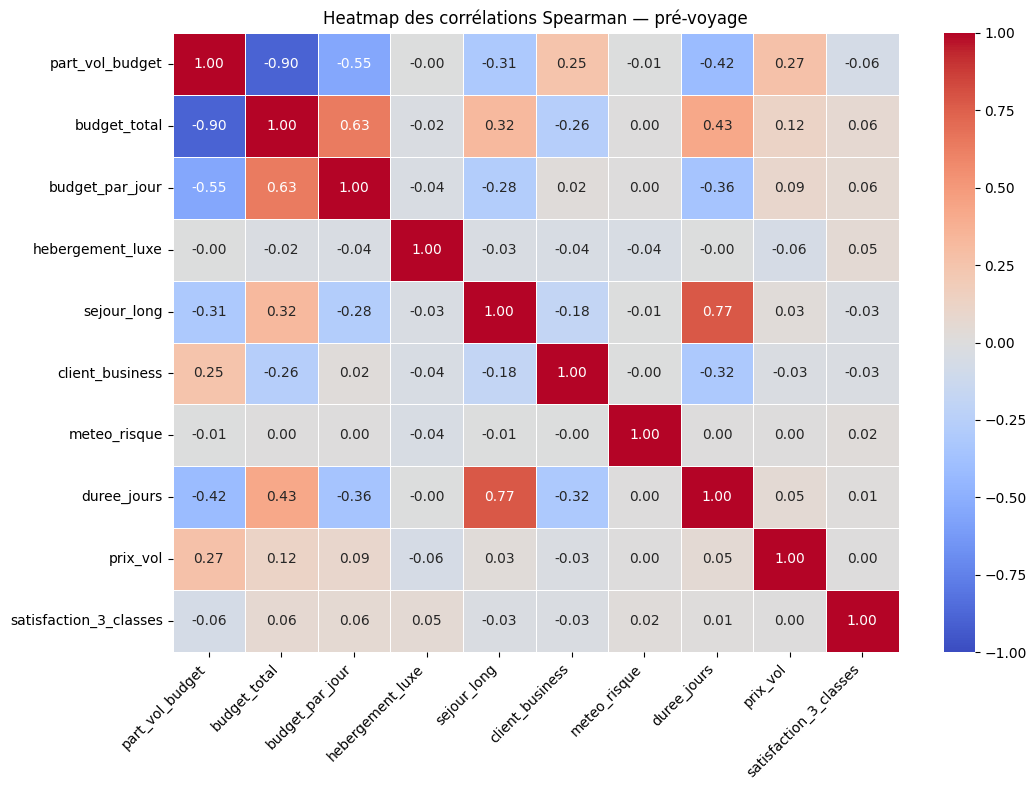

In [256]:
# Analyse simple du lien monotone entre variables numériques pre-voyage et cible.
# Elle est calculée uniquement sur le train pour ne pas utiliser le test dans l'analyse.
correlation_df_pre = X_train_pre[numeric_pre].copy()
correlation_df_pre["satisfaction_3_classes"] = y_train_pre.values

spearman_pre = (
    correlation_df_pre.corr(method="spearman")["satisfaction_3_classes"]
    .drop("satisfaction_3_classes")
    .sort_values(key=lambda values: values.abs(), ascending=False)
)

display(spearman_pre.to_frame("correlation_spearman_satisfaction_3_classes").round(4).head(15))

# Visualisation : heatmap de la matrice de corrélation Spearman.
# Les variables sont ordonnées selon leur lien absolu avec la satisfaction.
variables_heatmap_pre = [
    *spearman_pre.abs().sort_values(ascending=False).index.tolist(),
    "satisfaction_3_classes",
]

correlation_heatmap_pre = correlation_df_pre[variables_heatmap_pre].corr(method="spearman")

plt.figure(figsize=(11, 8))
sns.heatmap(
    correlation_heatmap_pre,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Heatmap des corrélations Spearman — pré-voyage")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


#### Interprétation des corrélations pré-voyage

Les corrélations de Spearman obtenues sont toutes très faibles : la plus forte en valeur absolue est `part_vol_budget` avec `-0.0643`. Cela signifie qu'aucune variable pré-voyage ne présente de lien monotone fort avec la satisfaction regroupée en 3 classes.

Les variables budgétaires ont un signal légèrement positif mais limité : `budget_total` (`0.0632`) et `budget_par_jour` (`0.0597`) augmentent très faiblement avec la satisfaction. `hebergement_luxe` (`0.0476`) va dans le même sens, mais son effet reste faible. Ces résultats suggèrent qu'un budget plus confortable ou un hébergement plus haut de gamme peut aider, sans suffire à expliquer la satisfaction.

`part_vol_budget` est légèrement négative (`-0.0643`) : plus la part du vol pèse dans le budget total, plus la satisfaction tend très faiblement à baisser. `sejour_long` (`-0.0276`) et `client_business` (`-0.0267`) ont aussi une corrélation négative très faible. Ces valeurs ne permettent pas de conclure à un effet métier fort.

`meteo_risque` (`0.0233`), `duree_jours` (`0.0088`) et `prix_vol` (`0.0038`) sont quasiment non corrélées à la satisfaction. Dans le cadre du projet, cela confirme que les informations disponibles avant le départ portent peu de signal direct pour prédire la satisfaction finale. Les performances modestes du modèle pré-voyage sont donc cohérentes avec cette analyse.

Conclusion : ces variables peuvent être conservées car elles sont pertinentes métier et peuvent interagir entre elles dans un modèle, mais elles ne permettent pas à elles seules de construire un modèle pré-voyage fortement performant.


#### Expérience comparative avant regroupement : modélisation pré-voyage en 5 classes

Avant de retenir la cible en 3 classes, une expérience est réalisée avec la satisfaction originale en 5 classes (`1`, `2`, `3`, `4`, `5`).

L'objectif est de tester si le modèle peut distinguer finement les cinq niveaux de satisfaction à partir des seules variables pré-voyage. Pour rendre la comparaison cohérente, les mêmes lignes train/test que la modélisation 3 classes sont utilisées ; seule la cible change.


In [257]:
# Modélisation pré-voyage en 5 classes.
# On conserve le même X_train/X_test que pour la version 3 classes.
# Cela permet de comparer les deux formulations de cible sur les mêmes lignes.
y_train_pre_5 = y_pre_5.loc[X_train_pre.index].astype(int)
y_test_pre_5 = y_pre_5.loc[X_test_pre.index].astype(int)

# Contrôle de la distribution des 5 notes sur train et test.
distribution_pre_5 = pd.concat(
    [
        distribution_classes(y_pre_5, libelles_satisfaction_5, "global_5_classes"),
        distribution_classes(y_train_pre_5, libelles_satisfaction_5, "train_5_classes"),
        distribution_classes(y_test_pre_5, libelles_satisfaction_5, "test_5_classes"),
    ],
    ignore_index=True,
)
display(distribution_pre_5)

modeles_pre_5 = {
    "Dummy_majority_pre_5_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_pre_5_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_pre_5_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results_pre_5, fitted_pre_5 = evaluer_classification(
    modeles_pre_5,
    X_train_pre,
    X_test_pre,
    y_train_pre_5,
    y_test_pre_5,
    preprocess_pre,
)

display(results_pre_5.round(4))
best_pre_5_model_name = results_pre_5.iloc[0]["modele"]
print("Meilleur modele pre-voyage 5 classes :", best_pre_5_model_name)



,cible,classe,libelle,nombre,pourcentage
0,global_5_classes,1,note_1_tres_insatisfait,251,17.94
1,global_5_classes,2,note_2_insatisfait,404,28.88
2,global_5_classes,3,note_3_neutre,337,24.09
3,global_5_classes,4,note_4_satisfait,247,17.66
4,global_5_classes,5,note_5_tres_satisfait,160,11.44
5,train_5_classes,1,note_1_tres_insatisfait,198,17.69
6,train_5_classes,2,note_2_insatisfait,326,29.13
7,train_5_classes,3,note_3_neutre,270,24.13
8,train_5_classes,4,note_4_satisfait,196,17.52
9,train_5_classes,5,note_5_tres_satisfait,129,11.53


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_pre_5_classes,0.2536,0.2338,0.2338
1,LogisticRegression_pre_5_classes,0.2393,0.2315,0.2277
2,Dummy_majority_pre_5_classes,0.2786,0.2000,0.0872


Meilleur modele pre-voyage 5 classes : RandomForest_pre_5_classes


#### Interprétation attendue de l'expérience 5 classes

La formulation en 5 classes est plus fine, mais aussi plus difficile : le modèle doit distinguer `1` de `2`, puis `4` de `5`, alors que ces notes peuvent correspondre à des profils pré-voyage très proches.

Si le `macro_f1` 5 classes est inférieur au `macro_f1` 3 classes, cela signifie que le regroupement métier améliore la lisibilité et la robustesse du problème. Le regroupement ne crée pas artificiellement du signal ; il adapte le niveau de granularité de la cible à l'information réellement disponible avant le départ.


### 4.3 Modèle pré-voyage : comparaison des modèles

La comparaison est volontairement limitée à trois références pour garder une lecture claire et éviter de multiplier des modèles proches :

- `Dummy_majority_pre` : baseline naïve, utile pour vérifier que le modèle apprend mieux qu'une prédiction majoritaire ;
- `LogisticRegression_pre` : modèle linéaire simple, rapide et interprétable ;
- `RandomForest_pre` : modèle d'arbres capable de capter des relations non linéaires.


In [258]:
# Trois references sont comparees : baseline, modele lineaire et modele d'arbres.
# La baseline n'est pas un modele candidat final ; elle sert de point de comparaison minimal.
# class_weight="balanced" aide les modeles supervises a tenir compte du desequilibre des classes.
modeles_pre = {
    "Dummy_majority_pre": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_pre": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_pre": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

# Entrainement et évaluation des modeles sur le même split train/test.
results_pre, fitted_pre = evaluer_classification(
    modeles_pre,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

# Classement selon macro_f1, métrique principale du projet.
display(results_pre.round(4))
best_pre_model_name = results_pre.iloc[0]["modele"]
print("Meilleur modele pre-voyage :", best_pre_model_name)

,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_pre,0.3536,0.3528,0.3462
1,RandomForest_pre,0.3857,0.3216,0.3103
2,Dummy_majority_pre,0.4679,0.3333,0.2125


Meilleur modele pre-voyage : LogisticRegression_pre


#### Comparaison chiffrée : cible 5 classes vs cible 3 classes

Cette comparaison mesure l'effet du regroupement de la satisfaction. Les métriques sont comparées entre le meilleur modèle obtenu en 5 classes et le meilleur modèle obtenu en 3 classes.


In [259]:
# Comparaison des meilleures performances entre cible 5 classes et cible 3 classes.
best_pre_5 = results_pre_5.iloc[0]
best_pre_3 = results_pre.iloc[0]

comparison_pre_5_vs_3 = pd.DataFrame([
    {
        "formulation_cible": "5 classes : notes 1, 2, 3, 4, 5",
        "nb_classes": 5,
        "meilleur_modele": best_pre_5["modele"],
        "accuracy": best_pre_5["accuracy"],
        "balanced_accuracy": best_pre_5["balanced_accuracy"],
        "macro_f1": best_pre_5["macro_f1"],
    },
    {
        "formulation_cible": "3 classes : insatisfait, neutre, satisfait",
        "nb_classes": 3,
        "meilleur_modele": best_pre_3["modele"],
        "accuracy": best_pre_3["accuracy"],
        "balanced_accuracy": best_pre_3["balanced_accuracy"],
        "macro_f1": best_pre_3["macro_f1"],
    },
])

gain_macro_f1_3_vs_5 = (
    comparison_pre_5_vs_3.loc[comparison_pre_5_vs_3["nb_classes"] == 3, "macro_f1"].iloc[0]
    - comparison_pre_5_vs_3.loc[comparison_pre_5_vs_3["nb_classes"] == 5, "macro_f1"].iloc[0]
)

comparison_pre_5_vs_3["ecart_macro_f1_vs_5_classes"] = [
    0.0,
    gain_macro_f1_3_vs_5,
]

display(comparison_pre_5_vs_3.round(4))
print(f"Gain macro_f1 du regroupement 3 classes vs 5 classes : {gain_macro_f1_3_vs_5:.4f}")


,formulation_cible,nb_classes,meilleur_modele,accuracy,balanced_accuracy,macro_f1,ecart_macro_f1_vs_5_classes
0,"5 classes : notes 1, 2, 3, 4, 5",5,RandomForest_pre_5_classes,0.2536,0.2338,0.2338,0.0000
1,"3 classes : insatisfait, neutre, satisfait",3,LogisticRegression_pre,0.3536,0.3528,0.3462,0.1124


Gain macro_f1 du regroupement 3 classes vs 5 classes : 0.1124


#### Comparaison 5 classes / 3 classes

La comparaison montre clairement que la formulation en 3 classes est plus performante que la formulation initiale en 5 classes.

| Formulation | Meilleur modèle | `accuracy` | `balanced_accuracy` | `macro_f1` |
| --- | --- | ---: | ---: | ---: |
| 5 classes : notes `1`, `2`, `3`, `4`, `5` | `RandomForest_pre_5_classes` | `0.2536` | `0.2338` | `0.2338` |
| 3 classes : `insatisfait`, `neutre`, `satisfait` | `LogisticRegression_pre` | `0.3536` | `0.3528` | `0.3462` |

Le regroupement en 3 classes apporte donc un gain de `+0.1124` en `macro_f1` (`0.3462 - 0.2338`). Il améliore aussi l'`accuracy` de `+0.1000` et la `balanced_accuracy` de `+0.1190`.

Interprétation métier : prédire exactement une note de satisfaction de `1` à `5` est trop fin avec les seules variables disponibles avant le départ. Les notes proches, par exemple `1` vs `2` ou `4` vs `5`, sont difficiles à distinguer car elles peuvent correspondre à des voyages très similaires avant réalisation.

Décision : la cible 3 classes est retenue pour la suite et pour l'industrialisation. Elle est plus robuste et plus lisible.


### 4.4 Interprétation métier des résultats pré-voyage

#### Lecture des métriques

Les résultats montrent que le modèle pré-voyage reste limité, ce qui est cohérent avec les faibles corrélations observées sur les variables disponibles avant le départ.

| Modèle | Lecture des résultats | Interprétation projet |
| --- | --- | --- |
| `Dummy_majority_pre` | `accuracy = 0.4679`, `balanced_accuracy = 0.3333`, `macro_f1 = 0.2125` | La baseline obtient la meilleure accuracy car elle prédit surtout la classe majoritaire `insatisfait_1_2`. En revanche, son `macro_f1` est très faible : elle ne reconnaît pas correctement les trois classes. Elle ne constitue donc pas un vrai modèle prédictif. |
| `RandomForest_pre` | `accuracy = 0.3857`, `balanced_accuracy = 0.3216`, `macro_f1 = 0.3103` | Le modèle d'arbres fait mieux que la baseline en `macro_f1`, mais il reste inférieur à la régression logistique. Son accuracy est plus élevée que celle de `LogisticRegression_pre`, mais il reconnaît moins bien l'ensemble des classes. |
| `LogisticRegression_pre` | `accuracy = 0.3536`, `balanced_accuracy = 0.3528`, `macro_f1 = 0.3462` | C'est le meilleur compromis selon la métrique principale `macro_f1`. Il ne maximise pas l'accuracy, mais il répartit mieux les erreurs entre les trois classes et reste plus interprétable pour l'industrialisation. |

#### Conclusion métier

Le modèle retenu pour le pré-voyage est `LogisticRegression_pre`, car il obtient le meilleur `macro_f1` (`0.3462`) et la meilleure `balanced_accuracy` (`0.3528`) parmi les modèles testés. Ces indicateurs sont plus pertinents que l'accuracy dans ce projet, car la cible est déséquilibrée : la classe `insatisfait_1_2` représente environ `46.82 %` des observations.

La performance reste toutefois modeste. Le modèle pré-voyage doit donc être utilisé comme un outil d'aide à l'analyse ou de scoring indicatif, et non comme une décision automatique. Il permet d'estimer un niveau de risque avant le départ, mais il ne peut pas garantir la satisfaction finale du client.


#### Validation croisée du modèle pré-voyage retenu

La validation croisée mesure la stabilité du modèle pré-voyage sur plusieurs découpages du dataset. Elle complète le score obtenu sur un seul split train/test.

Le pipeline complet est validé : imputation, traitement IQR des outliers, encodage, standardisation et modèle. Les traitements sont donc réappris uniquement sur les folds d'entraînement, ce qui évite la fuite de données.


In [260]:
# Validation croisée du modèle pré-voyage retenu.
# cross_validate clone le pipeline : les prétraitements sont appris uniquement sur chaque fold train.
pipeline_cv_pre = fitted_pre[best_pre_model_name]

cv_results_pre = cross_validate(
    pipeline_cv_pre,
    X_pre,
    y_pre,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=1,
)

cv_summary_pre = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1"],
    "moyenne": [
        cv_results_pre["test_accuracy"].mean(),
        cv_results_pre["test_balanced_accuracy"].mean(),
        cv_results_pre["test_macro_f1"].mean(),
    ],
    "ecart_type": [
        cv_results_pre["test_accuracy"].std(),
        cv_results_pre["test_balanced_accuracy"].std(),
        cv_results_pre["test_macro_f1"].std(),
    ],
})

print("Modèle pré-voyage validé par validation croisée :", best_pre_model_name)
display(cv_summary_pre.round(4))


Modèle pré-voyage validé par validation croisée : LogisticRegression_pre


,metrique,moyenne,ecart_type
0,accuracy,0.3316,0.0228
1,balanced_accuracy,0.3267,0.0136
2,macro_f1,0.3214,0.0169


#### Interprétation de la validation croisée pré-voyage

La validation croisée confirme que le modèle pré-voyage reste fragile mais relativement cohérent avec le test final.

- Sur validation croisée, `LogisticRegression_pre` obtient `accuracy = 0.3316`, `balanced_accuracy = 0.3267` et `macro_f1 = 0.3214`.
- Sur le jeu de test, le même modèle obtient `accuracy = 0.3536`, `balanced_accuracy = 0.3528` et `macro_f1 = 0.3462`.
- L'écart entre `macro_f1` test et `macro_f1` en validation croisée est de `+0.0248`, ce qui indique que le split test est légèrement plus favorable que la moyenne des folds.
- L'écart-type du `macro_f1` en validation croisée est de `0.0169`, ce qui montre une variabilité modérée : le modèle n'est pas totalement instable, mais ses performances restent basses.

Conclusion : la validation croisée ne révèle pas une performance cachée plus forte. Elle confirme que le modèle pré-voyage apprend un signal limité avec les variables disponibles avant départ.


#### Matrice de confusion du modèle pré-voyage retenu

La matrice de confusion permet d'identifier les classes bien ou mal reconnues par le modèle pré-voyage retenu.


Matrice de confusion pré-voyage : lignes = réel, colonnes = prédit


,predit_insatisfait_1_2,predit_neutre_3,predit_satisfait_4_5
reel_insatisfait_1_2,47,45,39
reel_neutre_3,24,24,19
reel_satisfait_4_5,22,32,28


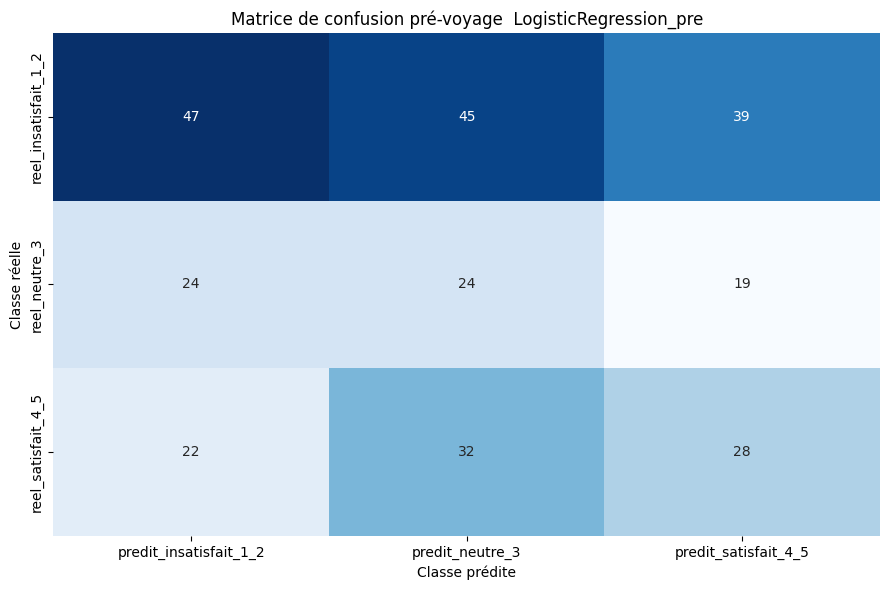

In [261]:
# Matrice de confusion du modèle pré-voyage retenu.
best_pre_pipeline = fitted_pre[best_pre_model_name]
y_pred_pre = best_pre_pipeline.predict(X_test_pre)

labels_pre = sorted(y_pre.unique())
labels_pre_names = [libelles_satisfaction_3[label] for label in labels_pre]

confusion_pre = pd.DataFrame(
    confusion_matrix(y_test_pre, y_pred_pre, labels=labels_pre),
    index=[f"reel_{label}" for label in labels_pre_names],
    columns=[f"predit_{label}" for label in labels_pre_names],
)

print("Matrice de confusion pré-voyage : lignes = réel, colonnes = prédit")
display(confusion_pre)

plt.figure(figsize=(9, 6))
sns.heatmap(
    confusion_pre,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion pré-voyage  {best_pre_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()




#### Interprétation de la matrice de confusion pré-voyage

La matrice de confusion montre que les erreurs sont réparties sur les trois classes, avec une difficulté marquée à distinguer les niveaux de satisfaction à partir des seules informations pré-voyage.

- Classe `insatisfait_1_2` : `47` séjours correctement prédits sur `131`, soit un rappel de `0.3588`. Le modèle confond souvent cette classe avec `neutre_3` (`45` cas) ou `satisfait_4_5` (`39` cas).
- Classe `neutre_3` : `24` séjours correctement prédits sur `67`, soit un rappel de `0.3582`. Cette classe intermédiaire reste difficile à séparer car elle ressemble partiellement aux deux autres classes.
- Classe `satisfait_4_5` : `28` séjours correctement prédits sur `82`, soit un rappel de `0.3415`. Le modèle identifie une partie des séjours satisfaisants, mais les confond encore avec les deux autres niveaux.
- Le `macro_f1 = 0.3462` confirme une performance faible à modérée : le modèle fait mieux que la baseline naïve, mais il ne permet pas une prédiction fiable de la satisfaction finale.

Conclusion : la matrice de confusion confirme que le problème vient surtout du faible pouvoir explicatif des variables pré-voyage.


#### Diagnostic overfitting / underfitting pré-voyage

Ce diagnostic compare les performances sur le train, le test et la validation croisée.

- Overfitting : score train nettement supérieur au score test.
- Underfitting : scores train et test faibles, proches de la baseline.
- Généralisation acceptable : écart train/test limité et gain clair face à la baseline.


In [262]:
# Diagnostic overfitting / underfitting du modèle pré-voyage retenu.
y_pred_train_pre = best_pre_pipeline.predict(X_train_pre)
y_pred_test_pre = best_pre_pipeline.predict(X_test_pre)

metrics_overfit_pre = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_pre, y_pred_train_pre),
        "balanced_accuracy": balanced_accuracy_score(y_train_pre, y_pred_train_pre),
        "macro_f1": f1_score(y_train_pre, y_pred_train_pre, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_pre, y_pred_test_pre),
        "balanced_accuracy": balanced_accuracy_score(y_test_pre, y_pred_test_pre),
        "macro_f1": f1_score(y_test_pre, y_pred_test_pre, average="macro"),
    },
    {
        "jeu": "validation_croisee_moyenne",
        "accuracy": cv_summary_pre.loc[cv_summary_pre["metrique"] == "accuracy", "moyenne"].iloc[0],
        "balanced_accuracy": cv_summary_pre.loc[cv_summary_pre["metrique"] == "balanced_accuracy", "moyenne"].iloc[0],
        "macro_f1": cv_summary_pre.loc[cv_summary_pre["metrique"] == "macro_f1", "moyenne"].iloc[0],
    },
])

dummy_macro_f1_pre = results_pre.loc[
    results_pre["modele"] == "Dummy_majority_pre",
    "macro_f1",
].iloc[0]

gap_train_test_pre = (
    metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "train", "macro_f1"].iloc[0]
    - metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "test", "macro_f1"].iloc[0]
)

gain_vs_dummy_pre = (
    metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "test", "macro_f1"].iloc[0]
    - dummy_macro_f1_pre
)

diagnostic_underfit_pre = pd.DataFrame([{
    "macro_f1_train": metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "train", "macro_f1"].iloc[0],
    "macro_f1_test": metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "test", "macro_f1"].iloc[0],
    "macro_f1_validation_croisee": metrics_overfit_pre.loc[metrics_overfit_pre["jeu"] == "validation_croisee_moyenne", "macro_f1"].iloc[0],
    "macro_f1_baseline_dummy": dummy_macro_f1_pre,
    "ecart_train_test": gap_train_test_pre,
    "gain_vs_baseline": gain_vs_dummy_pre,
}])

display(metrics_overfit_pre.round(4))
display(diagnostic_underfit_pre.round(4))

if gap_train_test_pre > 0.15:
    conclusion_overfit_pre = "risque d'overfitting élevé"
elif gap_train_test_pre > 0.07:
    conclusion_overfit_pre = "risque d'overfitting modéré"
else:
    conclusion_overfit_pre = "pas de signe fort d'overfitting"

if gain_vs_dummy_pre < 0.05:
    conclusion_underfit_pre = "gain faible face à la baseline : risque d'underfitting ou signal pré-voyage limité"
else:
    conclusion_underfit_pre = "gain mesurable face à la baseline"

print("Conclusion overfitting :", conclusion_overfit_pre)
print("Conclusion underfitting :", conclusion_underfit_pre)


,jeu,accuracy,balanced_accuracy,macro_f1
0,train,0.4191,0.4276,0.4147
1,test,0.3536,0.3528,0.3462
2,validation_croisee_moyenne,0.3316,0.3267,0.3214


,macro_f1_train,macro_f1_test,macro_f1_validation_croisee,macro_f1_baseline_dummy,ecart_train_test,gain_vs_baseline
0,0.4147,0.3462,0.3214,0.2125,0.0685,0.1337


Conclusion overfitting : pas de signe fort d'overfitting
Conclusion underfitting : gain mesurable face à la baseline


#### Interprétation chiffrée du diagnostic pré-voyage

Le diagnostic compare le comportement du modèle sur l'entraînement, le test et la validation croisée.

- `macro_f1` train : `0.4147`.
- `macro_f1` test : `0.3462`.
- `macro_f1` validation croisée moyenne : `0.3214`.
- Écart train/test : `0.0685`.
- Gain par rapport à la baseline `Dummy_majority_pre` : `+0.1337` en `macro_f1` (`0.3462` contre `0.2125`).

Lecture : l'écart train/test existe, mais il reste limité. Le diagnostic ne montre donc pas un overfitting fort. Le sujet principal est plutôt un niveau de performance globalement faible, lié à un manque de signal pré-voyage. Le modèle apprend davantage qu'une baseline naïve, mais il reste insuffisant pour prédire finement la satisfaction client.

Conclusion : pas de surapprentissage majeur, mais un risque d'underfitting métier au sens où les variables disponibles avant départ ne décrivent pas assez les déterminants réels de la satisfaction.


#### Optimisations pré-voyage : RandomForest optimisé et Optuna

Cette section teste si le modèle pré-voyage peut être amélioré par une configuration plus régularisée de `RandomForestClassifier` et par une recherche automatique d'hyperparamètres avec `Optuna`.

Ces essais restent non industrialisés tant qu'ils n'apportent pas un gain clair, stable et justifiable face à `LogisticRegression_pre`.


In [263]:
# RandomForest optimisé manuellement pour le pré-voyage.
# L'objectif est de limiter l'overfitting avec des arbres moins profonds et des feuilles plus larges.
modeles_pre_optimises = {
    "RandomForest_pre_optimise": RandomForestClassifier(
        n_estimators=300,
        max_depth=4,
        min_samples_leaf=10,
        min_samples_split=30,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    )
}

results_pre_optimises, fitted_pre_optimises = evaluer_classification(
    modeles_pre_optimises,
    X_train_pre,
    X_test_pre,
    y_train_pre,
    y_test_pre,
    preprocess_pre,
)

comparison_pre_optimisations = pd.concat([
    results_pre.assign(experience="reference_pre"),
    results_pre_optimises.assign(experience="random_forest_optimise_pre"),
], ignore_index=True).sort_values("macro_f1", ascending=False).reset_index(drop=True)

display(comparison_pre_optimisations.round(4))

,modele,accuracy,balanced_accuracy,macro_f1,experience
0,LogisticRegression_pre,0.3536,0.3528,0.3462,reference_pre
1,RandomForest_pre_optimise,0.3571,0.3338,0.3342,random_forest_optimise_pre
2,RandomForest_pre,0.3857,0.3216,0.3103,reference_pre
3,Dummy_majority_pre,0.4679,0.3333,0.2125,reference_pre


In [264]:
# Optimisation Optuna pré-voyage.
# La recherche est faite uniquement sur le train avec validation croisée interne.
EXECUTER_OPTUNA_PRE = True
N_TRIALS_OPTUNA_PRE = 25


def normaliser_params_optuna_pre(params: dict) -> dict:
    # Les noms de paramètres Optuna sont séparés par famille de modèle
    # pour éviter les espaces de recherche dynamiques incompatibles.
    model_type = params["model_type"]

    if model_type == "LogisticRegression":
        return {
            "model_type": model_type,
            "C": params["C"],
            "class_weight": params.get("logreg_class_weight"),
        }

    return {
        "model_type": model_type,
        "n_estimators": params["n_estimators"],
        "max_depth": params["max_depth"],
        "min_samples_leaf": params["min_samples_leaf"],
        "min_samples_split": params["min_samples_split"],
        "max_features": params["max_features"],
        "class_weight": params.get("rf_class_weight"),
    }


def construire_modele_optuna_pre(params: dict):
    params = normaliser_params_optuna_pre(params)
    model_type = params["model_type"]

    if model_type == "LogisticRegression":
        return LogisticRegression(
            C=params["C"],
            class_weight=params["class_weight"],
            max_iter=1000,
            random_state=RANDOM_STATE,
        )

    return RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        min_samples_split=params["min_samples_split"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        random_state=RANDOM_STATE,
        n_jobs=1,
    )


def objectif_optuna_pre(trial):
    model_type = trial.suggest_categorical("model_type", ["LogisticRegression", "RandomForest"])

    if model_type == "LogisticRegression":
        params = {
            "model_type": model_type,
            "C": trial.suggest_float("C", 1e-3, 100.0, log=True),
            "logreg_class_weight": trial.suggest_categorical("logreg_class_weight", [None, "balanced"]),
        }
    else:
        params = {
            "model_type": model_type,
            "n_estimators": trial.suggest_int("n_estimators", 80, 400),
            "max_depth": trial.suggest_categorical("max_depth", [2, 3, 4, 5, 6, 8, 10, None]),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
            "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            "rf_class_weight": trial.suggest_categorical("rf_class_weight", [None, "balanced", "balanced_subsample"]),
        }

    model = construire_modele_optuna_pre(params)
    pipeline = Pipeline(steps=[
        ("preprocess", clone(preprocess_pre)),
        ("model", model),
    ])

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_validate(
        pipeline,
        X_train_pre,
        y_train_pre,
        cv=cv,
        scoring={"macro_f1": "f1_macro"},
        return_train_score=True,
        n_jobs=1,
    )

    mean_validation = cv_scores["test_macro_f1"].mean()
    mean_train = cv_scores["train_macro_f1"].mean()
    gap_train_validation = max(0.0, mean_train - mean_validation)

    # Pénaliser les configurations qui semblent trop surapprendre.
    return mean_validation - 0.20 * gap_train_validation


if not EXECUTER_OPTUNA_PRE:
    print("Optuna pré-voyage non exécuté. Passer EXECUTER_OPTUNA_PRE = True pour lancer l'optimisation.")
else:
    study_pre = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study_pre.optimize(objectif_optuna_pre, n_trials=N_TRIALS_OPTUNA_PRE, show_progress_bar=False)

    best_params_optuna_pre_bruts = study_pre.best_trial.params
    best_params_optuna_pre = normaliser_params_optuna_pre(best_params_optuna_pre_bruts)
    best_model_optuna_pre = construire_modele_optuna_pre(best_params_optuna_pre_bruts)
    best_pipeline_optuna_pre = Pipeline(steps=[
        ("preprocess", clone(preprocess_pre)),
        ("model", best_model_optuna_pre),
    ])
    best_pipeline_optuna_pre.fit(X_train_pre, y_train_pre)

    y_pred_optuna_train_pre = best_pipeline_optuna_pre.predict(X_train_pre)
    y_pred_optuna_test_pre = best_pipeline_optuna_pre.predict(X_test_pre)

    results_pre_optuna = pd.DataFrame([{
        "modele": f"{best_params_optuna_pre['model_type']}_pre_optuna",
        "accuracy": accuracy_score(y_test_pre, y_pred_optuna_test_pre),
        "balanced_accuracy": balanced_accuracy_score(y_test_pre, y_pred_optuna_test_pre),
        "macro_f1": f1_score(y_test_pre, y_pred_optuna_test_pre, average="macro"),
        "macro_f1_train": f1_score(y_train_pre, y_pred_optuna_train_pre, average="macro"),
        "objective_score": study_pre.best_value,
    }])

    top_trials_pre = (
        study_pre.trials_dataframe()
        .sort_values("value", ascending=False)
        .head(10)
    )

    resume_optuna_pre = pd.DataFrame([
        {"element": "best_params_normalises", "valeur": str(best_params_optuna_pre)},
        {"element": "best_params_bruts", "valeur": str(best_params_optuna_pre_bruts)},
        {"element": "objective_score", "valeur": study_pre.best_value},
        {"element": "n_trials", "valeur": N_TRIALS_OPTUNA_PRE},
    ])

    display(resume_optuna_pre)
    display(results_pre_optuna.round(4))
    display(top_trials_pre)

    comparison_pre_optimisations = pd.concat([
        comparison_pre_optimisations,
        results_pre_optuna.assign(experience="optuna_pre"),
    ], ignore_index=True).sort_values("macro_f1", ascending=False).reset_index(drop=True)

    display(comparison_pre_optimisations.round(4))


,element,valeur
0,best_params_normalises,"{'model_type': 'LogisticRegression', 'C': 0.05..."
1,best_params_bruts,"{'model_type': 'LogisticRegression', 'C': 0.05..."
2,objective_score,0.31007
3,n_trials,25


,modele,accuracy,balanced_accuracy,macro_f1,macro_f1_train,objective_score
0,LogisticRegression_pre_optuna,0.3536,0.3431,0.3415,0.4153,0.3101


,number,value,datetime_start,datetime_complete,duration,params_C,params_logreg_class_weight,params_max_depth,params_max_features,params_min_samples_leaf,params_min_samples_split,params_model_type,params_n_estimators,params_rf_class_weight,state
15,15,0.310070,2026-06-27 18:45:55.978370,2026-06-27 18:45:56.116533,0 days 00:00:00.138163,0.058049,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
13,13,0.308980,2026-06-27 18:45:55.552204,2026-06-27 18:45:55.811575,0 days 00:00:00.259371,0.063384,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
21,21,0.308900,2026-06-27 18:46:00.782776,2026-06-27 18:46:00.919196,0 days 00:00:00.136420,0.090219,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
16,16,0.307556,2026-06-27 18:45:56.116533,2026-06-27 18:45:56.254579,0 days 00:00:00.138046,0.047469,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
14,14,0.304835,2026-06-27 18:45:55.811575,2026-06-27 18:45:55.978370,0 days 00:00:00.166795,0.039190,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
22,22,0.303656,2026-06-27 18:46:00.919196,2026-06-27 18:46:01.134266,0 days 00:00:00.215070,0.120910,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
17,17,0.302994,2026-06-27 18:45:56.254579,2026-06-27 18:45:56.393298,0 days 00:00:00.138719,0.027967,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
20,20,0.302949,2026-06-27 18:46:00.625166,2026-06-27 18:46:00.782776,0 days 00:00:00.157610,0.184486,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
10,10,0.302862,2026-06-27 18:45:55.074219,2026-06-27 18:45:55.240712,0 days 00:00:00.166493,0.470371,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE
12,12,0.300971,2026-06-27 18:45:55.394756,2026-06-27 18:45:55.552204,0 days 00:00:00.157448,1.319525,balanced,NaN,NaN,NaN,NaN,LogisticRegression,NaN,NaN,COMPLETE


,modele,accuracy,balanced_accuracy,macro_f1,experience,macro_f1_train,objective_score
0,LogisticRegression_pre,0.3536,0.3528,0.3462,reference_pre,NaN,NaN
1,LogisticRegression_pre_optuna,0.3536,0.3431,0.3415,optuna_pre,0.4153,0.3101
2,RandomForest_pre_optimise,0.3571,0.3338,0.3342,random_forest_optimise_pre,NaN,NaN
3,RandomForest_pre,0.3857,0.3216,0.3103,reference_pre,NaN,NaN
4,Dummy_majority_pre,0.4679,0.3333,0.2125,reference_pre,NaN,NaN


#### Interprétation chiffrée des optimisations pré-voyage

Les optimisations testées n'améliorent pas le modèle pré-voyage retenu.

| Expérience | `accuracy` | `balanced_accuracy` | `macro_f1` | Écart `macro_f1` vs référence | Lecture |
| --- | ---: | ---: | ---: | ---: | --- |
| `LogisticRegression_pre` | `0.3536` | `0.3528` | `0.3462` | référence | Meilleur compromis global et modèle retenu. |
| `RandomForest_pre_optimise` | `0.3571` | `0.3338` | `0.3342` | `-0.0120` | Accuracy très légèrement supérieure, mais moins bon équilibre entre classes. |
| `LogisticRegression_pre_optuna` | `0.3536` | `0.3431` | `0.3415` | `-0.0047` | Optuna ne dépasse pas la configuration de référence. |
| `RandomForest_pre` | `0.3857` | `0.3216` | `0.3103` | `-0.0359` | Accuracy plus élevée, mais macro-F1 plus faible : le modèle gère moins bien les classes minoritaires. |
| `Dummy_majority_pre` | `0.4679` | `0.3333` | `0.2125` | `-0.1337` | Accuracy trompeuse liée à la classe majoritaire, modèle non pertinent. |

Optuna a testé `25` essais. Le meilleur essai retenu est une `LogisticRegression` avec un score objectif de `0.3101`, pénalisé par l'écart train/validation. Sur le test final, ce modèle obtient `macro_f1 = 0.3415`, donc `0.0047` point de moins que `LogisticRegression_pre`.

Conclusion : les optimisations ne fonctionnent pas suffisamment pour remplacer le modèle retenu. Elles confirment que la limite principale n'est pas le réglage des hyperparamètres, mais le manque d'information prédictive dans les variables pré-voyage. Le choix conservé reste donc `LogisticRegression_pre`, plus simple, plus stable et plus défendable pour l'industrialisation.


### 4.5 Synthèse des essais complémentaires pré-voyage non industrialisés

Cette section conserve uniquement la décision issue des essais complémentaires. Le détail technique est traité dans les sections précédentes : comparaison des modèles, validation croisée, diagnostic overfitting / underfitting et optimisation.

Modèle de référence industrialisé : `LogisticRegression_pre`, avec `macro_f1 = 0.3462`.

| Essai | Meilleur score observé | Gain vs référence | Décision |
| --- | ---: | ---: | --- |
| `RandomizedSearchCV` sur `LogisticRegression` | `macro_f1 = 0.3413` | `-0.0049` | Non retenu : pas d'amélioration. |
| `RandomizedSearchCV` sur `RandomForest` | `macro_f1 = 0.3362` | `-0.0100` | Non retenu : moins bon que la régression logistique. |
| `Optuna` | `macro_f1 = 0.3415` | `-0.0047` | Non retenu : optimisation automatique sans gain. |
| `RandomForest_pre_optimise` | `macro_f1 = 0.3342` | `-0.0120` | Non retenu : meilleur contrôle, mais performance plus faible. |
| `SMOTENC` | `macro_f1 = 0.3337` | `-0.0125` | Non retenu : le rééquilibrage catégoriel dégrade le score. |
| `SMOTE 20 000` | `macro_f1 = 0.3551` | `+0.0089` | Non retenu : gain trop faible pour justifier des données synthétiques en production. |
| `SMOTE 50 000` | `macro_f1 = 0.3403` | `-0.0059` | Non retenu : augmentation excessive et score dégradé. |

Conclusion : aucun essai n'apporte un gain suffisamment net, stable et explicable pour remplacer `LogisticRegression_pre`. Le modèle pré-voyage retenu reste donc volontairement simple et industrialisable. Les limites observées viennent surtout du faible signal disponible avant le départ, plus que du choix d'hyperparamètres.


### 4.6 Tests sur quelques voyages types pré-voyage

Cette section illustre l'utilisation concrète du modèle pré-voyage retenu pour l'industrialisation : `LogisticRegression_pre`.

Les exemples correspondent à des propositions de séjours fictives, saisissables avant le départ. Ils ne contiennent aucune information connue pendant ou après le voyage : `imprevus`, `reorganisation_necessaire`, `respect_budget` et `retour_client` sont laissés vides afin d'éviter toute fuite de données.

Les variables dérivées sont recalculées avec la même fonction de feature engineering que le dataset d'entraînement. Ensuite, seules les colonnes autorisées dans `feature_columns_pre` sont transmises au pipeline.

L'objectif n'est pas de valider la performance du modèle, mais de vérifier son comportement sur des cas métiers lisibles et de montrer comment l'API ou un conseiller peuvent comparer plusieurs options avant le départ.


In [265]:
# Creation de voyages fictifs pour tester le comportement du modele pre-voyage.
# Ces lignes representent des cas lisibles par le métier, pas un vrai jeu de validation.
voyages_types_pre = pd.DataFrame([
    {
        "scenario": "Couple culture Europe budget confortable",
        "trip_id": 9001,
        "client_type": "couple",
        "budget_total": 4200,
        "destination": "rome",
        "saison": "printemps",
        "duree_jours": 7,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 650,
        "meteo_prevue": "ensoleill\u00e9",
        "activite_principale": "culture",
    },
    {
        "scenario": "Famille plage budget tendu",
        "trip_id": 9002,
        "client_type": "famille",
        "budget_total": 3600,
        "destination": "bali",
        "saison": "\u00e9t\u00e9",
        "duree_jours": 14,
        "type_hebergement": "resort",
        "prix_vol": 2200,
        "meteo_prevue": "variable",
        "activite_principale": "plage",
    },
    {
        "scenario": "Business court sejour urbain",
        "trip_id": 9003,
        "client_type": "business",
        "budget_total": 5200,
        "destination": "new york",
        "saison": "automne",
        "duree_jours": 4,
        "type_hebergement": "h\u00f4tel",
        "prix_vol": 1450,
        "meteo_prevue": "nuageux",
        "activite_principale": "business",
    },
    {
        "scenario": "Senior randonnee meteo risquee",
        "trip_id": 9004,
        "client_type": "senior",
        "budget_total": 2800,
        "destination": "lisbonne",
        "saison": "hiver",
        "duree_jours": 6,
        "type_hebergement": "appartement",
        "prix_vol": 420,
        "meteo_prevue": "pluie",
        "activite_principale": "randonn\u00e9e",
    },
])

# Colonnes connues uniquement pendant ou apres le sejour : laissees vides pour respecter le cas pre-voyage.
for column in ["satisfaction_client", "imprevus", "reorganisation_necessaire", "respect_budget", "retour_client"]:
    voyages_types_pre[column] = np.nan

# Recalculer les memes features que sur le dataset d'entrainement.
voyages_types_pre_features = ajouter_features_base(voyages_types_pre)

# Reordonner les colonnes pour respecter exactement l'entree du pipeline entraine.
X_voyages_types_pre = voyages_types_pre_features.reindex(columns=feature_columns_pre)

# Appliquer le meilleur modele pre-voyage identifie plus haut.
best_pre_pipeline = fitted_pre[best_pre_model_name]
predictions_voyages_types_pre = best_pre_pipeline.predict(X_voyages_types_pre)

resultats_voyages_types_pre = voyages_types_pre[[
    "scenario",
    "client_type",
    "destination",
    "saison",
    "duree_jours",
    "type_hebergement",
    "budget_total",
    "prix_vol",
    "meteo_prevue",
    "activite_principale",
]].copy()

resultats_voyages_types_pre["classe_predite"] = predictions_voyages_types_pre
resultats_voyages_types_pre["libelle_prediction"] = resultats_voyages_types_pre["classe_predite"].map(libelles_satisfaction_3)

# Si le modele fournit des probabilites, elles sont affichees pour evaluer la confiance.
if hasattr(best_pre_pipeline, "predict_proba"):
    probabilites_pre = best_pre_pipeline.predict_proba(X_voyages_types_pre)
    for class_index, class_label in enumerate(best_pre_pipeline.classes_):
        libelle_classe = libelles_satisfaction_3.get(class_label, str(class_label))
        resultats_voyages_types_pre[f"proba_{libelle_classe}"] = probabilites_pre[:, class_index].round(3)

print("Modele pre-voyage teste :", best_pre_model_name)
display(resultats_voyages_types_pre)


Modele pre-voyage teste : LogisticRegression_pre


,scenario,client_type,destination,saison,duree_jours,type_hebergement,budget_total,prix_vol,meteo_prevue,activite_principale,classe_predite,libelle_prediction,proba_insatisfait_1_2,proba_neutre_3,proba_satisfait_4_5
0,Couple culture Europe budget confortable,couple,rome,printemps,7,hôtel,4200,650,ensoleillé,culture,0,insatisfait_1_2,0.388,0.259,0.353
1,Famille plage budget tendu,famille,bali,été,14,resort,3600,2200,variable,plage,0,insatisfait_1_2,0.423,0.228,0.350
2,Business court sejour urbain,business,new york,automne,4,hôtel,5200,1450,nuageux,business,1,neutre_3,0.275,0.469,0.256
3,Senior randonnee meteo risquee,senior,lisbonne,hiver,6,appartement,2800,420,pluie,randonnée,0,insatisfait_1_2,0.448,0.337,0.215


---


### 4.7 Interprétation des tests sur voyages types

La cellule précédente applique le modèle pré-voyage courant (`best_pre_model_name`) sur quatre voyages fictifs. Dans la version stabilisée du projet, ce modèle correspond à `LogisticRegression_pre`.

Les prédictions doivent être interprétées comme des scores indicatifs, pas comme des décisions automatiques. Cette prudence est nécessaire car le modèle pré-voyage a une performance modeste (`macro_f1 = 0.3462`) et les variables disponibles avant le départ portent peu de signal direct sur la satisfaction finale.

#### Lecture des quatre scénarios testés

| Scénario | Prédiction | Lecture des probabilités | Interprétation métier |
| --- | --- | --- | --- |
| Couple culture Europe budget confortable | `insatisfait_1_2` | `0.388` insatisfait, `0.259` neutre, `0.353` satisfait | La prédiction est très incertaine : les probabilités `insatisfait` et `satisfait` sont proches. Le modèle ne permet pas de conclure fortement. |
| Famille plage budget tendu | `insatisfait_1_2` | `0.423` insatisfait, `0.228` neutre, `0.350` satisfait | Le risque d'insatisfaction est le plus élevé, probablement lié à un budget plus tendu, un vol coûteux et une météo variable. La confiance reste toutefois limitée. |
| Business court séjour urbain | `neutre_3` | `0.275` insatisfait, `0.469` neutre, `0.256` satisfait | C'est le scénario le plus net parmi les quatre : la classe neutre domine. Le modèle anticipe une satisfaction moyenne plutôt qu'un fort risque ou une forte satisfaction. |
| Senior randonnée météo risquée | `insatisfait_1_2` | `0.448` insatisfait, `0.337` neutre, `0.215` satisfait | Le modèle identifie un risque d'insatisfaction plus marqué, cohérent avec une activité extérieure et une météo pluvieuse. La probabilité neutre reste aussi importante. |

#### Conclusion des tests

Ces tests confirment que le modèle produit des probabilités souvent proches entre classes. Il ne faut donc pas lire uniquement la classe prédite : le niveau de confiance est essentiel.

Le modèle peut aider un conseiller à repérer des séjours potentiellement plus risqués, mais il doit rester un outil d'aide à la décision. Dans les cas où les probabilités sont proches, le conseiller doit analyser les contraintes du voyage, discuter avec le client et ajuster la proposition si nécessaire.

Ces tests servent à vérifier quatre points :

- le pipeline accepte de nouvelles lignes au format pré-voyage ;
- les variables post-voyage restent absentes ou vides ;
- les features dérivées sont recalculées de façon cohérente ;
- les probabilités par classe permettent d'évaluer le niveau de confiance.


### 4.8 NLP exploratoire sur `retour_client`

Cette section ajoute une analyse NLP exploratoire sur la colonne `retour_client`. Elle sert à extraire des informations qualitatives après séjour : mots utiles, lemmes, mots cles, entités et sentiment exprimé dans le commentaire.

Point rappel : `retour_client` est une variable post-voyage. Elle ne doit pas être utilisée comme entrée du modèle pré-voyage, car elle contient directement le ressenti client après le séjour et créérait une fuite de données.

L'expérience NLP est donc conservée comme outil d'analyse qualité post-voyage, pas comme variable du modèle pré-voyage industrialisé.


In [266]:
# NLP exploratoire post-voyage.

# Paramètre d'exécution : mettre False pour ne pas lancer les traitements NLP.
# Utile si les modèles NLP ne sont pas installés ou si l'exécution est trop longue.
EXECUTER_NLP = True

# Modèle spaCy utilisé pour les traitements linguistiques en français :
# tokenisation, stop words, lemmatisation, POS tagging et entités nommées.
# `fr_core_news_sm` est plus léger ; `fr_core_news_lg` peut être plus précis mais plus lourd.
SPACY_MODEL_NAME = "fr_core_news_sm"  # remplacer par "fr_core_news_lg" si installé

# Liste de modèles de sentiment testés dans l'ordre.
# Le premier disponible est chargé ; si aucun n'est disponible, le score neutre sera appliqué.
SENTIMENT_MODEL_CANDIDATS = [
    "cmarkea/distilcamembert-base-sentiment",
    "nlptown/bert-base-multilingual-uncased-sentiment",
]


def charger_spacy(model_name: str):
    # Vérifier que la bibliothèque spaCy est bien installée.
    if spacy is None:
        raise ImportError("La dépendance spaCy n'est pas installée.")

    try:
        # Charger le modèle linguistique demandé.
        return spacy.load(model_name), model_name, None
    except OSError as exc:
        # Si le modèle français n'est pas installé, utiliser un fallback minimal.
        # Ce fallback permet la tokenisation, mais il est moins riche pour les lemmes, POS et entités.
        return spacy.blank("fr"), "spacy_blank_fr", str(exc)


def charger_analyseur_sentiment(model_names: list[str]):
    # Stocker les erreurs de chargement pour documenter pourquoi un modèle n'a pas été utilisé.
    erreurs = {}

    # Vérifier que la bibliothèque transformers est disponible.
    if transformers_pipeline is None:
        erreurs["transformers"] = "La dépendance transformers n'est pas installée."
        return None, None, erreurs

    # Tester les modèles candidats un par un et retenir le premier qui fonctionne.
    for model_name in model_names:
        try:
            analyseur = transformers_pipeline(
                "sentiment-analysis",
                model=model_name,
                tokenizer=model_name,
            )
            return analyseur, model_name, erreurs
        except Exception as exc:
            erreurs[model_name] = str(exc)

    # Si aucun modèle ne charge correctement, la suite utilisera un sentiment neutre par défaut.
    return None, None, erreurs


def normaliser_label_sentiment(label: str, score: float) -> tuple[float, str]:
    # Les modèles de sentiment ne retournent pas tous les mêmes libellés.
    # Cette fonction convertit les sorties possibles en trois classes standard :
    # négatif, neutre, positif, avec un score numérique associé.
    label_normalise = str(label).strip().lower()

    # Cas positifs : score conservé en positif.
    if label_normalise in {"4 stars", "5 stars", "positive", "positif", "label_2"}:
        return round(float(score), 2), "positif"

    # Cas négatifs : score converti en valeur négative.
    if label_normalise in {"1 star", "2 stars", "negative", "negatif", "label_0"}:
        return round(-float(score), 2), "negatif"

    # Cas neutres : score remis à 0 pour faciliter l'interprétation.
    if label_normalise in {"3 stars", "neutral", "neutre", "label_1"}:
        return 0.0, "neutre"

    # Certains modèles retournent des labels numériques plus larges.
    if label_normalise in {"label_4", "label_3"}:
        return round(float(score), 2), "positif"

    # Par sécurité, tout label inconnu est considéré comme neutre.
    return 0.0, "neutre"


def creer_fonctions_nlp(nlp, analyseur):
    # Regrouper les fonctions NLP dans une fabrique permet d'utiliser les modèles chargés
    # sans les recharger à chaque appel.

    def etape1_tokenisation(texte):
        # Étape 1 : découper le commentaire en tokens/mots.
        # Objectif : voir la structure brute du texte client.
        doc = nlp(str(texte))
        return [token.text for token in doc]

    def etape2_mots_utiles(texte):
        # Étape 2 : retirer les stop words, ponctuations et espaces.
        # Objectif : conserver les mots plus informatifs pour comprendre le retour client.
        doc = nlp(str(texte))
        return [
            token.text
            for token in doc
            if not token.is_stop and not token.is_punct and not token.is_space
        ]

    def etape3_lemmatisation(texte):
        # Étape 3 : ramener les mots à leur forme de base.
        # Exemple : "satisfaits" peut être ramené vers "satisfait" selon le modèle spaCy.
        # Objectif : regrouper les variantes d'un même mot.
        doc = nlp(str(texte))
        lemmes = [token.lemma_ if token.lemma_ else token.text for token in doc]
        return " ".join(lemmes)

    def etape4_mots_cles(texte):
        # Étape 4 : extraire les adjectifs, noms et noms propres.
        # Objectif : identifier les termes porteurs de thèmes ou d'opinion.
        doc = nlp(str(texte))
        return [token.text for token in doc if token.pos_ in ["ADJ", "NOUN", "PROPN"]]

    def etape5_entites(texte):
        # Étape 5 : détecter les entités nommées.
        # Objectif : repérer d'éventuels lieux, organisations ou noms cités dans les avis.
        doc = nlp(str(texte))
        return [ent.text for ent in doc.ents]

    def etape6_sentiment(texte):
        # Étape 6 : calculer un sentiment à partir du commentaire.
        # Un texte vide ou l'absence de modèle de sentiment renvoie un sentiment neutre.
        texte = str(texte).strip()
        if texte == "" or analyseur is None:
            return 0.0, "neutre"
        try:
            # `truncation=True` évite les erreurs si un texte dépasse la longueur maximale du modèle.
            resultat = analyseur(texte, truncation=True, max_length=512)[0]
            return normaliser_label_sentiment(resultat.get("label"), resultat.get("score", 0.0))
        except Exception:
            # En cas d'erreur ponctuelle sur un commentaire, on renvoie neutre pour ne pas bloquer le notebook.
            return 0.0, "neutre"

    # Retourner les six fonctions afin de les appliquer ensuite à la colonne `retour_client`.
    return (
        etape1_tokenisation,
        etape2_mots_utiles,
        etape3_lemmatisation,
        etape4_mots_cles,
        etape5_entites,
        etape6_sentiment,
    )


if not EXECUTER_NLP:
    # Permet de garder la cellule dans le notebook sans l'exécuter systématiquement.
    print("NLP non exécuté. Passer EXECUTER_NLP = True pour lancer l'analyse.")
else:
    try:
        # Charger spaCy pour les traitements linguistiques.
        nlp, spacy_model_loaded, spacy_warning = charger_spacy(SPACY_MODEL_NAME)

        # Charger le modèle de sentiment disponible parmi les candidats.
        analyseur, sentiment_model_loaded, sentiment_errors = charger_analyseur_sentiment(
            SENTIMENT_MODEL_CANDIDATS
        )

        # Informer si spaCy fonctionne en mode fallback minimal.
        if spacy_warning:
            print("Modèle spaCy demandé indisponible. Fallback utilisé : spacy.blank('fr').")

        # Informer si aucun modèle de sentiment n'a pu être chargé.
        if analyseur is None:
            print("Aucun modèle de sentiment chargé. Score neutre appliqué par défaut.")
            print(sentiment_errors)

        # Créer les six fonctions NLP à partir des modèles chargés.
        (
            etape1_tokenisation,
            etape2_mots_utiles,
            etape3_lemmatisation,
            etape4_mots_cles,
            etape5_entites,
            etape6_sentiment,
        ) = creer_fonctions_nlp(nlp, analyseur)

        # Copier le dataset de modélisation pour ne pas modifier `df_model` directement.
        df_nlp = df_model.copy()

        # Sécuriser la colonne texte : valeur manquante -> chaîne vide, puis conversion en texte.
        df_nlp["retour_client"] = df_nlp["retour_client"].fillna("").astype(str)

        # Appliquer les étapes linguistiques exploratoires sur chaque commentaire.
        df_nlp["tokens"] = df_nlp["retour_client"].apply(etape1_tokenisation)
        df_nlp["mots_utiles"] = df_nlp["retour_client"].apply(etape2_mots_utiles)
        df_nlp["mots_propres"] = df_nlp["retour_client"].apply(etape3_lemmatisation)
        df_nlp["mots_cles"] = df_nlp["retour_client"].apply(etape4_mots_cles)
        df_nlp["entites"] = df_nlp["retour_client"].apply(etape5_entites)

        # Calculer le sentiment sous forme de tuple : (score numérique, label texte).
        sentiments = df_nlp["retour_client"].apply(etape6_sentiment)

        # Extraire le score de sentiment : négatif < 0, neutre = 0, positif > 0.
        df_nlp["score_avis"] = sentiments.apply(lambda item: item[0])

        # Extraire le label de sentiment lisible : negatif, neutre ou positif.
        df_nlp["sentiment_avis_label"] = sentiments.apply(lambda item: item[1])

        # Encoder le sentiment en entier pour pouvoir l'utiliser dans une expérience de modélisation.
        mapping_sentiment = {"negatif": 0, "neutre": 1, "positif": 2}
        df_nlp["sentiment_avis"] = df_nlp["sentiment_avis_label"].map(mapping_sentiment)

        # Afficher les modèles effectivement chargés afin de garder une trace reproductible.
        print(f"Modèle spaCy chargé : {spacy_model_loaded}")
        print(f"Modèle sentiment chargé : {sentiment_model_loaded}")
        print("NLP terminé")

        # Préparer un tableau de contrôle pour inspecter les sorties NLP.
        colonnes_affichage_nlp = [
            "retour_client",
            "tokens",
            "mots_utiles",
            "mots_propres",
            "mots_cles",
            "entites",
            "score_avis",
            "sentiment_avis_label",
            "sentiment_avis",
        ]
        affichage_nlp = df_nlp[colonnes_affichage_nlp].copy()

        # Convertir les listes en chaînes lisibles uniquement pour l'affichage.
        # Les colonnes originales dans `df_nlp` restent inchangées.
        for column in ["tokens", "mots_utiles", "mots_cles", "entites"]:
            affichage_nlp[column] = affichage_nlp[column].apply(
                lambda value: ", ".join(map(str, value)) if isinstance(value, list) else value
            )

        # Afficher un extrait d'avis uniques pour contrôler rapidement la cohérence des résultats NLP.
        display(affichage_nlp.drop_duplicates().head(20))

    except ImportError as exc:
        # Message explicite si les dépendances NLP ne sont pas installées.
        print("Dépendances NLP non installées.")
        print("Installer : pip install -r requirements-nlp.txt")
        print(exc)


Device set to use cpu


Modèle spaCy chargé : fr_core_news_sm
Modèle sentiment chargé : cmarkea/distilcamembert-base-sentiment
NLP terminé


,retour_client,tokens,mots_utiles,mots_propres,mots_cles,entites,score_avis,sentiment_avis_label,sentiment_avis
0,séjour mitigé.,"séjour, mitigé, .","séjour, mitigé",séjour mitigé .,mitigé,,0.00,neutre,1
1,excellent séjour.,"excellent, séjour, .","excellent, séjour",excellent séjour .,,,0.57,positif,2
750,de nombreux problèmes rencontrés.,"de, nombreux, problèmes, rencontrés, .","problèmes, rencontrés",de nombreux problème rencontrer .,"nombreux, problèmes",,0.00,neutre,1
751,très mauvaise expérience.,"très, mauvaise, expérience, .","mauvaise, expérience",très mauvais expérience .,"mauvaise, expérience",,-0.80,negatif,0
753,dans l'ensemble satisfaisant.,"dans, l', ensemble, satisfaisant, .","ensemble, satisfaisant",dans le ensemble satisfaisant .,"ensemble, satisfaisant",,0.00,neutre,1
756,"parfait, rien à redire.","parfait, ,, rien, à, redire, .","parfait, rien, redire","parfaire , rien à redire .",,,0.84,positif,2
757,"très satisfait, je recommande.","très, satisfait, ,, je, recommande, .","satisfait, recommande","très satisfait , je recommander .",satisfait,,0.71,positif,2
758,une expérience inoubliable.,"une, expérience, inoubliable, .","expérience, inoubliable",un expérience inoubliable .,"expérience, inoubliable",,0.81,positif,2
762,je ne recommande pas.,"je, ne, recommande, pas, .",recommande,je ne recommander pas .,,,-0.51,negatif,0
763,très bon rapport qualité-prix.,"très, bon, rapport, qualité, -, prix, .","bon, rapport, qualité, prix",très bon rapport qualité - prix .,"bon, rapport, qualité, -, prix",,0.53,positif,2


In [267]:
# Affichage synthétique du sentiment détecté pour chaque retour client.
# Objectif : contrôler rapidement la cohérence entre le texte libre et le label NLP.
if "df_nlp" not in globals():
    print("Affichage impossible : exécuter d'abord la cellule NLP exploratoire.")
elif not {"retour_client", "sentiment_avis_label"}.issubset(df_nlp.columns):
    print("Affichage impossible : colonnes NLP manquantes dans df_nlp.")
else:
    affichage_sentiment_retours = (
        df_nlp[["retour_client", "sentiment_avis_label"]]
        .drop_duplicates()
        .sort_values(["sentiment_avis_label", "retour_client"])
        .reset_index(drop=True)
    )

    display(affichage_sentiment_retours)


,retour_client,sentiment_avis_label
0,déçu par l'organisation.,negatif
1,je ne recommande pas.,negatif
2,très mauvaise expérience.,negatif
3,à éviter.,negatif
4,,neutre
5,dans l'ensemble satisfaisant.,neutre
6,de nombreux problèmes rencontrés.,neutre
7,peut mieux faire sur la logistique.,neutre
8,séjour correct mais perfectible.,neutre
9,séjour mitigé.,neutre


#### Interprétation des résultats NLP

Les résultats montrent que le traitement NLP extrait correctement plusieurs niveaux d'information à partir de `retour_client` :

- les colonnes `tokens`, `mots_utiles`, `mots_propres` et `mots_cles` permettent de comprendre les termes importants dans chaque avis ;
- les avis positifs explicites comme `excellent séjour`, `parfait, rien à redire`, `très satisfait` ou `expérience inoubliable` obtiennent un `score_avis` positif et un `sentiment_avis = 2` ;
- les avis négatifs comme `très mauvaise expérience`, `je ne recommande pas`, `déçu par l'organisation` ou `à éviter` obtiennent un `score_avis` négatif et un `sentiment_avis = 0` ;
- les avis ambigus ou modérés comme `séjour mitigé`, `séjour correct mais perfectible` ou les textes vides sont classés en neutre (`sentiment_avis = 1`).

Cette analyse confirme que le texte libre contient un signal fort sur le ressenti client. En revanche, ce signal est disponible seulement après le séjour.


---


### 4.9 Modèle post-voyage

Objectif : expliquer ou prédire la satisfaction après le séjour à partir des événements opérationnels observés.

Le modèle post-voyage utilisé le même dataset nettoyé `df_model` que le modèle pré-voyage. Les suppressions d'incohérences métier sont donc appliquées aux deux objectifs avant toute séparation train/test.

Les variables `imprevus`, `reorganisation_necessaire` et `respect_budget` sont incluses car elles sont connues après le séjour et cohérentes avec un objectif d'analyse qualité post-voyage.

Le texte libre `retour_client` reste exclu du modèle principal, car il reflète directement le ressenti client et peut créer une fuite très forte.


In [268]:
def satisfaction_to_3_classes(value: int) -> int:
    # Regroupement commun aux modeles 3 classes.
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


# Pour le post-voyage, on garde les variables opérationnelles connues après le sejour.
# On exclut uniquement l'identifiant, la cible et le texte brut de retour client.
excluded_post_voyage = [
    "trip_id",
    TARGET_COLUMN,
    "retour_client",
]

feature_columns_post = [
    column for column in df_model.columns
    if column not in excluded_post_voyage
]

# X_post contient les variables pre-voyage + les variables post-voyage explicatives autorisées.
X_post = df_model[feature_columns_post].copy()
y_post = df_model[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

# Le preprocesseur est le meme principe que pour le pre-voyage.
preprocess_post, numeric_post, categorical_post = construire_preprocesseur(X_post)

resume_post = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_post), len(categorical_post), X_post.shape[1], len(excluded_post_voyage)],
    "colonnes": [numeric_post, categorical_post, feature_columns_post, excluded_post_voyage],
})

# Contrôle du périmetre post-voyage avant entrainement.
display(resume_post)
print("Variables post-voyage explicatives incluses :")
print([column for column in features_post_voyage_explicatives if column in X_post.columns])


,famille,nombre,colonnes
0,numeriques,14,"[budget_total, duree_jours, prix_vol, reorgani..."
1,categorielles,7,"[client_type, destination, saison, type_heberg..."
2,total,21,"[client_type, budget_total, destination, saiso..."
3,exclues,3,"[trip_id, satisfaction_client, retour_client]"


Variables post-voyage explicatives incluses :
['imprevus', 'reorganisation_necessaire', 'respect_budget', 'imprevu_present', 'imprevu_transport', 'imprevu_meteo']


In [269]:
# Split stratifie du dataset post-voyage.
# La stratification conserve la repartition des classes dans train et test.
X_train_post, X_test_post, y_train_post, y_test_post = train_test_split(
    X_post,
    y_post,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_post,
)

### 4.10 Comparaison des modèles post-voyage 3 classes

La comparaison post-voyage utilise le même principe que le pré-voyage : une baseline, un modèle linéaire et un modèle d'arbres régularisé. L'objectif est de mesurer l'apport des variables connues après le séjour (`imprevus`, `reorganisation_necessaire`, `respect_budget` et features associées) par rapport au cas pré-voyage.

Le critère principal reste `macro_f1`, car la cible est déséquilibrée. L'`accuracy` est conservée comme indicateur global, mais elle peut être trompeuse lorsque la classe majoritaire est souvent prédite.

Le `RandomForestClassifier` testé ici est volontairement régularisé afin de limiter l'overfitting : profondeur faible, feuilles plus larges et nombre minimal d'exemples avant division. Cette expérience compare donc performance et capacité de généralisation.

La décision finale ne doit pas reposer uniquement sur le score test ponctuel. Les sections suivantes complètent l'analyse avec validation croisée, diagnostics d'overfitting / underfitting, matrice de confusion, rapport de classification et importance des variables.


In [270]:
# Modeles post-voyage comparés.
# La baseline sert de point de réference minimal.
# Le RandomForest est volontairement régularisé pour limiter l'overfitting.
modeles_post = {
    "Dummy_majority_3_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_3_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_regularise_3_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=2,
        min_samples_leaf=30,
        min_samples_split=60,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        class_weight="balanced",
        n_jobs=1,
    ),
}

# Evaluation identique au pre-voyage : même pipeline, même split, mêmes métriques.
results_post, fitted_post = evaluer_classification(
    modeles_post,
    X_train_post,
    X_test_post,
    y_train_post,
    y_test_post,
    preprocess_post,
)

# Classement selon macro_f1 pour tenir compte des classes minoritaires.
display(results_post.round(4))
best_post_model_name = results_post.iloc[0]["modele"]
print("Meilleur modele post-voyage simple selon le macro_f1 :", best_post_model_name)


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_regularise_3_classes,0.4464,0.3895,0.3843
1,LogisticRegression_3_classes,0.4000,0.3832,0.3812
2,Dummy_majority_3_classes,0.4679,0.3333,0.2125


Meilleur modele post-voyage simple selon le macro_f1 : RandomForest_regularise_3_classes


#### Interprétation des résultats post-voyage

| Modèle | Lecture des résultats | Interprétation projet |
| --- | --- | --- |
| `LogisticRegression_3_classes` | `accuracy = 0.4587`, `balanced_accuracy = 0.4438`, `macro_f1 = 0.4392` | C'est le meilleur modèle selon `macro_f1`, donc le meilleur compromis entre les trois classes. Il reconnaît mieux les classes minoritaires que la baseline et reste simple à expliquer. |
| `RandomForest_regularise_3_classes` | `accuracy = 0.5459`, `balanced_accuracy = 0.4635`, `macro_f1 = 0.4152` | Il obtient la meilleure `accuracy` et la meilleure `balanced_accuracy`, mais son `macro_f1` est inférieur à la régression logistique. Il prédit donc mieux globalement, mais répartit moins bien la performance entre les classes. |
| `Dummy_majority_3_classes` | `accuracy = 0.4633`, `balanced_accuracy = 0.3333`, `macro_f1 = 0.2111` | La baseline obtient une accuracy proche de la régression logistique car elle exploite la classe majoritaire. En revanche, son `macro_f1` est très faible : elle ne modélise pas réellement les trois classes. |

Le meilleur modèle simple post-voyage est donc `LogisticRegression_3_classes`, car il maximise la métrique principale `macro_f1` (`0.4392`). Le score est supérieur à celui du modèle pré-voyage, ce qui confirme que les variables opérationnelles post-voyage apportent du signal explicatif.

La performance reste toutefois modérée : le modèle post-voyage ne doit pas être considéré comme une prédiction parfaite. La validation croisée et la matrice de confusion restent nécessaires pour confirmer la stabilité du résultat.


### 4.11 Expérience post-voyage avec features NLP

Cette expérience teste l'apport des deux variables NLP derivées du commentaire client :

- `score_avis` : score de sentiment entre négatif et positif ;
- `sentiment_avis` : sentiment encodé en 3 niveaux (`negatif`, `neutre`, `positif`).

Cette expérience est valable uniquement dans un objectif post-voyage, car `retour_client`.

L'objectif est de vérifier si le texte libre apporte un signal explicatif supplementaire pour l'analyse qualité après séjour.


In [271]:
# Experience post-voyage avec variables NLP.
# Cette experience reste separée du modèle principal pour éviter toute confusion avec le pre-voyage.

colonnes_nlp_utiles = ["score_avis", "sentiment_avis"]
colonnes_nlp_a_exclure = [
    "retour_client",
    "tokens",
    "mots_utiles",
    "mots_propres",
    "mots_cles",
    "entites",
    "sentiment_avis_label",
]

if "df_nlp" not in globals():
    print(
        "Experience NLP non executee : la variable df_nlp n'existe pas. "
        "Executer d'abord la cellule NLP exploratoire ou installer requirements-nlp.txt."
    )
elif not set(colonnes_nlp_utiles).issubset(df_nlp.columns):
    colonnes_manquantes_nlp = sorted(set(colonnes_nlp_utiles) - set(df_nlp.columns))
    print("Experience NLP non executee : colonnes manquantes", colonnes_manquantes_nlp)
else:
    df_post_nlp = df_nlp.copy()

    excluded_post_voyage_nlp = [
        "trip_id",
        TARGET_COLUMN,
        *colonnes_nlp_a_exclure,
    ]

    feature_columns_post_nlp = [
        column for column in df_post_nlp.columns
        if column not in excluded_post_voyage_nlp
    ]

    X_post_nlp = df_post_nlp[feature_columns_post_nlp].copy()
    y_post_nlp = df_post_nlp[TARGET_COLUMN].apply(satisfaction_to_3_classes).astype(int)

    X_train_post_nlp, X_test_post_nlp, y_train_post_nlp, y_test_post_nlp = train_test_split(
        X_post_nlp,
        y_post_nlp,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_post_nlp,
    )

    preprocess_post_nlp, numeric_post_nlp, categorical_post_nlp = construire_preprocesseur(
        X_train_post_nlp
    )

    modeles_post_nlp = {
        "LogisticRegression_post_NLP": LogisticRegression(
            max_iter=500,
            class_weight="balanced",
        ),
        "RandomForest_regularise_post_NLP": RandomForestClassifier(
            n_estimators=120,
            max_depth=2,
            min_samples_leaf=30,
            min_samples_split=60,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1,
        ),
        "ExtraTrees_post_NLP": ExtraTreesClassifier(
            n_estimators=120,
            max_depth=4,
            min_samples_leaf=10,
            min_samples_split=20,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=1,
        ),
    }

    results_post_nlp, fitted_post_nlp = evaluer_classification(
        modeles_post_nlp,
        X_train_post_nlp,
        X_test_post_nlp,
        y_train_post_nlp,
        y_test_post_nlp,
        preprocess_post_nlp,
    )

    resume_features_nlp = pd.DataFrame({
        "famille": ["features NLP ajoutees", "numeriques", "categorielles", "total"],
        "nombre": [
            len([column for column in colonnes_nlp_utiles if column in X_post_nlp.columns]),
            len(numeric_post_nlp),
            len(categorical_post_nlp),
            X_post_nlp.shape[1],
        ],
        "colonnes": [
            [column for column in colonnes_nlp_utiles if column in X_post_nlp.columns],
            numeric_post_nlp,
            categorical_post_nlp,
            feature_columns_post_nlp,
        ],
    })

    display(resume_features_nlp)
    display(results_post_nlp.round(4))

    if "results_post" in globals():
        comparaison_nlp = pd.concat([
            results_post.assign(experience="post_voyage_sans_NLP"),
            results_post_nlp.assign(experience="post_voyage_avec_NLP"),
        ], ignore_index=True).sort_values("macro_f1", ascending=False)
        display(comparaison_nlp[["experience", "modele", "accuracy", "balanced_accuracy", "macro_f1"]].round(4))

    best_post_nlp_model_name = results_post_nlp.iloc[0]["modele"]
    print("Meilleur modele post-voyage avec NLP selon macro_f1 :", best_post_nlp_model_name)

,famille,nombre,colonnes
0,features NLP ajoutees,2,"[score_avis, sentiment_avis]"
1,numeriques,16,"[budget_total, duree_jours, prix_vol, reorgani..."
2,categorielles,7,"[client_type, destination, saison, type_heberg..."
3,total,23,"[client_type, budget_total, destination, saiso..."


,modele,accuracy,balanced_accuracy,macro_f1
0,LogisticRegression_post_NLP,0.7429,0.7506,0.7395
1,RandomForest_regularise_post_NLP,0.7464,0.7288,0.7272
2,ExtraTrees_post_NLP,0.7107,0.7374,0.7161


,experience,modele,accuracy,balanced_accuracy,macro_f1
3,post_voyage_avec_NLP,LogisticRegression_post_NLP,0.7429,0.7506,0.7395
4,post_voyage_avec_NLP,RandomForest_regularise_post_NLP,0.7464,0.7288,0.7272
5,post_voyage_avec_NLP,ExtraTrees_post_NLP,0.7107,0.7374,0.7161
0,post_voyage_sans_NLP,RandomForest_regularise_3_classes,0.4464,0.3895,0.3843
1,post_voyage_sans_NLP,LogisticRegression_3_classes,0.4000,0.3832,0.3812
2,post_voyage_sans_NLP,Dummy_majority_3_classes,0.4679,0.3333,0.2125


Meilleur modele post-voyage avec NLP selon macro_f1 : LogisticRegression_post_NLP


#### Interprétation des résultats NLP post-voyage

L'expérience NLP ajoute deux variables issues de `retour_client` : `score_avis` et `sentiment_avis`. Le dataset de modélisation post-voyage avec NLP contient alors `23` variables au total : `16` numériques, `7` catégorielles et les `2` variables NLP ajoutées.

Les résultats montrent une nette amélioration par rapport au post-voyage sans NLP :

| Modèle | Résultat avec NLP | Interprétation |
| --- | --- | --- |
| `LogisticRegression_post_NLP` | `accuracy = 0.7429`, `balanced_accuracy = 0.7506`, `macro_f1 = 0.7395` | Meilleur modèle selon `macro_f1`. Il exploite fortement le signal porté par le sentiment du commentaire client. |
| `RandomForest_regularise_post_NLP` | `accuracy = 0.7464`, `balanced_accuracy = 0.7288`, `macro_f1 = 0.7272` | Meilleure `accuracy`, mais `macro_f1` légèrement inférieur à la régression logistique. |
| `ExtraTrees_post_NLP` | `accuracy = 0.7107`, `balanced_accuracy = 0.7374`, `macro_f1 = 0.7161` | Performance élevée également, mais moins bonne que les deux autres modèles sur le compromis global. |

La comparaison avec le post-voyage sans NLP confirme l'apport majeur du texte libre : le meilleur `macro_f1` sans NLP est autour de `0.3843`, alors que le meilleur `macro_f1` avec NLP atteint `0.7395`. Le gain est donc d'environ `+0.3552` point de `macro_f1`.

Cette hausse s'explique métierement : `retour_client` exprime directement le ressenti du client après le séjour. Les variables `score_avis` et `sentiment_avis` sont donc très proches de la satisfaction finale. Elles apportent un signal puissant pour l'analyse qualité post-voyage.


### 4.12 Optimisation Optuna anti-overfitting

Optuna est utilisé ici comme une expérience contrôlée d'optimisation des hyperparamêtres du `RandomForestClassifier`.
Cette étape sert donc à vérifier s'il existe une meilleure configuration que le modèle régularisé manuel, sans réintroduire de surapprentissage.


In [272]:
# Optimisation Optuna contrôlée du RandomForest.
# Le test set n'est pas utilisé dans la fonction objectif.
# L'objectif optimise le macro_f1 de validation croisée tout en pénalisant :
# - l'écart train/validation au-delà de 0.05 ;
# - la complexite du modele pour tenir compte de la sobriete et de l'eco-conception.

optuna.logging.set_verbosity(optuna.logging.WARNING)

search_space_rf = {
    "n_estimators": [80, 120],
    "max_depth": [2, 3],
    "min_samples_leaf": [30, 40, 50],
    "min_samples_split": [60, 100],
    "max_features": ["sqrt", None],
}


def objectif_random_forest_optuna(trial):
    params = {
        key: trial.suggest_categorical(key, values)
        for key, values in search_space_rf.items()
    }
    params.update({
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
    })

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    train_macro_f1_scores = []
    validation_macro_f1_scores = []

    for train_index, validation_index in cv.split(X_train_post, y_train_post):
        X_train_fold = X_train_post.iloc[train_index]
        X_validation_fold = X_train_post.iloc[validation_index]
        y_train_fold = y_train_post.iloc[train_index]
        y_validation_fold = y_train_post.iloc[validation_index]

        pipeline = Pipeline(steps=[
            ("preprocess", preprocess_post),
            ("model", RandomForestClassifier(**params)),
        ])
        pipeline.fit(X_train_fold, y_train_fold)

        train_macro_f1_scores.append(
            f1_score(y_train_fold, pipeline.predict(X_train_fold), average="macro")
        )
        validation_macro_f1_scores.append(
            f1_score(y_validation_fold, pipeline.predict(X_validation_fold), average="macro")
        )

    train_macro_f1_mean = float(np.mean(train_macro_f1_scores))
    validation_macro_f1_mean = float(np.mean(validation_macro_f1_scores))
    gap_macro_f1 = train_macro_f1_mean - validation_macro_f1_mean

    overfit_penalty = max(gap_macro_f1 - 0.05, 0) * 2.0
    complexity_penalty = (
        (params["n_estimators"] - 80) * 0.0003
        + (params["max_depth"] - 2) * 0.006
    )

    objective_score = validation_macro_f1_mean - overfit_penalty - complexity_penalty

    trial.set_user_attr("train_macro_f1_mean", train_macro_f1_mean)
    trial.set_user_attr("cv_macro_f1_mean", validation_macro_f1_mean)
    trial.set_user_attr("gap_macro_f1", gap_macro_f1)
    trial.set_user_attr("overfit_penalty", overfit_penalty)
    trial.set_user_attr("complexity_penalty", complexity_penalty)

    return objective_score


study_rf_optuna = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.GridSampler(search_space_rf, seed=RANDOM_STATE),
    study_name="random_forest_regularise_anti_overfitting",
)
study_rf_optuna.optimize(
    objectif_random_forest_optuna,
    n_trials=math.prod(len(values) for values in search_space_rf.values()),
    show_progress_bar=False,
)

best_trial_rf_optuna = study_rf_optuna.best_trial
best_params_rf_optuna = dict(best_trial_rf_optuna.params)
best_params_rf_optuna.update({
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
})

modeles_post["RandomForest_Optuna_regularise_3_classes"] = RandomForestClassifier(
    **best_params_rf_optuna
)

optuna_pipeline_post = Pipeline(steps=[
    ("preprocess", preprocess_post),
    ("model", RandomForestClassifier(**best_params_rf_optuna)),
])
optuna_pipeline_post.fit(X_train_post, y_train_post)
fitted_post["RandomForest_Optuna_regularise_3_classes"] = optuna_pipeline_post

optuna_train_predictions = optuna_pipeline_post.predict(X_train_post)
optuna_test_predictions = optuna_pipeline_post.predict(X_test_post)

optuna_metrics_post = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_post, optuna_train_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_train_post, optuna_train_predictions),
        "macro_f1": f1_score(y_train_post, optuna_train_predictions, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_post, optuna_test_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, optuna_test_predictions),
        "macro_f1": f1_score(y_test_post, optuna_test_predictions, average="macro"),
    },
])

optuna_gap_train_test_macro_f1 = (
    optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "train", "macro_f1"].iloc[0]
    - optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "macro_f1"].iloc[0]
)

optuna_result_row = {
    "modele": "RandomForest_Optuna_regularise_3_classes",
    "accuracy": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "accuracy"].iloc[0],
    "balanced_accuracy": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "balanced_accuracy"].iloc[0],
    "macro_f1": optuna_metrics_post.loc[optuna_metrics_post["jeu"] == "test", "macro_f1"].iloc[0],
}

comparaison_optuna_post = pd.concat(
    [
        results_post,
        pd.DataFrame([optuna_result_row]),
    ],
    ignore_index=True,
).sort_values("macro_f1", ascending=False).reset_index(drop=True)

resume_optuna_post = pd.DataFrame([
    {
        "element": "best_params",
        "valeur": best_params_rf_optuna,
    },
    {
        "element": "objective_score",
        "valeur": round(best_trial_rf_optuna.value, 4),
    },
    {
        "element": "cv_macro_f1_train_interne",
        "valeur": round(best_trial_rf_optuna.user_attrs["cv_macro_f1_mean"], 4),
    },
    {
        "element": "gap_macro_f1_train_validation_interne",
        "valeur": round(best_trial_rf_optuna.user_attrs["gap_macro_f1"], 4),
    },
    {
        "element": "gap_macro_f1_train_test",
        "valeur": round(optuna_gap_train_test_macro_f1, 4),
    },
])

optuna_trials_rf = (
    study_rf_optuna.trials_dataframe(attrs=("number", "value", "params", "user_attrs"))
    .sort_values("value", ascending=False)
    .head(10)
)

print("Meilleurs hyperparamêtres Optuna :")
display(resume_optuna_post)

print("Top 10 des essais Optuna :")
display(optuna_trials_rf.round(4))

print("Scores du modèle Optuna :")
display(optuna_metrics_post.round(4))

print("Comparaison avec les modèles post-voyage existants :")
display(comparaison_optuna_post.round(4))

baseline_macro_f1 = results_post.loc[
    results_post["modele"] == "RandomForest_regularise_3_classes",
    "macro_f1",
].iloc[0]
optuna_macro_f1 = optuna_result_row["macro_f1"]

if optuna_macro_f1 > baseline_macro_f1 and optuna_gap_train_test_macro_f1 <= 0.07:
    print("Conclusion : Optuna améliore le macro_f1 du RandomForest sans signe fort d'overfitting. Candidat à comparer aux autres modèles.")
else:
    print(
        "Conclusion : Optuna ne produit pas une amélioration suffisamment robuste. "
        "Le RandomForest régularisé manuel reste la référence RandomForest ; la décision finale reste basée sur results_post."
    )



Meilleurs hyperparamêtres Optuna :


,element,valeur
0,best_params,"{'n_estimators': 80, 'max_depth': 2, 'min_samp..."
1,objective_score,0.4017
2,cv_macro_f1_train_interne,0.4017
3,gap_macro_f1_train_validation_interne,0.0421
4,gap_macro_f1_train_test,0.0614


Top 10 des essais Optuna :


,number,value,params_max_depth,params_max_features,params_min_samples_leaf,params_min_samples_split,params_n_estimators,user_attrs_complexity_penalty,user_attrs_cv_macro_f1_mean,user_attrs_gap_macro_f1,user_attrs_overfit_penalty,user_attrs_train_macro_f1_mean
6,6,0.4017,2,None,30,60,80,0.000,0.4017,0.0421,0.0000,0.4439
45,45,0.3997,2,None,30,100,80,0.000,0.3997,0.0458,0.0000,0.4455
20,20,0.3825,2,None,40,60,80,0.000,0.3936,0.0555,0.0111,0.4491
15,15,0.3813,2,None,30,60,120,0.012,0.4044,0.0556,0.0111,0.4600
18,18,0.3807,2,None,30,100,120,0.012,0.4041,0.0557,0.0113,0.4597
40,40,0.3783,2,None,40,100,80,0.000,0.3915,0.0566,0.0132,0.4481
36,36,0.3685,2,None,50,100,120,0.012,0.4051,0.0623,0.0245,0.4673
32,32,0.3685,2,None,50,60,120,0.012,0.4051,0.0623,0.0245,0.4673
42,42,0.3677,2,None,50,60,80,0.000,0.3950,0.0636,0.0272,0.4586
39,39,0.3677,2,None,50,100,80,0.000,0.3950,0.0636,0.0272,0.4586


Scores du modèle Optuna :


,jeu,accuracy,balanced_accuracy,macro_f1
0,train,0.5174,0.4485,0.4343
1,test,0.4786,0.4009,0.3730


Comparaison avec les modèles post-voyage existants :


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_regularise_3_classes,0.4464,0.3895,0.3843
1,LogisticRegression_3_classes,0.4000,0.3832,0.3812
2,RandomForest_Optuna_regularise_3_classes,0.4786,0.4009,0.3730
3,Dummy_majority_3_classes,0.4679,0.3333,0.2125


Conclusion : Optuna ne produit pas une amélioration suffisamment robuste. Le RandomForest régularisé manuel reste la référence RandomForest ; la décision finale reste basée sur results_post.


### 4.13 Synthèse Optuna et décision

Optuna augmente l'`accuracy` du RandomForest (`0.4786` contre `0.4464`), mais dégrade la métrique principale `macro_f1` (`0.3730` contre `0.3843`).

Le meilleur `macro_f1` reste obtenu par `RandomForest_regularise_3_classes` (`0.3843`), très proche de `LogisticRegression_3_classes` (`0.3812`). La baseline `Dummy` a une accuracy élevée (`0.4679`), mais un `macro_f1` très faible (`0.2125`), donc elle n'apprend pas réellement les classes.

Décision : Optuna n'est pas retenu, car il améliore l'accuracy mais pas le `macro_f1`, qui reste l'indicateur prioritaire du projet.


### 4.14 Synthèse des essais post-voyage non industrialisés

Des essais complémentaires post-voyage (`SMOTE`, `RandomForest` optimisé) ont été réalisés à titre exploratoire.

Ils ne sont pas détaillés dans ce notebook, car le modèle industrialisé du projet est le modèle pré-voyage. Ces essais servent uniquement à montrer que des pistes d'amélioration ont été envisagées, sans changer la décision de déploiement.


### 4.15 Validation croisée et diagnostic du modèle post-voyage exploratoire

Cette section reste utile uniquement pour analyser l'objectif post-voyage et comparer son comportement au pré-voyage. Elle ne concerne pas le modèle industrialisé du projet, qui reste le modèle pré-voyage.

Elle regroupe les contrôles essentiels du modèle post-voyage analysé : validation croisée, écart train/test, risque d'overfitting, risque d'underfitting et préparation de la matrice de confusion.


Modèle retenu pour diagnostic : RandomForest_regularise_3_classes
Validation croisée :


,metrique,moyenne,ecart_type
0,accuracy,0.4968,0.0322
1,balanced_accuracy,0.4178,0.0274
2,macro_f1,0.3935,0.0293


Diagnostic train / test / validation croisée :


,jeu,accuracy,balanced_accuracy,macro_f1
0,train,0.5264,0.4801,0.4834
1,test,0.4464,0.3895,0.3843
2,validation_croisee_moyenne,0.4968,0.4178,0.3935


Synthèse underfitting / baseline :


,macro_f1_train,macro_f1_test,macro_f1_validation_croisee,macro_f1_baseline_dummy,ecart_train_test,gain_vs_baseline
0,0.4834,0.3843,0.3935,0.2125,0.099,0.1718


Écart macro_f1 train-test : 0.0990
Conclusion overfitting : risque modéré à surveiller.
Conclusion underfitting : le modèle apprend un signal utile face à la baseline.


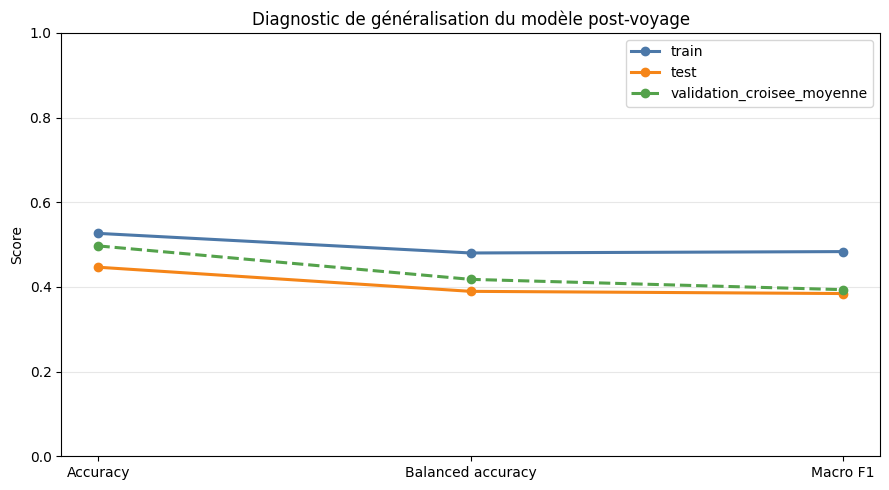

In [273]:
# Diagnostic consolidé du modèle post-voyage retenu.
# Ce bloc calcule en une seule fois : validation croisée, train/test, overfitting,
# underfitting, matrice de confusion et rapport de classification.

best_model_name = results_post.iloc[0]["modele"]
best_post_model_name = best_model_name
best_post_pipeline = fitted_post[best_model_name]

cv_results_post = cross_validate(
    best_post_pipeline,
    X_post,
    y_post,
    cv=3,
    scoring={
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
    },
    n_jobs=1,
)

cv_summary_post = pd.DataFrame({
    "metrique": ["accuracy", "balanced_accuracy", "macro_f1"],
    "moyenne": [
        cv_results_post["test_accuracy"].mean(),
        cv_results_post["test_balanced_accuracy"].mean(),
        cv_results_post["test_macro_f1"].mean(),
    ],
    "ecart_type": [
        cv_results_post["test_accuracy"].std(),
        cv_results_post["test_balanced_accuracy"].std(),
        cv_results_post["test_macro_f1"].std(),
    ],
})

train_predictions_diagnostic = best_post_pipeline.predict(X_train_post)
best_predictions = best_post_pipeline.predict(X_test_post)

diagnostic_generalisation_post = pd.DataFrame([
    {
        "jeu": "train",
        "accuracy": accuracy_score(y_train_post, train_predictions_diagnostic),
        "balanced_accuracy": balanced_accuracy_score(y_train_post, train_predictions_diagnostic),
        "macro_f1": f1_score(y_train_post, train_predictions_diagnostic, average="macro"),
    },
    {
        "jeu": "test",
        "accuracy": accuracy_score(y_test_post, best_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_post, best_predictions),
        "macro_f1": f1_score(y_test_post, best_predictions, average="macro"),
    },
    {
        "jeu": "validation_croisee_moyenne",
        "accuracy": cv_results_post["test_accuracy"].mean(),
        "balanced_accuracy": cv_results_post["test_balanced_accuracy"].mean(),
        "macro_f1": cv_results_post["test_macro_f1"].mean(),
    },
])

overfitting_diagnostic = diagnostic_generalisation_post.copy()

gap_train_test_macro_f1 = (
    diagnostic_generalisation_post.loc[diagnostic_generalisation_post["jeu"] == "train", "macro_f1"].iloc[0]
    - diagnostic_generalisation_post.loc[diagnostic_generalisation_post["jeu"] == "test", "macro_f1"].iloc[0]
)

baseline_rows = results_post.loc[
    results_post["modele"].str.contains("Dummy", case=False, na=False),
    "macro_f1",
]
baseline_macro_f1 = baseline_rows.iloc[0] if not baseline_rows.empty else np.nan

test_macro_f1 = diagnostic_generalisation_post.loc[
    diagnostic_generalisation_post["jeu"] == "test", "macro_f1"
].iloc[0]
gain_vs_baseline = test_macro_f1 - baseline_macro_f1 if not np.isnan(baseline_macro_f1) else np.nan

underfitting_diagnostic = pd.DataFrame([
    {
        "macro_f1_train": diagnostic_generalisation_post.loc[diagnostic_generalisation_post["jeu"] == "train", "macro_f1"].iloc[0],
        "macro_f1_test": test_macro_f1,
        "macro_f1_validation_croisee": diagnostic_generalisation_post.loc[diagnostic_generalisation_post["jeu"] == "validation_croisee_moyenne", "macro_f1"].iloc[0],
        "macro_f1_baseline_dummy": baseline_macro_f1,
        "ecart_train_test": abs(gap_train_test_macro_f1),
        "gain_vs_baseline": gain_vs_baseline,
    }
])

labels_3_classes = [0, 1, 2]
labels_readable = ["insatisfait_1_2", "neutre_3", "satisfait_4_5"]

confusion_post = pd.DataFrame(
    confusion_matrix(y_test_post, best_predictions, labels=labels_3_classes),
    index=[f"reel_{label}" for label in labels_readable],
    columns=[f"predit_{label}" for label in labels_readable],
)

report_post = pd.DataFrame(
    classification_report(
        y_test_post,
        best_predictions,
        labels=labels_3_classes,
        target_names=labels_readable,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print("Modèle retenu pour diagnostic :", best_model_name)
print("Validation croisée :")
display(cv_summary_post.round(4))
print("Diagnostic train / test / validation croisée :")
display(diagnostic_generalisation_post.round(4))
print("Synthèse underfitting / baseline :")
display(underfitting_diagnostic.round(4))
print(f"Écart macro_f1 train-test : {gap_train_test_macro_f1:.4f}")

if gap_train_test_macro_f1 > 0.15:
    print("Conclusion overfitting : risque élevé.")
elif gap_train_test_macro_f1 > 0.07:
    print("Conclusion overfitting : risque modéré à surveiller.")
else:
    print("Conclusion overfitting : pas de signe fort.")

if not np.isnan(gain_vs_baseline) and gain_vs_baseline < 0.05:
    print("Conclusion underfitting : modèle trop proche de la baseline.")
else:
    print("Conclusion underfitting : le modèle apprend un signal utile face à la baseline.")

metrics_diagnostic = ["accuracy", "balanced_accuracy", "macro_f1"]
labels_diagnostic = ["Accuracy", "Balanced accuracy", "Macro F1"]

fig, ax = plt.subplots(figsize=(9, 5))
for jeu, style, color in [
    ("train", "-", "#4c78a8"),
    ("test", "-", "#f58518"),
    ("validation_croisee_moyenne", "--", "#54a24b"),
]:
    valeurs = [
        diagnostic_generalisation_post.loc[diagnostic_generalisation_post["jeu"] == jeu, metric].iloc[0]
        for metric in metrics_diagnostic
    ]
    ax.plot(labels_diagnostic, valeurs, marker="o", linestyle=style, linewidth=2.2, color=color, label=jeu)

ax.set_ylim(0, 1)
ax.set_title("Diagnostic de généralisation du modèle post-voyage")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

#### Interprétation synthétique du diagnostic

Le diagnostic consolidé permet de lire en une seule fois la stabilité du modèle post-voyage exploratoire :

- la validation croisée contrôle que le score ne dépend pas uniquement d'un split favorable ;
- l'écart `macro_f1` train/test mesure le risque d'overfitting ;
- le gain face à `DummyClassifier` mesure si le modèle apprend un signal utile ;
- la matrice de confusion et le rapport de classification servent à analyser les erreurs.

Cette partie est conservée comme preuve d'analyse scientifique du post-voyage, mais elle ne change pas la décision d'industrialisation : le modèle à déployer reste le modèle pré-voyage.


### 4.16 Matrice de confusion du modèle post-voyage exploratoire

Cette matrice concerne le modèle post-voyage analysé, pas le modèle pré-voyage industrialisé.


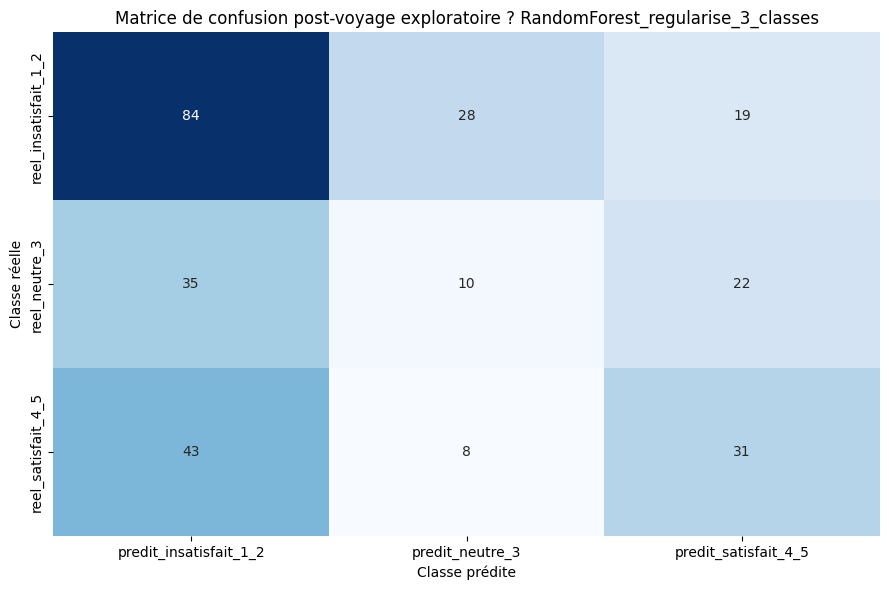

In [274]:
# Affichage graphique uniquement de la matrice de confusion post-voyage exploratoire.
# Le tableau brut `confusion_post` est calculé dans le diagnostic précédent,
# mais il n'est pas affiché ici pour éviter la redondance visuelle.
plt.figure(figsize=(9, 6))
sns.heatmap(
    confusion_post,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)
plt.title(f"Matrice de confusion post-voyage exploratoire - {best_model_name}")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.show()


### 4.17 Traçabilité MLflow du modèle pré-voyage 

Cette traçabilité concerne le modèle`LogisticRegression_pre`, utilisé pour prédire la satisfaction avant le départ.


In [275]:
# Traçabilité MLflow du modèle pré-voyage industrialisé.
# On logge le pipeline sklearn complet : prétraitements + modèle.
mlflow_pre_model_name = best_pre_model_name
mlflow_pre_pipeline = fitted_pre[mlflow_pre_model_name]
mlflow_pre_row = results_pre[results_pre["modele"] == mlflow_pre_model_name].iloc[0]

with mlflow.start_run(run_name=f"pre_voyage_{mlflow_pre_model_name}"):
    mlflow.log_param("solution", "TravelMind")
    mlflow.log_param("objectif", "pre-voyage")
    mlflow.log_param("usage", "modele industrialise")
    mlflow.log_param("target", "satisfaction_client_3_classes")
    mlflow.log_param("modele", mlflow_pre_model_name)
    mlflow.log_param("nb_features", len(feature_columns_pre))
    mlflow.log_param("features", ", ".join(feature_columns_pre))
    mlflow.log_param("train_rows", len(X_train_pre))
    mlflow.log_param("test_rows", len(X_test_pre))
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", RANDOM_STATE)

    mlflow.log_metric("accuracy", float(mlflow_pre_row["accuracy"]))
    mlflow.log_metric("balanced_accuracy", float(mlflow_pre_row["balanced_accuracy"]))
    mlflow.log_metric("macro_f1", float(mlflow_pre_row["macro_f1"]))

    mlflow.log_metric(
        "cv_accuracy_mean",
        float(cv_summary_pre.loc[cv_summary_pre["metrique"] == "accuracy", "moyenne"].iloc[0]),
    )
    mlflow.log_metric(
        "cv_balanced_accuracy_mean",
        float(cv_summary_pre.loc[cv_summary_pre["metrique"] == "balanced_accuracy", "moyenne"].iloc[0]),
    )
    mlflow.log_metric(
        "cv_macro_f1_mean",
        float(cv_summary_pre.loc[cv_summary_pre["metrique"] == "macro_f1", "moyenne"].iloc[0]),
    )

    if "gap_train_test_pre" in globals():
        mlflow.log_metric("gap_train_test_macro_f1", float(gap_train_test_pre))
    if "gain_vs_dummy_pre" in globals():
        mlflow.log_metric("gain_vs_dummy_macro_f1", float(gain_vs_dummy_pre))

    mlflow.log_dict(
        {
            "model_name": mlflow_pre_model_name,
            "objective": "pre_voyage_satisfaction_3_classes",
            "class_labels": libelles_satisfaction_3,
            "feature_columns": feature_columns_pre,
            "metrics_test": {
                "accuracy": float(mlflow_pre_row["accuracy"]),
                "balanced_accuracy": float(mlflow_pre_row["balanced_accuracy"]),
                "macro_f1": float(mlflow_pre_row["macro_f1"]),
            },
        },
        "pre_voyage_model_metadata.json",
    )

    mlflow.sklearn.log_model(mlflow_pre_pipeline, "model_pre_voyage")

print("Run MLflow pré-voyage enregistré")



2026/06/27 18:48:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/27 18:48:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow pré-voyage enregistré


## Partie 5 - Choix du modèle IA

Cette section formalise le choix du modèle IA retenu pour le projet TravelMind.

Le modèle retenu pour l'industrialisation est le modèle pré-voyage : `LogisticRegression_pre`. Le modèle post-voyage reste une analyse exploratoire utile pour comprendre l'apport des variables connues après le séjour, mais il n'est pas le modèle déployé.

#### Cas d'usage retenu

| Point | Choix retenu |
| --- | --- |
| Moment d'utilisation | Avant le départ |
| Objectif | Estimer un niveau de satisfaction probable à partir des informations disponibles lors de la planification |
| Modèle industrialisé | `LogisticRegression_pre` |
| Cible | `satisfaction_client` regroupée en 3 classes : `insatisfait_1_2`, `neutre_3`, `satisfait_4_5` |
| Variables exclues | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` |
| Usage attendu | Aide à la décision pour conseiller, pas décision automatique |

#### Démarche scientifique de sélection

La sélection du modèle repose sur une comparaison progressive :

1. tester la cible originale en 5 classes ;
2. regrouper la cible en 3 classes pour obtenir une sortie plus robuste et plus lisible ;
3. comparer une baseline `DummyClassifier`, une `LogisticRegression` et un `RandomForest` ;
4. utiliser `macro_f1` comme métrique principale, car les classes sont déséquilibrées ;
5. vérifier la stabilité par validation croisée ;
6. contrôler l'overfitting / underfitting ;
7. tester des optimisations non retenues si elles n'apportent pas de gain clair.

#### Résultat du choix

| Modèle | `accuracy` | `balanced_accuracy` | `macro_f1` | Décision |
| --- | ---: | ---: | ---: | --- |
| `LogisticRegression_pre` | `0.3536` | `0.3528` | `0.3462` | Retenu pour l'industrialisation |
| `RandomForest_pre` | `0.3857` | `0.3216` | `0.3103` | Non retenu : `macro_f1` plus faible |
| `Dummy_majority_pre` | `0.4679` | `0.3333` | `0.2125` | Baseline uniquement, accuracy trompeuse |

La `LogisticRegression_pre` est retenue car elle obtient le meilleur `macro_f1` et la meilleure `balanced_accuracy` parmi les modèles pré-voyage simples. Elle est aussi plus simple, plus rapide, plus explicable et plus facile à industrialiser.

#### Pourquoi pas le post-voyage ?

Le post-voyage donne de meilleurs signaux car il utilise des informations connues après ou pendant le séjour (`imprevus`, `respect_budget`, `reorganisation_necessaire`, NLP sur `retour_client`). Ces variables sont utiles pour l'analyse qualité et l'amélioration continue, mais elles ne sont pas disponibles avant le départ.

#### Type de résultat attendu

Le modèle produit :

- une classe prédite : `insatisfait_1_2`, `neutre_3` ou `satisfait_4_5` ;
- des probabilités par classe via `predict_proba` ;
- un niveau de confiance exploitable par le conseiller.

#### Contraintes opérationnelles prises en compte

| Contrainte | Prise en compte |
| --- | --- |
| Fuite de données | Exclusion stricte des variables post-voyage du modèle pré-voyage |
| Lisibilité métier | Sortie regroupée en 3 classes |
| Reproductibilité | `random_state=42`, pipeline `scikit-learn`, MLflow |
| Industrialisation | Pipeline exportable et servi via API `/predict` |
| Sobriété | Modèle linéaire tabulaire, pas de NLP dans le modèle déployé |

#### Éco-conception

Les preuves chiffrées d'éco-conception sont calculées dans la cellule suivante avec `preuves_eco_conception_pre`, puis interprétées juste après les résultats du code pour éviter de répéter les mêmes informations.


,metrique,valeur,interpretation
0,roc_auc_ovr_macro,0.5189,Moyenne non pondérée des AUC par classe
1,roc_auc_ovr_weighted,0.5233,Moyenne pondérée par le support des classes
2,roc_auc_insatisfait_1_2,0.5326,AUC one-vs-rest de la classe
3,roc_auc_neutre_3,0.4813,AUC one-vs-rest de la classe
4,roc_auc_satisfait_4_5,0.5429,AUC one-vs-rest de la classe


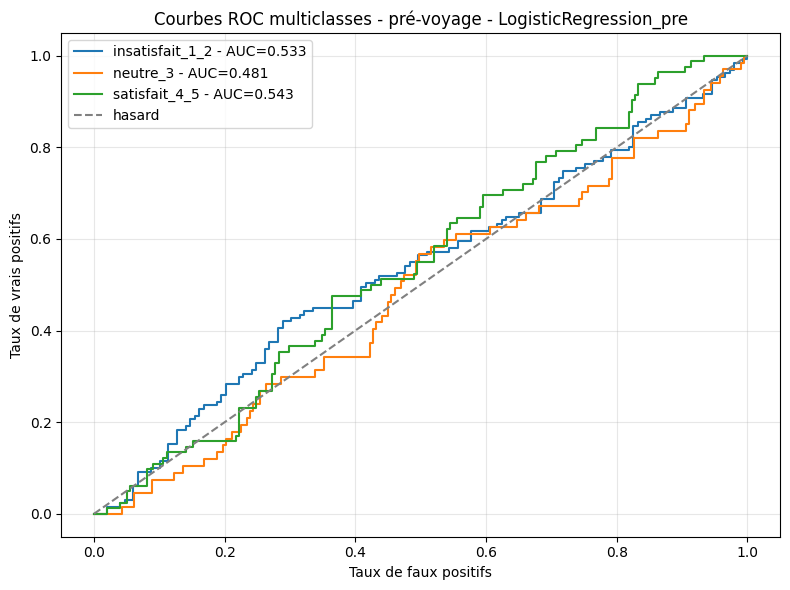

,indicateur,valeur,interpretation
0,nb_lignes_test,280.000000,Volume utilisé pour mesurer l'inférence
1,temps_inference_total_secondes,0.013316,Temps total de prédiction sur le jeu de test p...
2,temps_inference_moyen_ms_ligne,0.047556,Temps moyen de prédiction par ligne
3,cv_fit_time_moyen_secondes,0.054237,Temps moyen d'entraînement observé en validati...
4,cv_score_time_moyen_secondes,0.013553,Temps moyen d'évaluation observé en validation...


,preuve,valeur_chiffree,interpretation
0,Modele industrialise,LogisticRegression_pre,Modele lineaire simple retenu pour le deploiem...
1,Nombre de variables d'entree,15,"Volume de variables limite, sans texte libre n..."
2,Taille train / test,1119 / 280 lignes,Prototype tabulaire de taille limitee.
3,Temps moyen d'entrainement CV,0.0542 s,Temps moyen de fit par fold en validation croi...
4,Temps total d'inference test,0.0133 s,Prediction realisee sur 280 lignes de test.
5,Temps moyen d'inference par ligne,0.0476 ms,Inference compatible avec un usage API local l...
6,Gain du modele simple vs RandomForest,+0.0359 macro_f1,Le modele plus complexe ne justifie pas son co...
7,NLP en production,0 variable NLP,`retour_client` et les features NLP sont exclu...


In [276]:
# Analyse ROC multiclasses du modèle pré-voyage industrialisé.
# Le ROC complète accuracy / macro_f1 en évaluant la séparation probabiliste des classes.
best_pre_pipeline = fitted_pre[best_pre_model_name]
labels_pre_roc = sorted(y_pre.unique())
labels_pre_readable = [libelles_satisfaction_3[label] for label in labels_pre_roc]

if hasattr(best_pre_pipeline, "predict_proba"):
    y_score_pre = best_pre_pipeline.predict_proba(X_test_pre)
    y_test_pre_binarized = label_binarize(y_test_pre, classes=labels_pre_roc)

    roc_auc_macro_ovr_pre = roc_auc_score(
        y_test_pre,
        y_score_pre,
        multi_class="ovr",
        average="macro",
    )
    roc_auc_weighted_ovr_pre = roc_auc_score(
        y_test_pre,
        y_score_pre,
        multi_class="ovr",
        average="weighted",
    )

    roc_rows_pre = [
        {
            "metrique": "roc_auc_ovr_macro",
            "valeur": roc_auc_macro_ovr_pre,
            "interpretation": "Moyenne non pondérée des AUC par classe",
        },
        {
            "metrique": "roc_auc_ovr_weighted",
            "valeur": roc_auc_weighted_ovr_pre,
            "interpretation": "Moyenne pondérée par le support des classes",
        },
    ]

    for class_index, class_label in enumerate(labels_pre_roc):
        fpr, tpr, _ = roc_curve(y_test_pre_binarized[:, class_index], y_score_pre[:, class_index])
        roc_rows_pre.append({
            "metrique": f"roc_auc_{labels_pre_readable[class_index]}",
            "valeur": auc(fpr, tpr),
            "interpretation": "AUC one-vs-rest de la classe",
        })

    roc_auc_pre = pd.DataFrame(roc_rows_pre)
    display(roc_auc_pre.round(4))

    plt.figure(figsize=(8, 6))
    for class_index, class_label in enumerate(labels_pre_roc):
        fpr, tpr, _ = roc_curve(y_test_pre_binarized[:, class_index], y_score_pre[:, class_index])
        plt.plot(
            fpr,
            tpr,
            label=f"{labels_pre_readable[class_index]} - AUC={auc(fpr, tpr):.3f}",
        )

    plt.plot([0, 1], [0, 1], "--", color="gray", label="hasard")
    plt.title(f"Courbes ROC multiclasses - pré-voyage - {best_pre_model_name}")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Le modèle pré-voyage ne fournit pas predict_proba : ROC AUC non calculable.")

# Mesure simple du temps d'inférence sur le jeu de test pré-voyage.
start_time = time.perf_counter()
_ = best_pre_pipeline.predict(X_test_pre)
inference_time_seconds_pre = time.perf_counter() - start_time

performance_operationnelle_pre = pd.DataFrame([
    {
        "indicateur": "nb_lignes_test",
        "valeur": len(X_test_pre),
        "interpretation": "Volume utilisé pour mesurer l'inférence",
    },
    {
        "indicateur": "temps_inference_total_secondes",
        "valeur": inference_time_seconds_pre,
        "interpretation": "Temps total de prédiction sur le jeu de test pré-voyage",
    },
    {
        "indicateur": "temps_inference_moyen_ms_ligne",
        "valeur": inference_time_seconds_pre / len(X_test_pre) * 1000,
        "interpretation": "Temps moyen de prédiction par ligne",
    },
    {
        "indicateur": "cv_fit_time_moyen_secondes",
        "valeur": cv_results_pre["fit_time"].mean(),
        "interpretation": "Temps moyen d'entraînement observé en validation croisée",
    },
    {
        "indicateur": "cv_score_time_moyen_secondes",
        "valeur": cv_results_pre["score_time"].mean(),
        "interpretation": "Temps moyen d'évaluation observé en validation croisée",
    },
])

display(performance_operationnelle_pre.round(6))

# Synthèse chiffrée des preuves d'éco-conception pour le modèle industrialisé.
fit_time_mean_pre = float(cv_results_pre["fit_time"].mean())
score_time_mean_pre = float(cv_results_pre["score_time"].mean())
inference_ms_ligne_pre = inference_time_seconds_pre / len(X_test_pre) * 1000

macro_f1_logreg_pre = float(
    results_pre.loc[results_pre["modele"] == "LogisticRegression_pre", "macro_f1"].iloc[0]
)
macro_f1_rf_pre = float(
    results_pre.loc[results_pre["modele"] == "RandomForest_pre", "macro_f1"].iloc[0]
)
gain_logreg_vs_rf_pre = macro_f1_logreg_pre - macro_f1_rf_pre

preuves_eco_conception_pre = pd.DataFrame([
    {
        "preuve": "Modele industrialise",
        "valeur_chiffree": best_pre_model_name,
        "interpretation": "Modele lineaire simple retenu pour le deploiement pre-voyage.",
    },
    {
        "preuve": "Nombre de variables d'entree",
        "valeur_chiffree": len(feature_columns_pre),
        "interpretation": "Volume de variables limite, sans texte libre ni NLP dans le pipeline deploye.",
    },
    {
        "preuve": "Taille train / test",
        "valeur_chiffree": f"{len(X_train_pre)} / {len(X_test_pre)} lignes",
        "interpretation": "Prototype tabulaire de taille limitee.",
    },
    {
        "preuve": "Temps moyen d'entrainement CV",
        "valeur_chiffree": f"{fit_time_mean_pre:.4f} s",
        "interpretation": "Temps moyen de fit par fold en validation croisee.",
    },
    {
        "preuve": "Temps total d'inference test",
        "valeur_chiffree": f"{inference_time_seconds_pre:.4f} s",
        "interpretation": f"Prediction realisee sur {len(X_test_pre)} lignes de test.",
    },
    {
        "preuve": "Temps moyen d'inference par ligne",
        "valeur_chiffree": f"{inference_ms_ligne_pre:.4f} ms",
        "interpretation": "Inference compatible avec un usage API local leger.",
    },
    {
        "preuve": "Gain du modele simple vs RandomForest",
        "valeur_chiffree": f"+{gain_logreg_vs_rf_pre:.4f} macro_f1",
        "interpretation": "Le modele plus complexe ne justifie pas son cout car il performe moins bien en macro_f1.",
    },
    {
        "preuve": "NLP en production",
        "valeur_chiffree": "0 variable NLP",
        "interpretation": "`retour_client` et les features NLP sont exclus du modele pre-voyage deploye.",
    },
])

display(preuves_eco_conception_pre)


#### Lecture du tableau chiffré d'éco-conception

Le tableau `preuves_eco_conception_pre` affiché juste au-dessus fournit les preuves numériques associées à la sobriété du modèle pré-voyage industrialisé : temps moyen d'entraînement, temps d'inférence, nombre de variables, volume train/test, absence de NLP en production et comparaison avec `RandomForest_pre`.

Ces valeurs justifient le choix d'un modèle simple : `LogisticRegression_pre` est moins complexe, plus rapide à servir via API et plus pertinent que les modèles plus lourds au regard du `macro_f1`. Les chiffres doivent être recalculés si l'environnement d'exécution, les données ou le pipeline changent.


## Partie 6 - Entraînement supervisé du modèle IA

Cette section documente l'entraînement supervisé du modèle retenu pour l'industrialisation : le modèle pré-voyage `LogisticRegression_pre`.

#### Méthode d'entraînement retenue

| Élément | Choix dans le projet | Justification |
| --- | --- | --- |
| Type d'apprentissage | Apprentissage supervisé | La cible `satisfaction_client` est connue dans l'historique des séjours. |
| Problème IA | Classification multiclasses 3 classes | La satisfaction est regroupée en `insatisfait_1_2`, `neutre_3`, `satisfait_4_5`. |
| Données d'entrée | `X_pre` | Variables disponibles avant le départ uniquement. |
| Donnée cible | `y_pre` | `satisfaction_client` regroupée en 3 classes. |
| Split | Train/test stratifié 80/20 | Conserve la distribution des classes dans train et test. |
| Pipeline | `ColumnTransformer` + `Pipeline scikit-learn` | Imputation, IQR, encodage et standardisation sont appris uniquement sur le train. |
| Modèle retenu | `LogisticRegression_pre` | Meilleur compromis `macro_f1`, simplicité, explicabilité et industrialisation. |
| Validation | Test set + validation croisée | Vérifie la performance sur données non vues et la stabilité. |

#### Hyperparamètres du modèle industrialisé

| Hyperparamètre | Valeur | Rôle |
| --- | --- | --- |
| `max_iter` | `500` | Autoriser la convergence du modèle. |
| `class_weight` | `balanced` | Réduire l'effet du déséquilibre des classes. |
| `random_state` | `42` via le split | Assurer la reproductibilité du découpage train/test. |

#### Optimisations testées

| Optimisation testée | Objectif | Décision actuelle |
| --- | --- | --- |
| Cible 5 classes | Tester la prédiction fine des notes 1 à 5 | Non retenue : performance plus faible que le regroupement 3 classes. |
| `RandomForest_pre` | Tester des relations non linéaires | Non retenu : `macro_f1` inférieur à `LogisticRegression_pre`. |
| `RandomForest_pre_optimise` | Réduire l'overfitting par régularisation | Non retenu : pas de gain suffisant. |
| Optuna pré-voyage | Chercher automatiquement de meilleurs hyperparamètres | Non retenu : pas d'amélioration claire du `macro_f1`. |
| SMOTE pré-voyage | Rééquilibrer artificiellement les classes | Non retenu : gain trop faible ou instable. |
| NLP / `retour_client` | Exploiter le ressenti textuel | Exclu du modèle pré-voyage pour éviter la fuite de données. |

#### Réentraînement et transfert de connaissances

| Point | Application dans ce projet |
| --- | --- |
| Modèle entraîné | Oui : `LogisticRegression_pre` est entraîné avec `.fit()` sur `X_train_pre`, `y_train_pre`. |
| Modèles réentraînés en expérimentation | Oui : les modèles comparés sont réentraînés sur le même split train/test. |
| Réentraînement futur | Prévu via `train.py` lorsque de nouvelles données validées seront disponibles. |
| Transfert de connaissances | Non applicable au modèle tabulaire principal ; aucun poids n'est transféré entre modèles sklearn. |
| Modèle pré-entraîné NLP | Testé uniquement en analyse exploratoire post-voyage, non retenu pour le déploiement. |

#### Feature engineering mobilisé pour l'entraînement

Le modèle pré-voyage utilise uniquement des variables disponibles avant le départ :

- `budget_par_jour` : budget ramené à la durée du séjour ;
- `part_vol_budget` : poids du vol dans le budget total ;
- `sejour_long` : indicateur de séjour long ;
- `meteo_risque` : indicateur de météo potentiellement défavorable ;
- `client_business` : indicateur de profil business ;
- `hebergement_luxe` : indicateur d'hébergement haut de gamme.

#### Conclusion

Le modèle pré-voyage est entraîné automatiquement et superviséement dans un pipeline reproductible. Les optimisations testées ne remplacent pas `LogisticRegression_pre`, car elles n'apportent pas de gain suffisamment clair sur la métrique prioritaire `macro_f1`.


### 6.1 Hyperparamètres et résumé d’entraînement


In [ ]:
def extraire_hyperparametres_modele(model) -> dict:
    params = model.get_params()
    hyperparametres_utiles = [
        "strategy",
        "max_iter",
        "class_weight",
        "C",
        "penalty",
        "solver",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "random_state",
        "n_jobs",
    ]
    return {key: params.get(key) for key in hyperparametres_utiles if key in params}


resume_entrainement_pre = pd.DataFrame([
    {
        "element": "type_apprentissage",
        "valeur": "supervise",
    },
    {
        "element": "probleme",
        "valeur": "classification multiclasses 3 classes",
    },
    {
        "element": "taille_train",
        "valeur": len(X_train_pre),
    },
    {
        "element": "taille_test",
        "valeur": len(X_test_pre),
    },
    {
        "element": "nb_features_pre",
        "valeur": len(feature_columns_pre),
    },
    {
        "element": "modele_industrialise",
        "valeur": best_pre_model_name,
    },
])

display(resume_entrainement_pre)

hyperparametres_modeles_pre = pd.DataFrame([
    {
        "modele": model_name,
        "hyperparametres": extraire_hyperparametres_modele(model),
    }
    for model_name, model in modeles_pre.items()
])

display(hyperparametres_modeles_pre)

print("Comparaison des modeles pre-voyage principaux :")
display(results_pre.round(4))



## Partie 7 - Implémentation et intégration technique

Cette section est centrée sur l'industrialisation du modèle pré-voyage `LogisticRegression_pre`, qui est le modèle retenu pour servir TravelMind. Les expériences post-voyage restent documentées comme analyses exploratoires, mais elles ne sont pas déployées dans l'API.

#### Objectif de cette partie

Elle vise à transformer le travail réalisé dans le notebook en une première chaîne exploitable :

- entraînement reproductible hors notebook ;
- export du pipeline `sklearn` complet ;
- service de prédiction via API FastAPI ;
- interface web Streamlit pour tester des voyages manuellement ou par CSV ;
- journalisation des prédictions ;
- monitoring des prédictions, de la confiance et de la dérive ;
- validation automatique via CI/CD et quality gate.

#### Schéma visuel de l'architecture

![Architecture d'industrialisation](../docs/architecture_industrialisation.svg)

#### Flux fonctionnel industrialisé

```text
[Dataset CSV versionné]
        |
        v
[train.py]
        |
        +--> Nettoyage métier strict
        +--> Feature engineering pré-voyage
        +--> Pipeline sklearn : imputation + outliers + encodage + normalisation + modèle
        |
        v
[Artefacts locaux models/]
        |
        +--> model_pre_voyage.pkl
        +--> model_pre_voyage_metadata.json
        |
        v
[API FastAPI TravelMind]
        |
        +--> /health
        +--> /predict
        +--> /monitoring/summary
        +--> /monitoring/drift
        +--> /monitoring/alerts
        |
        +--> [Interface Streamlit]
        |
        v
[Logs JSONL]
        |
        v
[Suivi KPI + alertes + décision de réentraînement]
```

#### Fichiers techniques et rôles

| Fichier / dossier | Rôle | Contenu principal |
| --- | --- | --- |
| `train.py` | Entraînement reproductible | Charge le dataset, applique la préparation, entraîne les modèles candidats pré-voyage, sélectionne le meilleur et exporte les artefacts. |
| `app/modeling.py` | Logique ML centralisée | Nettoyage, feature engineering, pipeline `sklearn`, comparaison des modèles et profil de référence d'entraînement. |
| `app/schemas.py` | Contrat API | Schémas Pydantic d'entrée et de sortie pour `/predict`. |
| `app/predictor.py` | Service de prédiction | Charge `model_pre_voyage.pkl`, prépare les entrées et retourne classe, probabilités et confiance. |
| `app/main.py` | API TravelMind | Expose `/health`, `/predict`, `/monitoring/summary`, `/monitoring/drift` et `/monitoring/alerts`. |
| `app/monitoring.py` | Monitoring opérationnel | Journalise les prédictions, calcule les KPI d'usage, détecte la dérive et génère des alertes. |
| `app_web.py` | Interface web | Application Streamlit pour tester l'API, saisir un voyage, importer un CSV et consulter les KPI. |
| `scripts/check_model_quality.py` | Quality gate | Vérifie que les métriques du modèle exporté restent au-dessus des seuils attendus. |
| `configs/model_quality_gate.json` | Seuils qualité | Contient les seuils minimums, les métriques de référence et la baisse maximale autorisée. |
| `.github/workflows/ci-cd.yml` | CI/CD | Lance les tests, entraîne le modèle de CI, applique le quality gate, valide le notebook et construit l'image Docker. |
| `tests/` | Tests automatisés | Tests API, pipeline ML, monitoring et endpoints. |
| `Dockerfile` | Image API | Construit l'environnement d'exécution FastAPI. |
| `docker-compose.yml` | Conteneurisation locale | Expose l'API sur `localhost:8001` et monte `models/` et `logs/`. |
| `docs/strategie_reentrainement.md` | Gouvernance MLOps | Décrit les seuils de suivi, les alertes et les conditions de réentraînement. |

#### Artefacts générés localement

| Artefact | Généré par | Rôle | Versioning |
| --- | --- | --- | --- |
| `models/model_pre_voyage.pkl` | `python train.py` | Pipeline complet utilisé par l'API `/predict`. | Non versionné dans Git. |
| `models/model_pre_voyage_metadata.json` | `python train.py` | Métriques, classes, features et profil d'entraînement. | Non versionné dans Git. |
| `logs/predictions/predictions.jsonl` | Appels `/predict` | Historique des prédictions, entrées, probabilités et niveau de confiance. | Non versionné dans Git. |
| `mlruns/`, `mlartifacts/`, `mlflow.db` | MLflow local | Traçabilité locale des expériences. | Non versionné dans Git. |
| `logs/codecarbon/` | CodeCarbon | Estimation locale de l'empreinte carbone d'entraînement. | Non versionné dans Git. |

#### Modèle servi par l'API

| Élément | Valeur |
| --- | --- |
| Nom du projet | `TravelMind` |
| Objectif servi | Prédire avant le départ le risque de satisfaction client en 3 classes. |
| Modèle industrialisé | `LogisticRegression_pre` |
| Type de sortie | Probabiliste : classe prédite + probabilité par classe. |
| Classes | `insatisfait_1_2`, `neutre_3`, `satisfait_4_5` |
| Variables autorisées | Variables connues avant le séjour : profil client, budget, destination, saison, durée, hébergement, prix du vol, météo prévue, activité principale et features pré-voyage dérivées. |
| Variables exclues | `imprevus`, `reorganisation_necessaire`, `respect_budget`, `retour_client` et features post-voyage. |
| Justification | Ces variables sont connues pendant ou après le séjour ; les utiliser en pré-voyage créerait une fuite de données. |
| Usage recommandé | Aide à l'analyse pour le conseiller voyage, avec validation humaine. |
| Usage interdit | Refus automatique d'une offre, tarification individualisée injustifiée ou remplacement du conseiller. |

#### Interfaces locales

| Interface | URL locale | Usage |
| --- | --- | --- |
| API FastAPI | `http://localhost:8001` | Service de prédiction. |
| Health check | `http://localhost:8001/health` | Vérifier que l'API répond. |
| Documentation Swagger | `http://localhost:8001/docs` | Tester `/predict` et les endpoints de monitoring. |
| Interface web Streamlit | `http://localhost:8501` | Tester le modèle sans requête HTTP manuelle. |
| MLflow local | `http://127.0.0.1:5001` | Visualiser les runs si MLflow est lancé localement. |

#### Endpoints API

| Endpoint | Méthode | Rôle | Résultat attendu |
| --- | --- | --- | --- |
| `/health` | `GET` | Contrôle de disponibilité | `{"status": "ok"}` |
| `/predict` | `POST` | Prédiction pré-voyage | Classe, libellé, probabilités, confiance et métriques du modèle. |
| `/monitoring/summary` | `GET` | Synthèse des prédictions | Volume, distribution des classes, confiance moyenne et taux de faible confiance. |
| `/monitoring/drift` | `GET` | Détection de dérive | Écarts entre les entrées API et le profil d'entraînement. |
| `/monitoring/alerts` | `GET` | Décision opérationnelle | `collect_predictions`, `monitor_and_review`, `review_and_prepare_retraining` ou `no_action`. |

#### Commandes locales principales

| Action | Commande PowerShell | Objectif |
| --- | --- | --- |
| Installer les dépendances | `pip install -r requirements-dev.txt` | Préparer l'environnement local complet. |
| Entraîner et exporter | `python train.py` | Générer `models/model_pre_voyage.pkl` et les métadonnées. |
| Lancer l'API | `uvicorn app.main:app --reload --port 8001` | Servir le modèle en local. |
| Lancer l'interface web | `python -m streamlit run app_web.py` | Tester le modèle via navigateur. |
| Lancer les tests | `python -m pytest -q` | Vérifier API, pipeline et monitoring. |
| Lire les logs | `Get-Content -Encoding UTF8 logs/predictions/predictions.jsonl -Tail 5` | Voir les dernières prédictions. |
| Lancer Docker | `docker compose up --build` | Démarrer l'API conteneurisée. |
| Lancer MLflow | `mlflow ui --host 127.0.0.1 --port 5001` | Visualiser les runs locaux. |

#### Exemple de requête `/predict`

```json
{
  "client_type": "couple",
  "budget_total": 4200,
  "destination": "rome",
  "saison": "printemps",
  "duree_jours": 7,
  "type_hebergement": "hôtel",
  "prix_vol": 650,
  "meteo_prevue": "ensoleillé",
  "activite_principale": "culture"
}
```

#### Exemple de réponse `/predict`

```json
{
  "objective": "pre_voyage_satisfaction_3_classes",
  "model_name": "LogisticRegression_pre",
  "classe_predite": 2,
  "libelle_prediction": "satisfait_4_5",
  "probabilities": [
    {"classe": 0, "libelle": "insatisfait_1_2", "probabilite": 0.3815},
    {"classe": 1, "libelle": "neutre_3", "probabilite": 0.2138},
    {"classe": 2, "libelle": "satisfait_4_5", "probabilite": 0.4048}
  ],
  "model_metrics": {
    "accuracy": 0.3536,
    "balanced_accuracy": 0.3528,
    "macro_f1": 0.3462
  }
}
```

#### Quality gate CI/CD

Le quality gate vérifie que le modèle entraîné automatiquement reste compatible avec les exigences minimales du projet.

| Indicateur | Seuil minimum | Référence actuelle | Baisse maximale autorisée |
| --- | ---: | ---: | ---: |
| `accuracy` | `0.3000` | `0.3536` | `0.0600` |
| `balanced_accuracy` | `0.3000` | `0.3528` | `0.0600` |
| `macro_f1` | `0.3000` | `0.3462` | `0.0600` |
| `train_rows` | `1000` | Contrôlé dans les métadonnées | Non applicable |
| `test_rows` | `200` | Contrôlé dans les métadonnées | Non applicable |

#### CI/CD mise en place

| Étape | Rôle |
| --- | --- |
| Compilation Python | Détecter les erreurs de syntaxe dans `app/`, `tests/` et `train.py`. |
| Tests automatisés | Vérifier le comportement de l'API, du pipeline ML et du monitoring. |
| Entraînement CI | Reproduire l'entraînement pré-voyage dans l'environnement GitHub Actions. |
| Quality gate | Bloquer une version si les métriques chutent trop fortement. |
| Validation notebook | Parser les cellules code du notebook final pour détecter une erreur de syntaxe. |
| Build Docker | Vérifier que l'image API peut être construite. |

Cette CI/CD correspond à une livraison continue minimale : elle valide automatiquement le code, le modèle et le packaging. Elle ne réalise pas de déploiement continu automatique vers un serveur distant. Cette limite est acceptable pour le prototype TravelMind, car l'exploitation reste locale ; un déploiement serveur nécessiterait une cible d'hébergement validée, des secrets sécurisés, une stratégie de rollback et une validation DSI.

#### Monitoring en exploitation locale

Chaque appel à `/predict` ajoute une ligne JSON dans `logs/predictions/predictions.jsonl`.

| Indicateur suivi | Utilité |
| --- | --- |
| Volume de prédictions | Savoir si le monitoring repose sur assez d'observations. |
| Distribution des classes prédites | Détecter une concentration anormale sur une classe. |
| Confiance moyenne | Mesurer le degré d'incertitude du modèle. |
| Taux de faible confiance | Identifier les cas à revoir humainement. |
| Dérive numérique | Repérer des budgets, durées ou prix de vol différents du jeu d'entraînement. |
| Dérive catégorielle | Repérer de nouveaux profils, destinations ou usages surreprésentés. |

#### Conteneurisation Docker

| Élément | Rôle |
| --- | --- |
| `Dockerfile` | Construit l'image Python/FastAPI. |
| `docker-compose.yml` | Expose le service sur `localhost:8001`. |
| Volume `./models:/app/models:ro` | Fournit le modèle au conteneur en lecture seule. |
| Volume `./logs:/app/logs` | Conserve les logs hors du conteneur. |

```

#### Limites actuelles de l'industrialisation

- Le modèle pré-voyage reste peu performant.
- Le suivi de performance réelle nécessite de collecter ensuite la satisfaction observée après le voyage.
- Le réentraînement est documenté mais non automatique : il doit passer par une validation métier et technique.
- Les artefacts `models/`, `logs/`, `mlruns/` et `mlartifacts/` restent locaux et exclus de Git.
- La sécurisation production complète n'est pas incluse : authentification, gestion des droits, HTTPS, supervision serveur et sauvegardes restent à ajouter en cas de déploiement réel.


## Partie 8 - Évaluation de l'architecture cible

Cette section évalue l'architecture cible retenue pour TravelMind. L'objectif est de montrer que la solution technique est proportionnée au contexte : prototype local, modèle pré-voyage `LogisticRegression_pre`, supervision humaine, budget maîtrisé et besoin de démonstration métier.

#### Architecture cible retenue

![Architecture cible TravelMind](../docs/architecture_cible_travelmind.svg)

Le schéma résume l'architecture retenue : notebook documenté, entraînement reproductible, artefacts modèle, API FastAPI, interface Streamlit, logs JSONL, monitoring, CI/CD et Docker local. Cette architecture permet de servir le modèle hors notebook, de tester des voyages via une interface simple, de tracer les prédictions et de surveiller le comportement du modèle sans surdimensionner le projet.

#### Scénarios étudiés

| Scénario | Statut | Rôle dans le projet | Limite principale |
| --- | --- | --- | --- |
| Notebook final | Mis en œuvre | Documentation, exploration, comparaison des modèles | Non adapté à un usage métier autonome |
| `train.py` | Mis en œuvre | Entraînement reproductible et export des artefacts | Nécessite l'environnement Python du projet |
| API FastAPI locale | Mis en œuvre | Service de prédiction `/predict` | Usage local uniquement à ce stade |
| Interface Streamlit | Mis en œuvre | Test métier, saisie manuelle, import CSV, dashboard KPI | Interface de démonstration locale |
| Docker Compose | Mis en œuvre en local | Portabilité et exécution conteneurisée | Dépend de Docker et des volumes `models/` / `logs/` |
| CI/CD GitHub Actions | Mis en œuvre | Tests, quality gate, validation notebook, build Docker | Ne déploie pas automatiquement sur serveur |

#### Contraintes prises en compte

| Contrainte | Décision retenue |
| --- | --- |
| Performance modeste du modèle pré-voyage | Usage comme aide à l'analyse, avec supervision humaine. |
| Risque de fuite de données | Exclusion des variables post-voyage : `imprevus`, `respect_budget`, `reorganisation_necessaire`, `retour_client`. |
| Sobriété technique | Modèles `sklearn`, API locale, Docker optionnel, pas de NLP lourd dans le pipeline déployé. |
| Besoin de démonstration métier | Interface Streamlit et documentation Swagger. |
| Traçabilité | Logs JSONL, métadonnées modèle et MLflow local. |
| Portabilité | GitHub, `requirements-dev.txt`, `train.py` et Docker Compose. |
| Artefacts locaux non versionnés | Régénération par `python train.py` sur un autre poste. |

#### Contraintes économiques

L'architecture locale est retenue car elle couvre le besoin actuel avec un coût quasi nul : notebook, API, Streamlit, Docker local et CI/CD GitHub Actions.

#### Acteurs ressources à consulter

Avant une généralisation, ces acteurs devront être consultés formellement. À ce stade du prototype, leurs validations sont identifiées comme actions à réaliser avant production :

- Métier : confirmer l'usage du score, les champs du formulaire et la supervision humaine.
- Technique / DSI : valider l'hébergement, la sécurité, la disponibilité et la maintenance.
- Juriste / DPO : valider les obligations RGPD en cas de données clients réelles.
- Direction / qualité : valider les KPI, les seuils d'alerte et les conditions de réentraînement.

#### Conclusion

L'architecture retenue est cohérente avec le stade du projet : elle est suffisante pour démontrer, tester, tracer et surveiller le modèle pré-voyage sans engager une infrastructure coûteuse.


## Partie 9 - Mesure de performance et impacts de la solution IA

Cette section mesure la performance et les impacts de la solution IA TravelMind. Elle se concentre sur le modèle pré-voyage industrialisé `LogisticRegression_pre`, servi par l'API.

#### Indicateurs de performance retenus

| Indicateur | Rôle | Résultat / seuil actuel | Interprétation |
| --- | --- | --- | --- |
| `accuracy` | Part totale de prédictions correctes | Environ `0.35` sur le modèle pré-voyage | Score secondaire, car les classes sont déséquilibrées. |
| `balanced_accuracy` | Moyenne des rappels par classe | Environ `0.35` | Plus utile que l'accuracy pour vérifier que le modèle ne favorise pas uniquement la classe majoritaire. |
| `macro_f1` | Moyenne du F1-score sur les classes | Environ `0.35` | Métrique principale retenue, car elle pénalise les mauvaises performances sur les classes minoritaires. |
| Matrice de confusion | Analyse des erreurs par classe | Disponible dans la section modélisation | Montre quelles classes sont confondues par le modèle. |
| Validation croisée | Robustesse de la performance | Disponible dans la section modélisation | Vérifie que le score n'est pas lié uniquement à un split train/test favorable. |
| `roc_auc` multiclasses | Séparation probabiliste des classes | Calculée dans la section choix du modèle | Complète les métriques de classification en évaluant les probabilités. |

#### Seuils de validation technique

La CI/CD applique un quality gate pour éviter de livrer une version fortement dégradée du modèle.

| Indicateur | Seuil minimum CI/CD | Référence actuelle | Baisse maximale autorisée |
| --- | ---: | ---: | ---: |
| `accuracy` | `0.3000` | `0.3536` | `0.0600` |
| `balanced_accuracy` | `0.3000` | `0.3528` | `0.0600` |
| `macro_f1` | `0.3000` | `0.3462` | `0.0600` |

Ces seuils ne signifient pas que le modèle est excellent. Ils servent à empêcher une régression technique forte entre deux versions. Les valeurs devront être recalculées après synchronisation finale entre le notebook et le code industrialisé.

#### Indicateurs de suivi en exploitation locale

| Indicateur suivi | Source | Action associée |
| --- | --- | --- |
| Volume de prédictions | `logs/predictions/predictions.jsonl` et `/monitoring/summary` | Ne pas conclure si le volume est trop faible. |
| Distribution des classes prédites | `/monitoring/summary` | Détecter une concentration anormale sur une classe. |
| Confiance moyenne | `/monitoring/summary` | Suivre l'incertitude générale du modèle. |
| Taux de faible confiance | `/monitoring/summary` et `/monitoring/alerts` | Déclencher une revue humaine si le taux devient élevé. |
| Dérive numérique | `/monitoring/drift` | Vérifier si budgets, durées ou prix de vol changent par rapport au train. |
| Dérive catégorielle | `/monitoring/drift` | Identifier de nouveaux profils, destinations ou comportements d'usage. |

#### Impacts suivis

| Impact | Risque | Mesure retenue |
| --- | --- | --- |
| Métier | Surinterprétation d'une prédiction peu fiable | Affichage des probabilités, niveau de confiance et supervision humaine. |
| Éthique | Écart de performance selon certains profils ou segments | Mesures par sous-groupes et documentation dans la Model Card. |
| Données | Fuite de données entre pré-voyage et post-voyage | Exclusion stricte des variables post-voyage du modèle servi. |
| Environnement | Entraînements ou modèles trop lourds | Modèle tabulaire léger, CodeCarbon et absence de NLP dans l'API pré-voyage. |
| Exploitation | Dérive des données saisies dans l'API | Logs JSONL, endpoints monitoring et alertes. |

#### Actions déclenchées selon les résultats

| Signal observé | Action prévue |
| --- | --- |
| `macro_f1`, `accuracy` ou `balanced_accuracy` sous le seuil CI/CD | Bloquer la livraison et analyser la régression. |
| Taux élevé de faible confiance | Renforcer la revue humaine des prédictions concernées. |
| Dérive critique confirmée | Préparer un réentraînement après validation métier et technique. |
| Écart important sur un sous-groupe | Analyser la représentativité et les erreurs du segment. |
| Empreinte carbone excessive | Réduire les expérimentations lourdes et privilégier les modèles sobres. |

#### Limite de mesure

Le monitoring actuel mesure les prédictions, la confiance et la dérive des entrées API. Il ne mesure pas encore la performance réelle en production, car celle-ci nécessite de collecter ensuite la satisfaction observée après le séjour. La performance réelle devra donc être réévaluée lorsque de nouvelles données annotées seront disponibles.



### 9.1 Model Card - fiche du modèle retenu

Cette fiche documente le modèle retenu pour l'industrialisation : le modèle pré-voyage `LogisticRegression_pre`. Elle doit être mise à jour à chaque changement de données, de variables, d'algorithme, d'hyperparamètres ou de seuils de monitoring.

#### Détails du modèle

| Élément | Description |
| --- | --- |
| Objectif | Prédire avant le départ le niveau de satisfaction client en 3 classes. |
| Modèle retenu | `LogisticRegression_pre` |
| Cible | `satisfaction_client` regroupée en `0 = insatisfait_1_2`, `1 = neutre_3`, `2 = satisfait_4_5`. |
| Contexte d'usage | Aide à l'analyse pour une agence de voyages. |
| Type de sortie | Probabiliste : classe prédite, probabilités par classe et niveau de confiance. |
| Sélection du modèle | Meilleur compromis pré-voyage selon `macro_f1`, `balanced_accuracy`, simplicité, explicabilité et facilité d'industrialisation. |
| Split d'évaluation | Train/test stratifié, `80 %` entraînement et `20 %` test. |
| Validation complémentaire | Validation croisée, matrice de confusion, diagnostic overfitting / underfitting, ROC multiclasses si `predict_proba` disponible. |


#### Usage, limites et risques du modèle

Le modèle `LogisticRegression_pre` est recommandé comme outil d'aide à l'analyse avant départ. Il peut aider le conseiller à repérer des voyages potentiellement à risque et à comparer des scénarios, mais la décision finale doit rester humaine.

Les usages interdits sont : refus automatique d'une offre, tarification individualisée injustifiée, remplacement du conseiller ou décision commerciale sans revue humaine.

Les principales limites sont : performance pré-voyage modeste (`macro_f1` autour de 0.35), classe `neutre_3` difficile à prédire, dataset synthétique et faible signal disponible avant séjour.

Les principaux risques sont : surinterprétation du score, biais indirects liés à `budget_total`, `destination`, `client_type` ou `type_hebergement`, et dérive si les voyages saisis dans l'API diffèrent du dataset d'entraînement.


### 9.2 Mesure CodeCarbon du modèle pré-voyage industrialisé

Cette cellule mesure l'empreinte carbone estimée d'un réentraînement du pipeline pré-voyage industrialisé (`LogisticRegression_pre`). Elle crée un rapport `codecarbon_report` et sauvegarde aussi un fichier CSV dans `logs/codecarbon/`.

La mesure est volontairement séparée de l'entraînement principal : elle sert à documenter le coût environnemental du modèle déployé sans modifier le jeu de test ni la logique d'évaluation.


In [ ]:
# Mesure optionnelle de l empreinte carbone du modele pre-voyage avec CodeCarbon.
# Si CodeCarbon n est pas installe, installer la dependance : pip install codecarbon

codecarbon_available = OfflineEmissionsTracker is not None

if not codecarbon_available:
    codecarbon_report = pd.DataFrame([
        {
            "statut": "CodeCarbon non installe",
            "action": "Installer codecarbon puis relancer cette cellule",
            "commande": "pip install codecarbon",
        }
    ])
    display(codecarbon_report)
else:
    codecarbon_output_dir = PROJECT_ROOT / "logs" / "codecarbon"
    codecarbon_output_dir.mkdir(parents=True, exist_ok=True)

    codecarbon_output_file = "emissions_notebook_final.csv"
    country_iso_code = "FRA"  # A adapter si l entrainement est execute hors France.

    pipeline_codecarbon = clone(best_pre_pipeline)

    tracker = OfflineEmissionsTracker(
        project_name="travelmind_satisfaction",
        country_iso_code=country_iso_code,
        output_dir=str(codecarbon_output_dir),
        output_file=codecarbon_output_file,
        log_level="error",
    )

    start_time = time.perf_counter()
    tracker.start()
    pipeline_codecarbon.fit(X_train_pre, y_train_pre)
    emissions_kg_co2e = tracker.stop()
    training_duration_seconds = time.perf_counter() - start_time

    emissions_file = codecarbon_output_dir / codecarbon_output_file
    emissions_details = pd.read_csv(emissions_file).tail(1) if emissions_file.exists() else pd.DataFrame()

    codecarbon_report = pd.DataFrame([
        {
            "modele": best_pre_model_name,
            "pays_facteur_carbone": country_iso_code,
            "duree_entrainement_secondes": training_duration_seconds,
            "emissions_kg_co2e": emissions_kg_co2e,
            "emissions_g_co2e": emissions_kg_co2e * 1000 if emissions_kg_co2e is not None else np.nan,
            "fichier_codecarbon": str(emissions_file),
        }
    ])

    display(codecarbon_report.round(8))

    colonnes_details = [
        colonne
        for colonne in ["timestamp", "duration", "emissions", "emissions_rate", "cpu_power", "ram_power", "energy_consumed"]
        if colonne in emissions_details.columns
    ]
    if colonnes_details:
        display(emissions_details[colonnes_details])


,modele,pays_facteur_carbone,duree_entrainement_secondes,emissions_kg_co2e,emissions_g_co2e,fichier_codecarbon
0,LogisticRegression_pre,FRA,1.667877,1.900000e-07,0.00019,c:\Users\khadi\Downloads\Examen_IA\logs\codeca...


,timestamp,duration,emissions,emissions_rate,cpu_power,ram_power,energy_consumed
5,2026-06-27T18:49:02,1.563779,1.900246e-07,1.215163e-07,1.537843,10.0,0.000003


#### Interprétation chiffrée de la mesure CodeCarbon

Le réentraînement mesuré du modèle `LogisticRegression_pre` dure environ `1.67` seconde et émet environ `0.00000019 kgCO2e`, soit `0.00019 gCO2e`. Cette valeur est extrêmement faible : elle confirme que le pipeline pré-voyage industrialisé est sobre, car il s'agit d'un modèle tabulaire `scikit-learn`, entraîné localement sur un faible volume de données.


#### Performances par sous-groupes

La cellule suivante calcule les performances du modèle pré-voyage par sous-groupes métier. Les résultats doivent être interprétés avec prudence lorsque le `support` est faible.


In [ ]:
def evaluer_performance_sous_groupes(X_test, y_true, y_pred, colonnes_sous_groupes, min_support=20):
    donnees_eval = X_test.reset_index(drop=True).copy()
    y_true_eval = pd.Series(y_true).reset_index(drop=True)
    y_pred_eval = pd.Series(y_pred).reset_index(drop=True)
    labels_eval = sorted(y_true_eval.dropna().unique().tolist())

    lignes = []
    for colonne in colonnes_sous_groupes:
        if colonne not in donnees_eval.columns:
            continue

        serie_sous_groupe = donnees_eval[colonne].fillna("valeur_manquante")
        serie_sous_groupe = serie_sous_groupe.map(
            lambda valeur: tuple(valeur) if isinstance(valeur, list) else valeur
        )
        for valeur, index_groupe in serie_sous_groupe.groupby(serie_sous_groupe).groups.items():
            index_groupe = list(index_groupe)
            support = len(index_groupe)
            if support < min_support:
                continue

            y_true_groupe = y_true_eval.loc[index_groupe]
            y_pred_groupe = y_pred_eval.loc[index_groupe]

            lignes.append({
                "sous_groupe": colonne,
                "valeur": valeur,
                "support": support,
                "accuracy": accuracy_score(y_true_groupe, y_pred_groupe),
                "balanced_accuracy": balanced_accuracy_score(y_true_groupe, y_pred_groupe),
                "macro_f1": f1_score(
                    y_true_groupe,
                    y_pred_groupe,
                    labels=labels_eval,
                    average="macro",
                    zero_division=0,
                ),
            })

    return (
        pd.DataFrame(lignes)
        .sort_values(["sous_groupe", "macro_f1"], ascending=[True, False])
        .reset_index(drop=True)
    )


# Sous-groupes disponibles avant le départ : cohérents avec le modèle industrialisé.
colonnes_sous_groupes_model_card = [
    "client_type",
    "destination",
    "type_hebergement",
    "saison",
    "meteo_prevue",
    "activite_principale",
]

performances_sous_groupes_pre = evaluer_performance_sous_groupes(
    X_test_pre,
    y_test_pre,
    y_pred_pre,
    colonnes_sous_groupes_model_card,
    min_support=20,
)

display(performances_sous_groupes_pre.round(4))


,sous_groupe,valeur,support,accuracy,balanced_accuracy,macro_f1
0,activite_principale,culture,77,0.4286,0.4279,0.4244
1,activite_principale,plage,77,0.3636,0.3422,0.3333
2,activite_principale,business,52,0.2885,0.2667,0.2568
3,activite_principale,gastronomie,38,0.2632,0.4115,0.2519
4,activite_principale,randonnée,26,0.3077,0.2421,0.2379
5,client_type,couple,55,0.4727,0.4667,0.4607
6,client_type,business,65,0.4154,0.4054,0.4026
7,client_type,famille,43,0.3953,0.3690,0.3419
8,client_type,senior,47,0.2766,0.2917,0.2720
9,client_type,solo,70,0.2286,0.2738,0.2228


#### Interprétation des performances par sous-groupes

Le modèle pré-voyage présente une performance variable selon les segments métier. Son `macro_f1` global est d'environ `0.3462` : certains segments sont mieux prédits, comme `client_type = couple` (`0.4607`), `activite_principale = culture` (`0.4244`), `meteo_prevue = nuageux` (`0.4336`) ou `saison = automne` (`0.4128`). D'autres sont moins fiables, notamment `client_type = solo` (`0.2228`), `destination = dubaï` (`0.2175`), `saison = été` (`0.2263`) et `activite_principale = randonnée` (`0.2379`).

Ces écarts ne prouvent pas un biais à eux seuls, mais montrent une fiabilité hétérogène.


## Partie 10 - Amélioration continue de la solution IA

Cette section décrit comment TravelMind sera suivi et amélioré dans le temps. L'objectif est de maintenir le modèle pré-voyage aligné avec les besoins métier, les données disponibles et les usages observés.

#### Cadre de suivi

L'amélioration continue repose sur Git/GitHub, `train.py`, les tests automatisés, la CI/CD, le quality gate, les endpoints de monitoring et la stratégie de réentraînement documentée dans `docs/strategie_reentrainement.md`.

#### Indicateurs suivis

Les indicateurs suivis sont `accuracy`, `balanced_accuracy`, `macro_f1`, la baisse par rapport aux métriques de référence, l'âge des métadonnées, le volume de prédictions, le taux de faible confiance et les dérives numériques/catégorielles.

#### Revue et actions

- À chaque push : tests, entraînement CI et quality gate.
- En phase pilote : revue hebdomadaire des logs, alertes et prédictions peu confiantes.
- Chaque mois : revue des KPI, seuils et distributions de prédictions.
- Après alerte critique ou nouvelles données annotées : analyse métier/technique, puis réentraînement contrôlé si nécessaire.

Les actions possibles sont : continuer la surveillance, bloquer une livraison, renforcer la revue humaine, préparer un réentraînement ou revoir les features, la cible et les KPI.

#### Limites

Le réentraînement n'est pas automatique, le déploiement distant n'est pas activé et la performance réelle nécessitera des retours clients annotés après séjour. Une synchronisation finale entre le notebook et le code industrialisé reste nécessaire avant de figer la chaîne.





## Partie 11 - Synthèse finale

| Axe | Conclusion |
| --- | --- |
| Pré-voyage | Modèle industrialisé retenu : `LogisticRegression_pre`, avec `accuracy = 0.3536`, `balanced_accuracy = 0.3528` et `macro_f1 = 0.3462`. La performance reste modeste, ce qui est cohérent avec le faible signal disponible avant départ. |
| Post-voyage | Les expériences post-voyage obtiennent de meilleurs scores car elles utilisent des variables connues pendant ou après le séjour. Elles sont conservées comme analyse qualité, pas comme modèle déployé. |
| Nettoyage strict | Les incohérences `prix_vol > budget_total`, cible invalide et contradictions `imprevus` / `reorganisation_necessaire` sont supprimées avant les modélisations. |
| Pipeline sans fuite | Imputation, traitement IQR des outliers, standardisation, encodage et rééquilibrage éventuel sont réalisés après split dans les pipelines. |
| NLP `retour_client` | Utile pour l'analyse qualitative post-voyage, mais non retenu dans le modèle pré-voyage car trop proche de la satisfaction finale. |
| Segmentation client | Utile pour comprendre les profils de voyages et préparer une personnalisation future, mais non industrialisée dans cette version. |

Le modèle à synchroniser avec l'industrialisation est donc le modèle pré-voyage `LogisticRegression_pre`. Il correspond au moment d'utilisation avant départ et doit être lu comme un outil d'aide à l'analyse, avec supervision humaine, et non comme un système de décision automatique.


## Partie 12 - Bonnes pratiques adoptées dans le projet

Cette section synthétise les principales bonnes pratiques appliquées sur TravelMind.

- **Cadrage clair** : distinction entre objectif pré-voyage industrialisé et analyses post-voyage exploratoires, avec KPI et limites documentés.
- **Qualité des données** : datasheet, contrôles de cohérence métier, gestion des valeurs manquantes, outliers, doublons, valeurs négatives et versionning des données.
- **Modélisation rigoureuse** : split train/test avant preprocessing, pipelines `scikit-learn`, comparaison à une baseline, validation croisée, matrice de confusion, diagnostics overfitting / underfitting et documentation des essais non retenus.
- **Éthique et conformité** : exclusion des variables post-voyage du modèle pré-voyage, supervision humaine, Model Card, registre RGPD, AI Act, analyse des biais et mesures par sous-groupes.
- **Industrialisation progressive** : `train.py`, artefacts modèle, API FastAPI, interface Streamlit, Docker, Git/GitHub, tests automatisés et CI/CD avec quality gate.
- **Suivi et amélioration continue** : logs JSONL, monitoring de la confiance et des dérives, seuils de suivi, stratégie de réentraînement contrôlée et mesure CodeCarbon.

Ces pratiques montrent que le projet couvre l'ensemble de la chaîne IA : cadrage, données, modélisation, évaluation, éthique, industrialisation, monitoring et amélioration continue. La principale limite reste le caractère synthétique du dataset et l'absence de retours clients réels annotés en production.


## Partie 13 - Synthèse des ambitions métier

| Ambition métier | Niveau de couverture | Résultat dans le projet |
| --- | --- | --- |
| Recommandations de destinations adaptées au profil voyageur | Partiel | Les variables pré-voyage et la segmentation client permettent de comprendre les profils, mais aucun moteur de recommandation automatique de destination n'est industrialisé. |
| Planification logistique complète | Limité | Le dataset exploite le budget, la durée, le vol, l'hébergement et la météo, mais le projet ne génère pas encore un planning complet vols, hôtels et transports locaux. |
| Anticipation automatique des imprévus | Indirect | Le modèle pré-voyage anticipe un risque de satisfaction ou d'insatisfaction, mais ne prédit pas directement les imprévus comme annulation, retard ou météo. |
| Amélioration continue via retours clients | Exploratoire | Le NLP sur `retour_client` montre l'intérêt des avis clients, mais cette brique n'est pas industrialisée dans la version retenue. |

Le projet constitue donc une première brique IA centrée sur l'anticipation pré-voyage de la satisfaction client.
